# Paper 2 — Goal 2 primary core analysis
## Does recording quality change inference from frozen Bamboo acoustic features?

This notebook starts **only after `A FREEZE: PASS`**.

### Frozen scientific question

When clinical inference is based on the frozen clinical acoustic representation \(A\), does model behavior change when:

1. recording quality \(Q\) is made explicit;
2. the linearly Q-predictable component of \(A\) is removed; or
3. natural Q varies between and within participants?

The three paired primary ridge representations are:

\[
M_A = \mathrm{Age}+A
\]

\[
M_{A+Q} = \mathrm{Age}+A+Q
\]

\[
M_{A-resQ} = \mathrm{Age}+A_{resQ}
\]

where

\[
A_{resQ}=A-\hat g(Q)
\]

and \(\hat g\) is a linear ridge map learned from training participants only.

### Interpretation boundary

Goal 2 is observational. A difference after adding Q, residualizing A against Q, or modeling error versus Q demonstrates **dependence/sensitivity under the observed recording distribution**. It does not prove technical bias, shortcut learning, or that residualized speech is artifact-free.

### Primary inputs

- all age-eligible retained diagnosis recordings, repeated recordings kept;
- all eligible ALS recording–bulbar pairs within 60 days;
- frozen Primary-A and support indicators;
- exact Goal 1 Core-Q;
- same 5-fold × 10-repeat participant split manifest;
- participant total training weight = 1.

### Primary outputs

- recording/pair-level OOF predictions for all three representations;
- participant-level diagnosis probabilities;
- AUROC, Brier, native calibration;
- participant-weighted severity MAE/RMSE;
- 2,000 paired participant bootstraps in FINAL mode;
- individual prediction shifts;
- between-/within-participant Q dependence of OOF loss using cluster-robust identity-link GEE;
- Figure 3 and Figure 4 source tables + publication graphics.

### Run modes

`DEVELOPMENT` executes the identical modeling pathway with 300 bootstrap replicates.

`FINAL` uses 2,000 participant-cluster bootstrap replicates.

Use **Kernel → Restart Kernel and Run All Cells**.


### Scope of this notebook

This notebook seals the **primary ridge core** of Goal 2. The prespecified
nonlinear HGB, Q-family ablations, Extended-Q/A, first-recording, 90-day,
and other sensitivity analyses are intentionally run only after this core
development pipeline passes. They must not change the frozen Primary-A
representation or the primary model definitions.


In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as mdlib
import itertools
import json
import math
import os
import platform
import shutil
import subprocess
import sys
import warnings
from collections import OrderedDict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy import stats
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.genmod.cov_struct import Independence, Exchangeable
from statsmodels.genmod.families import Gaussian
from statsmodels.nonparametric.smoothers_lowess import lowess

# ------------------------------------------------------------------
# USER-FACING CONFIG
# ------------------------------------------------------------------

RUN_MODE = "FINAL"    # change to FINAL only after development PASS
RESET_OUTPUTS = False
RESUME_IF_VALID = True

BASE_SEED = 20260825
OUTER_FOLDS = 5
OUTER_REPEATS = 10
INNER_FOLDS = 5

if RUN_MODE not in {"DEVELOPMENT", "FINAL"}:
    raise ValueError("RUN_MODE must be DEVELOPMENT or FINAL.")

N_BOOTSTRAPS = 2000 if RUN_MODE == "FINAL" else 300

# Linear Q->A residualizer. This penalty is prespecified and does not use
# outcome performance. Q and A are standardized inside the training fold.
RESIDUALIZER_ALPHA = 1.0

C_GRID = np.logspace(-4, 4, 9)
ALPHA_GRID = np.logspace(-4, 4, 9)

EXPECTED_PAPER1_COMMIT = (
    "cb31fb6886df1b2b2fedba4ffbbf8624bd56d7e8"
)

ENGINE_VERSION = "goal2-primary-v1.1.0"

EXPECTED = {
    "recordings": 519,
    "participants": 224,
    "als_participants": 158,
    "control_participants": 66,
    "als_recordings": 418,
    "control_recordings": 101,
    "diagnosis_age_complete_participants": 199,
    "diagnosis_age_complete_als": 158,
    "diagnosis_age_complete_controls": 41,
    "severity_participants_60d": 145,
    "severity_pairs_60d": 398,
}

def find_project_root() -> Path:
    override = os.environ.get("PAPER2_ROOT", "").strip()
    if override:
        root = Path(override).expanduser().resolve()
        if (root / "data" / "processed").exists():
            return root
        raise FileNotFoundError(f"Invalid PAPER2_ROOT: {root}")

    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (
            (candidate / "data" / "processed").exists()
            and (candidate / "data" / "manifests").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate Paper 2 repository root."
    )

ROOT = find_project_root()
PROCESSED = ROOT / "data" / "processed"
MANIFESTS = ROOT / "data" / "manifests"
EXTERNAL = ROOT / "external" / "quality_framework_features"

RUN_TAG = RUN_MODE.lower()
OUT = (
    ROOT
    / "outputs"
    / "goal2"
    / "goal2_primary_v1_1"
    / RUN_TAG
)

TABLES = OUT / "tables"
FIGURES = OUT / "figures"
OOF_DIR = OUT / "oof"
CHECKPOINTS = OUT / "checkpoints"
LOGS = OUT / "logs"

if RESET_OUTPUTS and OUT.exists():
    shutil.rmtree(OUT)

for directory in [
    OUT, TABLES, FIGURES, OOF_DIR, CHECKPOINTS, LOGS
]:
    directory.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

print("Paper 2 root:", ROOT)
print("Engine:", ENGINE_VERSION)
print("Run mode:", RUN_MODE)
print("Bootstrap replicates:", N_BOOTSTRAPS)


Paper 2 root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Engine: goal2-primary-v1.1.0
Run mode: FINAL
Bootstrap replicates: 2000


## 1. Atomic I/O and reproducibility utilities

In [2]:
def sha256_file(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(chunk_size), b""):
            h.update(block)
    return h.hexdigest()

def stable_hash(payload):
    text = json.dumps(
        payload,
        sort_keys=True,
        default=str,
        separators=(",", ":"),
    )
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def atomic_write_json(payload, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(
        json.dumps(payload, indent=2, default=str),
        encoding="utf-8",
    )
    os.replace(temp, path)

def atomic_write_csv(
    frame,
    path,
    *,
    required_columns=None,
    allow_empty=False,
):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if not isinstance(frame, pd.DataFrame):
        raise TypeError(f"{path.name}: expected DataFrame.")

    if not allow_empty and len(frame) == 0:
        raise ValueError(
            f"{path.name}: refusing to write empty table."
        )

    if required_columns:
        missing = set(required_columns) - set(frame.columns)
        if missing:
            raise ValueError(
                f"{path.name}: missing columns {sorted(missing)}"
            )

    temp = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temp, index=False)

    if not temp.exists() or temp.stat().st_size == 0:
        raise IOError(
            f"{path.name}: temporary CSV is empty."
        )

    os.replace(temp, path)

def safe_read_csv(
    path,
    *,
    required_columns=None,
    allow_empty=False,
):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    if path.stat().st_size == 0:
        raise IOError(f"{path} exists but is empty.")

    frame = pd.read_csv(path, low_memory=False)

    if not allow_empty and len(frame) == 0:
        raise ValueError(f"{path} has no rows.")

    if required_columns:
        missing = set(required_columns) - set(frame.columns)
        if missing:
            raise ValueError(
                f"{path.name}: missing columns {sorted(missing)}"
            )

    return frame

def package_version(package):
    try:
        return mdlib.version(package)
    except Exception:
        return "unknown"

def deterministic_seed(*tokens, modulus=1_000_000):
    """
    Stable across Python processes and machines.
    Never use Python's built-in hash() for reproducibility.
    """
    digest = stable_hash(list(tokens))
    return BASE_SEED + (int(digest[:16], 16) % modulus)

def coerce_bool_series(series, name):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
    )

    mapping = {
        "true": True,
        "1": True,
        "yes": True,
        "y": True,
        "false": False,
        "0": False,
        "no": False,
        "n": False,
    }

    unknown = sorted(
        set(normalized.dropna()) - set(mapping)
    )
    if unknown:
        raise ValueError(
            f"{name}: unrecognized boolean values: {unknown[:20]}"
        )

    return normalized.map(mapping).astype(bool)

print("Atomic I/O / deterministic utilities: READY")


Atomic I/O / deterministic utilities: READY


## 2. Hard A/Q/cohort/split gates

The notebook will not fit a model unless:

- the A freeze manifest says `FROZEN`;
- the A values/registry hashes match;
- the canonical 519/224/158/66 denominators still hold;
- the Goal 1 split manifest is intact;
- the Phase 0.5 QCHAN cache still reproduces the frozen Paper 1 QCHAN release.


In [3]:
PATHS = {
    "recording_table": PROCESSED / "recording_table_phase0.csv",
    "participant_table": PROCESSED / "participant_table.csv",
    "severity_pairs": PROCESSED / "severity_pairs.csv",
    "a_values": PROCESSED / "acoustic_features_frozen.csv",
    "a_registry": MANIFESTS / "a_registry.csv",
    "a_manifest": MANIFESTS / "a_freeze_manifest.json",
    "q_registry": MANIFESTS / "q_registry.csv",
    "split_manifest": MANIFESTS / "split_manifest.csv",
    "qchan_ready": MANIFESTS / "qchan_cache_ready.json",
    "qchan_cache_index": MANIFESTS / "qchan_spectrum_cache_index.csv",
}

missing = [
    name for name, path in PATHS.items()
    if not path.exists()
]
if missing:
    raise FileNotFoundError(
        "Missing Goal 2 prerequisite(s): "
        + ", ".join(missing)
    )

recording_table = safe_read_csv(
    PATHS["recording_table"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
        "diagnosis",
        "age_at_recording_years",
    ],
)

participant_table = safe_read_csv(
    PATHS["participant_table"],
    required_columns=[
        "participant_id",
        "diagnosis",
    ],
)

severity_pairs_raw = safe_read_csv(
    PATHS["severity_pairs"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
        "bulbar_score",
        "abs_delta_days",
        "within_60_days",
    ],
)

a_values = safe_read_csv(
    PATHS["a_values"],
    required_columns=[
        "participant_id",
        "logical_recording_id",
    ],
)

a_registry = safe_read_csv(
    PATHS["a_registry"],
    required_columns=[
        "feature",
        "final_role",
        "final_transform",
        "support_indicator_column",
        "a_freeze_version",
    ],
)

q_registry = safe_read_csv(
    PATHS["q_registry"],
    required_columns=[
        "feature",
        "family",
        "paper2_role",
        "transform",
    ],
)

split_manifest = safe_read_csv(
    PATHS["split_manifest"],
    required_columns=[
        "participant_id",
        "repeat",
        "outer_fold",
    ],
)

qchan_cache_index = safe_read_csv(
    PATHS["qchan_cache_index"],
    required_columns=[
        "logical_recording_id",
        "status",
        "spectrum_sha256",
        "cache_path",
    ],
)

a_manifest = json.loads(
    PATHS["a_manifest"].read_text(encoding="utf-8")
)
qchan_ready = json.loads(
    PATHS["qchan_ready"].read_text(encoding="utf-8")
)

for frame in [
    recording_table,
    participant_table,
    severity_pairs_raw,
    a_values,
    split_manifest,
    qchan_cache_index,
]:
    if "participant_id" in frame.columns:
        frame["participant_id"] = (
            frame["participant_id"]
            .astype(str)
            .str.strip()
        )
    if "logical_recording_id" in frame.columns:
        frame["logical_recording_id"] = (
            frame["logical_recording_id"]
            .astype(str)
            .str.strip()
        )

if a_manifest.get("status") != "FROZEN":
    raise RuntimeError(
        "A freeze manifest is not FROZEN."
    )

if sha256_file(PATHS["a_registry"]) != a_manifest["a_registry_sha256"]:
    raise RuntimeError("Frozen A registry hash mismatch.")

if (
    sha256_file(PATHS["a_values"])
    != a_manifest["acoustic_features_frozen_sha256"]
):
    raise RuntimeError("Frozen A values hash mismatch.")

if a_manifest["n_primary_a"] != 6:
    raise RuntimeError(
        "Expected six frozen Primary-A features."
    )

# Canonical denominators.
recording_table["y_dx"] = recording_table[
    "diagnosis"
].map({"ALS": 1, "CONTROLS": 0})

if recording_table["y_dx"].isna().any():
    raise ValueError("Unexpected diagnosis label.")

assert len(recording_table) == EXPECTED["recordings"]
assert (
    recording_table["participant_id"].nunique()
    == EXPECTED["participants"]
)
assert int((recording_table["y_dx"] == 1).sum()) == EXPECTED["als_recordings"]
assert int((recording_table["y_dx"] == 0).sum()) == EXPECTED["control_recordings"]

participant_dx = (
    recording_table[
        ["participant_id", "y_dx"]
    ]
    .drop_duplicates()
)

assert len(participant_dx) == EXPECTED["participants"]
assert int(participant_dx["y_dx"].sum()) == EXPECTED["als_participants"]
assert int((participant_dx["y_dx"] == 0).sum()) == EXPECTED["control_participants"]

# A identity alignment.
if len(a_values) != EXPECTED["recordings"]:
    raise RuntimeError(
        f"Frozen A table has {len(a_values)} rows, expected 519."
    )
if not a_values["logical_recording_id"].is_unique:
    raise RuntimeError("Frozen A recording IDs are not unique.")
if set(a_values["logical_recording_id"]) != set(
    recording_table["logical_recording_id"]
):
    raise RuntimeError(
        "Frozen A identities differ from canonical recordings."
    )

# Split contract.
assert len(split_manifest) == EXPECTED["participants"] * OUTER_REPEATS
assert split_manifest["repeat"].nunique() == OUTER_REPEATS
assert split_manifest["outer_fold"].nunique() == OUTER_FOLDS
assert split_manifest.groupby(
    ["participant_id", "repeat"]
).size().eq(1).all()
assert set(split_manifest["participant_id"]) == set(
    participant_dx["participant_id"]
)

# QCHAN readiness.
for flag in [
    "all_media_paths_resolved",
    "all_media_hashes_verified",
    "all_spectra_measured",
    "paper1_release_reproduced",
]:
    if qchan_ready.get(flag) is not True:
        raise RuntimeError(
            f"QCHAN readiness failure: {flag}"
        )

if (
    qchan_ready.get("paper1_repo_commit")
    != EXPECTED_PAPER1_COMMIT
):
    raise RuntimeError(
        "QCHAN cache was not generated from pinned Paper 1 commit."
    )

if not (EXTERNAL / ".git").exists():
    raise FileNotFoundError(
        f"Pinned Paper 1 repo missing: {EXTERNAL}"
    )

observed_paper1_commit = subprocess.check_output(
    [
        "git",
        "-C",
        str(EXTERNAL),
        "rev-parse",
        "HEAD",
    ],
    text=True,
).strip()

if observed_paper1_commit != EXPECTED_PAPER1_COMMIT:
    raise RuntimeError(
        "Pinned Paper 1 checkout changed."
    )

print("A / COHORT / SPLIT / QCHAN GATES: PASS")
print(
    "519 recordings | 224 participants | "
    "158 ALS | 66 controls"
)
print(
    "Frozen A:",
    a_manifest["n_primary_a"],
    "Primary |",
    a_manifest["n_extended_a"],
    "Extended",
)


A / COHORT / SPLIT / QCHAN GATES: PASS
519 recordings | 224 participants | 158 ALS | 66 controls
Frozen A: 6 Primary | 22 Extended


## 3. Freeze the exact Goal 2 model representations

Primary-A is read from `a_registry.csv`; no feature identity is hard-coded from observed results.

Core-Q is the exact Goal 1 representation:

- QADD 3 numeric + 3 support indicators;
- QGAIN 4;
- QREV normalized-fast SRMR;
- QCHAN 4 fold-safe reference-relative values.


In [4]:
AGE = "age_at_recording_years"

PRIMARY_A = a_registry.loc[
    a_registry["final_role"].eq("primary"),
    "feature",
].astype(str).tolist()

EXTENDED_A = a_registry.loc[
    a_registry["final_role"].eq("extended"),
    "feature",
].astype(str).tolist()

A_TRANSFORM = (
    a_registry
    .set_index("feature")["final_transform"]
    .astype(str)
    .to_dict()
)

A_SUPPORT = (
    a_registry
    .set_index("feature")["support_indicator_column"]
    .astype(str)
    .to_dict()
)

QADD = [
    "qadd_pause_ac_level_dbfs_median",
    "qadd_pause_level_iqr_db",
    "qadd_speech_pause_level_contrast_db",
]

QGAIN = [
    "qgain_typical_speech_level_dbfs",
    "qgain_within_segment_iqr_db",
    "qgain_between_segment_mad_db",
    "qgain_abs_drift_db_per_min",
]

QREV = [
    "qrev_srmr_norm",
]

# QCHAN imported below from the validated Paper 1 implementation.
QCHAN = []

Q_TRANSFORM = dict(
    zip(
        q_registry["feature"].astype(str),
        q_registry["transform"].astype(str),
    )
)

Q_SUPPORT = [
    f"{feature}_supported"
    for feature in QADD
]

# Verify all frozen A columns exist.
for feature in PRIMARY_A + EXTENDED_A:
    if feature not in a_values.columns:
        raise KeyError(
            f"Frozen A feature missing from values: {feature}"
        )

for feature in PRIMARY_A:
    support_col = A_SUPPORT[feature]
    if support_col not in a_values.columns:
        raise KeyError(
            f"Primary-A support indicator missing: {support_col}"
        )

print("Primary-A:")
display(
    a_registry.loc[
        a_registry["final_role"].eq("primary"),
        [
            "feature",
            "acoustic_family",
            "speech_subsystem",
            "final_transform",
            "support_indicator_column",
        ],
    ]
)

print("MODEL REPRESENTATION CONTRACT: PART 1 PASS")


Primary-A:


,feature,acoustic_family,speech_subsystem,final_transform,support_indicator_column
5,bamboo_percent_pause_time_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_percent_pause_time_300ms__supported
7,bamboo_pause_mean_sec_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_pause_mean_sec_300ms__supported
12,bamboo_phrase_mean_sec_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_phrase_mean_sec_300ms__supported
15,bamboo_phrase_cv_300ms,timing_fluency,respiratory_prosodic_temporal,log1p,bamboo_phrase_cv_300ms__supported
18,bamboo_nominal_articulation_rate_syll_per_sec,timing_fluency,articulatory_temporal,none,bamboo_nominal_articulation_rate_syll_per_sec_...
22,bamboo_f0_iqr_semitones,phonation_prosody,phonatory_prosodic,log1p,bamboo_f0_iqr_semitones__supported


MODEL REPRESENTATION CONTRACT: PART 1 PASS


## 4. Load the validated reference-independent QCHAN cache

Every inner/outer predictive QCHAN value is reconstructed from the relevant training participants only.


In [5]:
paper1_src = EXTERNAL / "src"
if str(paper1_src) not in sys.path:
    sys.path.insert(0, str(paper1_src))

from paper1_qc_reviewed.qchan_v400 import (
    ANALYSIS_FEATURES as QCHAN_FEATURES_TUPLE,
    DEFAULT_PARAMETERS as QCHAN_PARAMETERS,
    build_subject_balanced_loso_references,
    compute_reference_relative_features,
)
from paper1_qc_reviewed.qchan_v400_cohort import (
    load_recording_spectrum,
)

QCHAN = list(QCHAN_FEATURES_TUPLE)
CORE_Q = QADD + QGAIN + QREV + QCHAN

for feature in CORE_Q:
    if feature not in Q_TRANSFORM:
        raise KeyError(
            f"Core-Q transform missing from q_registry: {feature}"
        )

for support in Q_SUPPORT:
    if support not in recording_table.columns:
        raise KeyError(
            f"Core-Q support indicator missing: {support}"
        )

spectra = {}

for row in qchan_cache_index.itertuples(index=False):
    cache_path = Path(str(row.cache_path))
    if not cache_path.is_absolute():
        cache_path = ROOT / cache_path

    if not cache_path.exists():
        raise FileNotFoundError(
            f"QCHAN cache missing: {cache_path}"
        )

    spectrum = load_recording_spectrum(
        cache_path
    )

    if spectrum.status != "measured":
        raise RuntimeError(
            f"QCHAN spectrum not measured: "
            f"{row.logical_recording_id}"
        )

    spectra[str(row.logical_recording_id)] = spectrum

if len(spectra) != EXPECTED["recordings"]:
    raise RuntimeError(
        f"Expected 519 QCHAN spectra, got {len(spectra)}."
    )

QCHAN_CACHE = OrderedDict()
QCHAN_CACHE_LIMIT = 2048

def qchan_cache_key(reference_participants, target_rows):
    targets = (
        target_rows[
            ["participant_id", "logical_recording_id"]
        ]
        .drop_duplicates()
        .sort_values(
            ["participant_id", "logical_recording_id"]
        )
    )

    payload = {
        "reference_participants": sorted(
            map(str, reference_participants)
        ),
        "targets": (
            targets.astype(str)
            .to_dict("records")
        ),
        "paper1_commit": observed_paper1_commit,
    }

    return stable_hash(payload)

def reference_metadata(reference_rows):
    meta = (
        reference_rows[
            ["logical_recording_id", "participant_id"]
        ]
        .drop_duplicates()
        .rename(
            columns={"participant_id": "subject_id"}
        )
        .copy()
    )

    meta["logical_recording_id"] = (
        meta["logical_recording_id"]
        .astype(str)
    )
    meta["subject_id"] = (
        meta["subject_id"]
        .astype(str)
    )
    meta["task_stratum"] = "BAMBOO_PASSAGE"
    return meta

def fold_safe_qchan(
    reference_participant_ids,
    target_rows,
):
    reference_participant_ids = set(
        map(str, reference_participant_ids)
    )

    if not reference_participant_ids:
        raise ValueError(
            "QCHAN reference participant set is empty."
        )

    target_unique = (
        target_rows[
            ["participant_id", "logical_recording_id"]
        ]
        .drop_duplicates()
        .copy()
    )

    target_unique["participant_id"] = (
        target_unique["participant_id"].astype(str)
    )
    target_unique["logical_recording_id"] = (
        target_unique[
            "logical_recording_id"
        ].astype(str)
    )

    if target_unique[
        "logical_recording_id"
    ].duplicated().any():
        raise ValueError(
            "A recording ID maps to multiple participants "
            "in QCHAN target rows."
        )

    key = qchan_cache_key(
        reference_participant_ids,
        target_unique,
    )

    if key in QCHAN_CACHE:
        cached = QCHAN_CACHE.pop(key)
        QCHAN_CACHE[key] = cached
        return cached.copy()

    # Important: QCHAN's measurement reference uses ALL retained
    # canonical recordings belonging to the training participants,
    # participant-balanced and outcome-blind.
    reference_rows = recording_table.loc[
        recording_table["participant_id"].isin(
            reference_participant_ids
        ),
        [
            "participant_id",
            "logical_recording_id",
        ],
    ].drop_duplicates()

    observed_reference_participants = set(
        reference_rows[
            "participant_id"
        ].astype(str)
    )

    if (
        observed_reference_participants
        != reference_participant_ids
    ):
        missing = (
            reference_participant_ids
            - observed_reference_participants
        )
        raise ValueError(
            "QCHAN training participants missing canonical "
            f"recordings: {sorted(missing)[:10]}"
        )

    ref_spectra = {
        rid: spectra[rid]
        for rid in reference_rows[
            "logical_recording_id"
        ].astype(str)
    }

    ref_meta = reference_metadata(
        reference_rows
    )

    training_references = (
        build_subject_balanced_loso_references(
            ref_spectra,
            ref_meta,
            parameters=QCHAN_PARAMETERS,
        )
    )

    external = target_unique.loc[
        ~target_unique[
            "participant_id"
        ].isin(reference_participant_ids)
    ]

    external_reference = None

    if len(external):
        dummy = external.iloc[0]
        dummy_rid = str(
            dummy["logical_recording_id"]
        )
        dummy_pid = str(
            dummy["participant_id"]
        )

        combo_spectra = dict(ref_spectra)
        combo_spectra[dummy_rid] = spectra[dummy_rid]

        combo_meta = pd.concat(
            [
                ref_meta,
                pd.DataFrame(
                    [{
                        "logical_recording_id": dummy_rid,
                        "subject_id": dummy_pid,
                        "task_stratum": "BAMBOO_PASSAGE",
                    }]
                ),
            ],
            ignore_index=True,
        )

        refs = (
            build_subject_balanced_loso_references(
                combo_spectra,
                combo_meta,
                parameters=QCHAN_PARAMETERS,
            )
        )

        external_reference = refs[dummy_rid]

        members = set(
            map(
                str,
                external_reference.member_subject_ids,
            )
        )

        if not members.issubset(
            reference_participant_ids
        ):
            raise RuntimeError(
                "HELD-OUT QCHAN REFERENCE LEAKAGE."
            )

        if dummy_pid in members:
            raise RuntimeError(
                "External dummy participant entered "
                "its own QCHAN reference."
            )

    output_rows = []

    for row in target_unique.itertuples(
        index=False
    ):
        pid = str(row.participant_id)
        rid = str(row.logical_recording_id)

        if pid in reference_participant_ids:
            reference = training_references[rid]
            members = set(
                map(
                    str,
                    reference.member_subject_ids,
                )
            )

            if pid in members:
                raise RuntimeError(
                    f"QCHAN LOSO failure: {pid}"
                )

            if not members.issubset(
                reference_participant_ids
            ):
                raise RuntimeError(
                    "QCHAN training reference leakage."
                )

        else:
            if external_reference is None:
                raise RuntimeError(
                    "Missing external QCHAN reference."
                )
            reference = external_reference

        values = compute_reference_relative_features(
            spectra[rid],
            reference,
            parameters=QCHAN_PARAMETERS,
        )

        output_rows.append({
            "participant_id": pid,
            "logical_recording_id": rid,
            **{
                feature: values[feature]
                for feature in QCHAN
            },
        })

    result = pd.DataFrame(
        output_rows
    )

    if len(result) != len(target_unique):
        raise RuntimeError(
            "QCHAN row-count mismatch."
        )

    if result[QCHAN].isna().any().any():
        raise RuntimeError(
            "Unexpected missing fold-safe QCHAN."
        )

    QCHAN_CACHE[key] = result.copy()

    while len(QCHAN_CACHE) > QCHAN_CACHE_LIMIT:
        QCHAN_CACHE.popitem(last=False)

    return result

print(
    "QCHAN CACHE + FOLD-SAFE RECONSTRUCTION: READY"
)


QCHAN CACHE + FOLD-SAFE RECONSTRUCTION: READY


## 5. Frozen run signature

Checkpoint reuse is allowed only under the identical A/Q hashes, cohort inputs, seeds, folds, model grids, and residualizer contract. A stale OOF file from another analysis contract cannot be silently reused.


In [6]:
input_hashes_for_signature = {
    name: sha256_file(path)
    for name, path in PATHS.items()
    if Path(path).is_file()
}

run_contract = {
    "engine_version": ENGINE_VERSION,
    "run_mode": RUN_MODE,
    "base_seed": BASE_SEED,
    "outer_folds": OUTER_FOLDS,
    "outer_repeats": OUTER_REPEATS,
    "inner_folds": INNER_FOLDS,
    "bootstrap_replicates": N_BOOTSTRAPS,
    "residualizer_alpha": RESIDUALIZER_ALPHA,
    "C_grid": C_GRID.tolist(),
    "alpha_grid": ALPHA_GRID.tolist(),
    "primary_A": PRIMARY_A,
    "primary_A_transforms": {
        f: A_TRANSFORM[f] for f in PRIMARY_A
    },
    "core_Q": CORE_Q,
    "core_Q_transforms": {
        f: Q_TRANSFORM[f] for f in CORE_Q
    },
    "Q_support": Q_SUPPORT,
    "paper1_commit": observed_paper1_commit,
    "input_hashes": input_hashes_for_signature,
}

RUN_SIGNATURE = stable_hash(run_contract)
signature_path = OUT / "run_signature.json"

if signature_path.exists() and not RESET_OUTPUTS:
    existing = json.loads(
        signature_path.read_text(encoding="utf-8")
    )
    if existing.get("run_signature") != RUN_SIGNATURE:
        raise RuntimeError(
            "Existing Goal 2 output directory belongs to a different "
            "run contract. Set RESET_OUTPUTS=True once to deliberately "
            "clear it, or use the matching notebook/configuration."
        )

atomic_write_json(
    {
        "run_signature": RUN_SIGNATURE,
        **run_contract,
    },
    signature_path,
)

print("RUN SIGNATURE:", RUN_SIGNATURE[:16])
print("RUN-SIGNATURE GATE: PASS")


RUN SIGNATURE: 5f15eb4ba85fff79
RUN-SIGNATURE GATE: PASS


## 6. Construct exact Goal 2 analysis populations

Primary diagnosis uses all retained recordings from participants with observed age, because age is included unchanged in all three primary representations and age is **not imputed**.

Primary severity uses all frozen ≤60-day recording–assessment pairs. Participant remains the split/weighting cluster.


In [7]:
# Join frozen A to canonical recording rows.
recording_model = recording_table.merge(
    a_values,
    on=[
        "participant_id",
        "logical_recording_id",
    ],
    how="left",
    validate="one_to_one",
    suffixes=("", "_A"),
    indicator="_a_join",
)

if not recording_model[
    "_a_join"
].eq("both").all():
    raise RuntimeError(
        "At least one canonical recording lacks frozen A."
    )

recording_model = recording_model.drop(
    columns=["_a_join"]
)

# Diagnosis primary: age-complete participants only.
dx = recording_model.loc[
    recording_model[AGE].notna()
].copy()

dx["y"] = dx["diagnosis"].map({
    "ALS": 1,
    "CONTROLS": 0,
})

if dx["y"].isna().any():
    raise ValueError(
        "Unexpected diagnosis coding."
    )

dx_participants = (
    dx[
        ["participant_id", "y"]
    ]
    .drop_duplicates()
)

assert (
    dx_participants["participant_id"].nunique()
    == EXPECTED[
        "diagnosis_age_complete_participants"
    ]
)

assert int(dx_participants["y"].sum()) == EXPECTED[
    "diagnosis_age_complete_als"
]

assert int(
    (dx_participants["y"] == 0).sum()
) == EXPECTED[
    "diagnosis_age_complete_controls"
]

# ------------------------------------------------------------------
# Severity primary: compact frozen pair table + canonical Q/demographic
# rows + frozen A.
# ------------------------------------------------------------------

severity_pairs_raw["within_60_days"] = coerce_bool_series(
    severity_pairs_raw["within_60_days"],
    "within_60_days",
)

severity_pairs_60 = severity_pairs_raw.loc[
    severity_pairs_raw["within_60_days"]
].copy()

pair_fields = [
    "participant_id",
    "logical_recording_id",
    "bulbar_score",
    "abs_delta_days",
]

for optional in [
    "recording_date",
    "assessment_date",
    "alsfrs_total",
    "delta_days",
]:
    if optional in severity_pairs_60.columns:
        pair_fields.append(optional)

pair_meta = severity_pairs_60[
    pair_fields
].copy()

clinical_collision = {
    "bulbar_score",
    "alsfrs_total",
    "assessment_date",
    "delta_days",
    "abs_delta_days",
    "within_60_days",
    "within_90_days",
}

canonical_for_pair = recording_model.drop(
    columns=[
        c for c in clinical_collision
        if c in recording_model.columns
    ],
    errors="ignore",
).copy()

if (
    "recording_date" in pair_meta.columns
    and "recording_date" in canonical_for_pair.columns
):
    canonical_for_pair = canonical_for_pair.drop(
        columns=["recording_date"]
    )

sev = pair_meta.merge(
    canonical_for_pair,
    on=[
        "participant_id",
        "logical_recording_id",
    ],
    how="left",
    validate="many_to_one",
    indicator="_recording_join",
)

if len(sev) != len(pair_meta):
    raise RuntimeError(
        "Severity enrichment changed pair-row count."
    )

if not sev[
    "_recording_join"
].eq("both").all():
    raise RuntimeError(
        "Severity pair failed canonical+A join."
    )

sev = sev.drop(
    columns=["_recording_join"]
)

sev["y"] = pd.to_numeric(
    sev["bulbar_score"],
    errors="raise",
)

if not sev["y"].between(0, 12).all():
    raise ValueError(
        "Bulbar score outside 0–12."
    )

if not sev["abs_delta_days"].le(60).all():
    raise RuntimeError(
        "Primary severity includes >60-day pair."
    )

if sev[AGE].isna().any():
    raise RuntimeError(
        "Primary severity contains missing age."
    )

assert len(sev) == EXPECTED["severity_pairs_60d"]
assert (
    sev["participant_id"].nunique()
    == EXPECTED["severity_participants_60d"]
)

# Participant-normalized row weights.
def participant_weights(frame):
    counts = frame.groupby(
        "participant_id"
    )["participant_id"].transform("size")

    weights = 1.0 / counts.to_numpy(float)

    # Every participant must sum to exactly one total fitting weight.
    check = (
        pd.DataFrame({
            "participant_id": frame["participant_id"].to_numpy(),
            "weight": weights,
        })
        .groupby("participant_id")["weight"]
        .sum()
    )

    if not np.allclose(
        check.to_numpy(float),
        1.0,
        atol=1e-12,
        rtol=0,
    ):
        raise RuntimeError(
            "Participant weights do not sum to 1."
        )

    return weights

dx["row_weight"] = participant_weights(dx)
sev["row_weight"] = participant_weights(sev)

# Every analysis participant must exist in the master split.
if not set(dx["participant_id"]).issubset(
    set(split_manifest["participant_id"])
):
    raise RuntimeError(
        "Diagnosis participant absent from split manifest."
    )

if not set(sev["participant_id"]).issubset(
    set(split_manifest["participant_id"])
):
    raise RuntimeError(
        "Severity participant absent from split manifest."
    )

population_summary = pd.DataFrame([
    {
        "branch": "diagnosis",
        "rows": len(dx),
        "participants": dx["participant_id"].nunique(),
        "ALS_participants": int(
            dx_participants["y"].sum()
        ),
        "control_participants": int(
            (dx_participants["y"] == 0).sum()
        ),
    },
    {
        "branch": "severity_60d",
        "rows": len(sev),
        "participants": sev["participant_id"].nunique(),
        "ALS_participants": sev["participant_id"].nunique(),
        "control_participants": 0,
    },
])

atomic_write_csv(
    population_summary,
    TABLES / "goal2_population_summary.csv",
)

display(population_summary)
print("PRIMARY ANALYSIS POPULATIONS: PASS")


,branch,rows,participants,ALS_participants,control_participants
0,diagnosis,483,199,158,41
1,severity_60d,398,145,145,0


PRIMARY ANALYSIS POPULATIONS: PASS


## 7. Frozen transformations and training-only preprocessors

- A transformations come only from the frozen A registry.
- Q transformations come only from the frozen Q registry.
- Median imputation and centering/scaling are learned from training rows only.
- A and Q support indicators remain explicit predictors.


In [8]:
def apply_transform(values, transform):
    x = pd.to_numeric(
        values,
        errors="coerce",
    ).to_numpy(float)

    transform = str(transform).strip().lower()

    if transform in {"none", "", "nan"}:
        return x

    if transform == "log1p":
        finite = np.isfinite(x)
        if finite.any() and np.nanmin(x[finite]) < 0:
            raise ValueError(
                "log1p requested for negative values."
            )
        return np.log1p(x)

    if transform == "asinh":
        return np.arcsinh(x)

    raise ValueError(
        f"Unsupported frozen transform: {transform!r}"
    )

class NumericPreprocessor:
    def __init__(self, features, transform_map):
        self.features = list(features)
        self.transform_map = dict(transform_map)
        self.medians = None
        self.scaler = None

    def _raw(self, frame):
        columns = []

        for feature in self.features:
            if feature not in frame.columns:
                raise KeyError(
                    f"Missing numeric predictor: {feature}"
                )

            columns.append(
                apply_transform(
                    frame[feature],
                    self.transform_map[feature],
                )
            )

        if not columns:
            return np.empty(
                (len(frame), 0),
                dtype=float,
            )

        return np.column_stack(columns)

    def fit(self, frame):
        X = self._raw(frame)

        medians = np.nanmedian(
            X,
            axis=0,
        )

        if np.isnan(medians).any():
            bad = [
                feature
                for feature, median
                in zip(self.features, medians)
                if np.isnan(median)
            ]
            raise ValueError(
                "Training fold has no finite support for: "
                + ", ".join(bad)
            )

        self.medians = medians

        X_imp = np.where(
            np.isnan(X),
            medians[None, :],
            X,
        )

        self.scaler = StandardScaler()
        self.scaler.fit(X_imp)

        return self

    def transform(self, frame):
        if self.medians is None or self.scaler is None:
            raise RuntimeError(
                "NumericPreprocessor is not fitted."
            )

        X = self._raw(frame)
        X_imp = np.where(
            np.isnan(X),
            self.medians[None, :],
            X,
        )

        return self.scaler.transform(
            X_imp
        )

def get_binary_matrix(frame, columns):
    if not columns:
        return np.empty(
            (len(frame), 0),
            dtype=float,
        )

    missing = [
        c for c in columns
        if c not in frame.columns
    ]
    if missing:
        raise KeyError(
            "Missing support predictor(s): "
            + ", ".join(missing)
        )

    X = frame[columns].apply(
        pd.to_numeric,
        errors="coerce",
    ).to_numpy(float)

    if not np.isfinite(X).all():
        raise ValueError(
            "Support indicator contains missing/nonfinite values."
        )

    if not set(np.unique(X)).issubset({0.0, 1.0}):
        raise ValueError(
            "Support indicator is not binary."
        )

    return X

class FinalDesignScaler:
    def __init__(self):
        self.scaler = StandardScaler()

    def fit_transform(self, X):
        return self.scaler.fit_transform(X)

    def transform(self, X):
        return self.scaler.transform(X)

print("PREPROCESSING UTILITIES: READY")


PREPROCESSING UTILITIES: READY


## 8. Build fold-specific A/Q and the three paired representations

The same training/validation rows are used for all three models.

`A_resQ` removes only the **linear** Q-predictable component under the prespecified ridge map. It does not claim complete removal of Q information.


In [9]:
def attach_fold_safe_qchan(
    frame,
    reference_ids,
):
    frame = frame.copy()

    qchan = fold_safe_qchan(
        reference_ids,
        frame,
    )

    frame = frame.drop(
        columns=[
            c for c in QCHAN
            if c in frame.columns
        ],
        errors="ignore",
    )

    merged = frame.merge(
        qchan,
        on=[
            "participant_id",
            "logical_recording_id",
        ],
        how="left",
        validate="many_to_one",
    )

    if merged[QCHAN].isna().any().any():
        raise RuntimeError(
            "Fold-safe QCHAN merge produced missing values."
        )

    return merged


class PerFeatureQResidualizer:
    """
    Fit one ridge Q->A map per acoustic feature.

    Critical support rule:
    each A_j map is fit only on training rows where A_j is observed/supported.
    Unsupported A rows are not used as pseudo-observed median targets.

    QADD support indicators are included in the Q design because they are
    part of Core-Q. A support indicators are NOT residualized.
    """

    def __init__(self, alpha):
        self.alpha = float(alpha)
        self.models = []
        self.q_scaler = StandardScaler()

    def fit(
        self,
        Q_numeric,
        Q_support,
        A_numeric,
        A_support,
        sample_weight,
    ):
        q_raw = np.column_stack([
            Q_numeric,
            Q_support,
        ])

        Q_design = self.q_scaler.fit_transform(
            q_raw
        )

        self.models = []

        for j in range(A_numeric.shape[1]):
            supported = (
                A_support[:, j] == 1
            )

            if supported.sum() < 20:
                raise RuntimeError(
                    "Too few supported training rows to fit "
                    f"Q->A residualizer for Primary-A column {j}: "
                    f"{supported.sum()}"
                )

            model = Ridge(
                alpha=self.alpha,
                fit_intercept=True,
            )

            model.fit(
                Q_design[supported],
                A_numeric[supported, j],
                sample_weight=sample_weight[supported],
            )

            self.models.append(model)

        return self

    def transform(
        self,
        Q_numeric,
        Q_support,
        A_numeric,
        A_support,
    ):
        if not self.models:
            raise RuntimeError(
                "PerFeatureQResidualizer is not fitted."
            )

        q_raw = np.column_stack([
            Q_numeric,
            Q_support,
        ])

        Q_design = self.q_scaler.transform(
            q_raw
        )

        residual = np.asarray(
            A_numeric,
            dtype=float,
        ).copy()

        for j, model in enumerate(self.models):
            supported = (
                A_support[:, j] == 1
            )

            predicted = model.predict(
                Q_design
            )

            # Only an actually observed A value is residualized.
            residual[supported, j] = (
                A_numeric[supported, j]
                - predicted[supported]
            )

            # If A is unavailable, preserve the training-fold imputed
            # numeric placeholder and its separate support indicator.
            # Do not manufacture a Q-derived residual for an unobserved A.
            residual[~supported, j] = (
                A_numeric[~supported, j]
            )

        return residual


def fit_fold_representation(
    train,
    target,
    *,
    reference_ids,
    a_features,
    q_features,
):
    """
    Fit every data-dependent operation on train only.

    Returns the same paired rows for:
      M_A      = Age + A + A_support
      M_A+Q    = Age + A + A_support + Q + Q_support
      M_A-resQ = Age + A_resQ + A_support
    """
    reference_ids = set(
        map(str, reference_ids)
    )

    train_q = attach_fold_safe_qchan(
        train,
        reference_ids,
    )

    target_q = attach_fold_safe_qchan(
        target,
        reference_ids,
    )

    # ----------------------------------------------------------
    # Frozen A transforms + training-only imputation/scaling.
    # ----------------------------------------------------------

    a_prep = NumericPreprocessor(
        a_features,
        {
            feature: A_TRANSFORM[feature]
            for feature in a_features
        },
    ).fit(train_q)

    A_train = a_prep.transform(
        train_q
    )
    A_target = a_prep.transform(
        target_q
    )

    a_support_cols = [
        A_SUPPORT[feature]
        for feature in a_features
    ]

    A_sup_train = get_binary_matrix(
        train_q,
        a_support_cols,
    )
    A_sup_target = get_binary_matrix(
        target_q,
        a_support_cols,
    )

    # ----------------------------------------------------------
    # Frozen Q transforms + training-only imputation/scaling.
    # QCHAN has already been rebuilt from training participants.
    # ----------------------------------------------------------

    q_prep = NumericPreprocessor(
        q_features,
        {
            feature: Q_TRANSFORM[feature]
            for feature in q_features
        },
    ).fit(train_q)

    Q_train = q_prep.transform(
        train_q
    )
    Q_target = q_prep.transform(
        target_q
    )

    q_support_cols = [
        column
        for column in Q_SUPPORT
        if column in train_q.columns
    ]

    Q_sup_train = get_binary_matrix(
        train_q,
        q_support_cols,
    )
    Q_sup_target = get_binary_matrix(
        target_q,
        q_support_cols,
    )

    # ----------------------------------------------------------
    # Age: complete case only, never imputed.
    # ----------------------------------------------------------

    age_train = pd.to_numeric(
        train_q[AGE],
        errors="coerce",
    ).to_numpy(float)[:, None]

    age_target = pd.to_numeric(
        target_q[AGE],
        errors="coerce",
    ).to_numpy(float)[:, None]

    if (
        not np.isfinite(age_train).all()
        or not np.isfinite(age_target).all()
    ):
        raise ValueError(
            "Primary Goal 2 received missing age."
        )

    # ----------------------------------------------------------
    # Training-only, support-aware linear Q->A residualization.
    # ----------------------------------------------------------

    residualizer = PerFeatureQResidualizer(
        alpha=RESIDUALIZER_ALPHA
    )

    residualizer.fit(
        Q_train,
        Q_sup_train,
        A_train,
        A_sup_train,
        train_q[
            "row_weight"
        ].to_numpy(float),
    )

    Ares_train = residualizer.transform(
        Q_train,
        Q_sup_train,
        A_train,
        A_sup_train,
    )

    Ares_target = residualizer.transform(
        Q_target,
        Q_sup_target,
        A_target,
        A_sup_target,
    )

    raw_designs_train = {
        "M_A": np.column_stack([
            age_train,
            A_train,
            A_sup_train,
        ]),
        "M_A+Q": np.column_stack([
            age_train,
            A_train,
            A_sup_train,
            Q_train,
            Q_sup_train,
        ]),
        "M_A-resQ": np.column_stack([
            age_train,
            Ares_train,
            A_sup_train,
        ]),
    }

    raw_designs_target = {
        "M_A": np.column_stack([
            age_target,
            A_target,
            A_sup_target,
        ]),
        "M_A+Q": np.column_stack([
            age_target,
            A_target,
            A_sup_target,
            Q_target,
            Q_sup_target,
        ]),
        "M_A-resQ": np.column_stack([
            age_target,
            Ares_target,
            A_sup_target,
        ]),
    }

    train_designs = {}
    target_designs = {}
    design_scalers = {}

    for model_name in [
        "M_A",
        "M_A+Q",
        "M_A-resQ",
    ]:
        scaler = FinalDesignScaler()

        train_designs[model_name] = (
            scaler.fit_transform(
                raw_designs_train[
                    model_name
                ]
            )
        )

        target_designs[model_name] = (
            scaler.transform(
                raw_designs_target[
                    model_name
                ]
            )
        )

        design_scalers[
            model_name
        ] = scaler

    metadata = {
        "a_preprocessor": a_prep,
        "q_preprocessor": q_prep,
        "residualizer": residualizer,
        "design_scalers": design_scalers,
        "train_with_qchan": train_q,
        "target_with_qchan": target_q,
        "q_support_cols": q_support_cols,
        "a_support_cols": a_support_cols,
    }

    return (
        train_designs,
        target_designs,
        metadata,
    )

print(
    "SUPPORT-AWARE PAIRED A / A+Q / A-resQ BUILDER: READY"
)


SUPPORT-AWARE PAIRED A / A+Q / A-resQ BUILDER: READY


## 9. Participant-grouped inner folds and paired ridge tuning

Diagnosis tuning minimizes participant-weighted log loss.

Severity tuning minimizes participant-weighted MAE.


In [10]:
def make_inner_participant_folds(
    train,
    task,
    seed,
):
    participant = (
        train[
            ["participant_id", "y"]
        ]
        .drop_duplicates(
            "participant_id"
        )
        .sort_values(
            "participant_id"
        )
        .reset_index(drop=True)
    )

    ids = participant[
        "participant_id"
    ].to_numpy()

    if task == "diagnosis":
        labels = participant[
            "y"
        ].to_numpy(int)

        splitter = StratifiedKFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=seed,
        )

        splits = splitter.split(
            ids,
            labels,
        )

    elif task == "severity":
        splitter = KFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=seed,
        )

        splits = splitter.split(ids)

    else:
        raise ValueError(task)

    output = []

    for train_idx, val_idx in splits:
        inner_train_ids = set(
            ids[train_idx].astype(str)
        )
        inner_val_ids = set(
            ids[val_idx].astype(str)
        )

        if inner_train_ids & inner_val_ids:
            raise RuntimeError(
                "Inner participant leakage."
            )

        output.append(
            (
                inner_train_ids,
                inner_val_ids,
            )
        )

    return output

def fit_outcome_model(
    X,
    y,
    weights,
    task,
    hyperparameter,
):
    if task == "diagnosis":
        model = LogisticRegression(
            C=float(hyperparameter),
            solver="lbfgs",
            max_iter=5000,
            class_weight=None,
        )

        model.fit(
            X,
            y.astype(int),
            sample_weight=weights,
        )

    else:
        model = Ridge(
            alpha=float(hyperparameter),
        )

        model.fit(
            X,
            y.astype(float),
            sample_weight=weights,
        )

    return model

def predict_outcome(
    model,
    X,
    task,
):
    if task == "diagnosis":
        return model.predict_proba(X)[:, 1]

    return model.predict(X)

def validation_loss(
    y,
    prediction,
    weights,
    task,
):
    if task == "diagnosis":
        return float(
            log_loss(
                y.astype(int),
                prediction,
                sample_weight=weights,
                labels=[0, 1],
            )
        )

    return float(
        np.average(
            np.abs(
                y.astype(float)
                - prediction
            ),
            weights=weights,
        )
    )

def tune_three_representations(
    train,
    task,
    seed,
    a_features=PRIMARY_A,
    q_features=None,
):
    if q_features is None:
        q_features = CORE_Q

    grid = (
        C_GRID
        if task == "diagnosis"
        else ALPHA_GRID
    )

    inner_folds = make_inner_participant_folds(
        train,
        task,
        seed,
    )

    fold_designs = []

    for fold_index, (
        inner_train_ids,
        inner_val_ids,
    ) in enumerate(
        inner_folds,
        start=1,
    ):
        inner_train = train.loc[
            train[
                "participant_id"
            ].isin(inner_train_ids)
        ].copy()

        inner_val = train.loc[
            train[
                "participant_id"
            ].isin(inner_val_ids)
        ].copy()

        # Recalculate participant-normalized weights inside this
        # exact inner fitting/validation population.
        inner_train["row_weight"] = participant_weights(
            inner_train
        )
        inner_val["row_weight"] = participant_weights(
            inner_val
        )

        train_designs, val_designs, _ = (
            fit_fold_representation(
                inner_train,
                inner_val,
                reference_ids=inner_train_ids,
                a_features=a_features,
                q_features=q_features,
            )
        )

        fold_designs.append({
            "train": inner_train,
            "val": inner_val,
            "X_train": train_designs,
            "X_val": val_designs,
        })

    selected = {}

    for representation in [
        "M_A",
        "M_A+Q",
        "M_A-resQ",
    ]:
        scores = []

        for hp in grid:
            fold_losses = []

            for item in fold_designs:
                y_train = item[
                    "train"
                ]["y"].to_numpy(float)

                w_train = item[
                    "train"
                ]["row_weight"].to_numpy(float)

                y_val = item[
                    "val"
                ]["y"].to_numpy(float)

                w_val = item[
                    "val"
                ]["row_weight"].to_numpy(float)

                model = fit_outcome_model(
                    item["X_train"][representation],
                    y_train,
                    w_train,
                    task,
                    hp,
                )

                pred = predict_outcome(
                    model,
                    item["X_val"][representation],
                    task,
                )

                fold_losses.append(
                    validation_loss(
                        y_val,
                        pred,
                        w_val,
                        task,
                    )
                )

            scores.append({
                "hyperparameter": float(hp),
                "mean_inner_loss": float(
                    np.mean(fold_losses)
                ),
            })

        score_table = pd.DataFrame(scores)

        best = score_table.sort_values(
            [
                "mean_inner_loss",
                "hyperparameter",
            ],
            ascending=[True, True],
        ).iloc[0]

        selected[representation] = float(
            best["hyperparameter"]
        )

    return selected

print("GROUPED INNER TUNING: READY")


GROUPED INNER TUNING: READY


## 10. Real-data one-fold preflight

This exercises the exact failure-prone path before the 50 outer folds begin:

- repeated diagnosis rows;
- repeated severity pairs;
- frozen A transforms/support;
- fold-safe QCHAN;
- training-only A/Q preprocessing;
- training-only Q→A residualization;
- grouped inner tuning;
- all three outcome models.


In [11]:
def preflight_branch(
    frame,
    task,
    label,
):
    manifest_slice = split_manifest.loc[
        split_manifest["repeat"].eq(1)
        & split_manifest["outer_fold"].eq(1)
    ]

    test_ids = set(
        manifest_slice[
            "participant_id"
        ].astype(str)
    )

    test_ids &= set(
        frame[
            "participant_id"
        ].astype(str)
    )

    train = frame.loc[
        ~frame[
            "participant_id"
        ].isin(test_ids)
    ].copy()

    test = frame.loc[
        frame[
            "participant_id"
        ].isin(test_ids)
    ].copy()

    if not len(train) or not len(test):
        raise RuntimeError(
            f"{label}: empty train/test preflight."
        )

    if set(
        train["participant_id"]
    ) & set(
        test["participant_id"]
    ):
        raise RuntimeError(
            f"{label}: participant leakage."
        )

    train["row_weight"] = participant_weights(
        train
    )
    test["row_weight"] = participant_weights(
        test
    )

    selected = tune_three_representations(
        train,
        task,
        BASE_SEED + 901,
    )

    train_designs, test_designs, meta = (
        fit_fold_representation(
            train,
            test,
            reference_ids=set(
                train["participant_id"]
            ),
            a_features=PRIMARY_A,
            q_features=CORE_Q,
        )
    )

    for representation in [
        "M_A",
        "M_A+Q",
        "M_A-resQ",
    ]:
        model = fit_outcome_model(
            train_designs[representation],
            train["y"].to_numpy(float),
            train["row_weight"].to_numpy(float),
            task,
            selected[representation],
        )

        pred = predict_outcome(
            model,
            test_designs[representation],
            task,
        )

        if (
            len(pred) != len(test)
            or not np.isfinite(pred).all()
        ):
            raise RuntimeError(
                f"{label}: invalid predictions for "
                f"{representation}."
            )

    print(
        f"{label}: PASS | "
        f"train participants={train['participant_id'].nunique()} | "
        f"test participants={test['participant_id'].nunique()}"
    )

preflight_branch(
    dx,
    "diagnosis",
    "Diagnosis Goal 2 preflight",
)

preflight_branch(
    sev,
    "severity",
    "Severity Goal 2 preflight",
)

print("REAL-DATA GOAL 2 PREFLIGHT: PASS")


Diagnosis Goal 2 preflight: PASS | train participants=161 | test participants=38
Severity Goal 2 preflight: PASS | train participants=116 | test participants=29
REAL-DATA GOAL 2 PREFLIGHT: PASS


## 11. Repeated outer 5×10 nested CV

All three representations use identical participants, rows, outer folds, and participant weights.

OOF files include the fold-safe Q values actually used for that outer test prediction so downstream natural-Q robustness analyses remain leakage-safe.


In [12]:
def run_goal2_branch(
    frame,
    task,
):
    output_path = (
        OOF_DIR
        / f"goal2_{task}_oof.csv"
    )

    if (
        RESUME_IF_VALID
        and output_path.exists()
        and output_path.stat().st_size > 0
    ):
        existing = safe_read_csv(
            output_path,
            required_columns=[
                "participant_id",
                "logical_recording_id",
                "repeat",
                "outer_fold",
                "model",
                "y",
                "prediction",
            ],
        )

        expected_models = {
            "M_A",
            "M_A+Q",
            "M_A-resQ",
        }

        if (
            set(existing["model"])
            == expected_models
            and existing["repeat"].nunique()
            == OUTER_REPEATS
        ):
            print(
                f"Reusing validated {task} OOF checkpoint."
            )
            return existing

    output_rows = []

    for repeat in range(
        1,
        OUTER_REPEATS + 1,
    ):
        print(
            f"\n{task.upper()} repeat "
            f"{repeat}/{OUTER_REPEATS}"
        )

        for outer_fold in range(
            1,
            OUTER_FOLDS + 1,
        ):
            test_ids = set(
                split_manifest.loc[
                    split_manifest["repeat"].eq(repeat)
                    & split_manifest[
                        "outer_fold"
                    ].eq(outer_fold),
                    "participant_id",
                ].astype(str)
            )

            test_ids &= set(
                frame[
                    "participant_id"
                ].astype(str)
            )

            train = frame.loc[
                ~frame[
                    "participant_id"
                ].isin(test_ids)
            ].copy()

            test = frame.loc[
                frame[
                    "participant_id"
                ].isin(test_ids)
            ].copy()

            if not len(train) or not len(test):
                raise RuntimeError(
                    f"{task} repeat {repeat} fold "
                    f"{outer_fold}: empty split."
                )

            if set(
                train["participant_id"]
            ) & set(
                test["participant_id"]
            ):
                raise RuntimeError(
                    "Outer participant leakage."
                )

            train["row_weight"] = (
                participant_weights(train)
            )
            test["row_weight"] = (
                participant_weights(test)
            )

            seed = (
                BASE_SEED
                + repeat * 10_000
                + outer_fold * 100
                + (
                    1
                    if task == "diagnosis"
                    else 2
                )
            )

            selected = (
                tune_three_representations(
                    train,
                    task,
                    seed,
                )
            )

            (
                train_designs,
                test_designs,
                metadata,
            ) = fit_fold_representation(
                train,
                test,
                reference_ids=set(
                    train["participant_id"]
                ),
                a_features=PRIMARY_A,
                q_features=CORE_Q,
            )

            # Fold-safe Q values associated with outer held-out rows.
            test_with_q = metadata[
                "target_with_qchan"
            ].copy()

            q_export_cols = (
                CORE_Q
                + Q_SUPPORT
            )

            q_export = test_with_q[
                [
                    "participant_id",
                    "logical_recording_id",
                ]
                + q_export_cols
            ].copy()

            for representation in [
                "M_A",
                "M_A+Q",
                "M_A-resQ",
            ]:
                model = fit_outcome_model(
                    train_designs[representation],
                    train[
                        "y"
                    ].to_numpy(float),
                    train[
                        "row_weight"
                    ].to_numpy(float),
                    task,
                    selected[representation],
                )

                prediction = predict_outcome(
                    model,
                    test_designs[
                        representation
                    ],
                    task,
                )

                result = test[
                    [
                        "participant_id",
                        "logical_recording_id",
                        "y",
                        "row_weight",
                    ]
                ].copy()

                # Preserve severity pair identity where available.
                if task == "severity":
                    for column in [
                        "assessment_date",
                        "abs_delta_days",
                    ]:
                        if column in test.columns:
                            result[column] = (
                                test[column].to_numpy()
                            )

                result["repeat"] = repeat
                result["outer_fold"] = outer_fold
                result["model"] = representation
                result["prediction"] = prediction
                result["selected_hyperparameter"] = (
                    selected[representation]
                )

                result = result.merge(
                    q_export,
                    on=[
                        "participant_id",
                        "logical_recording_id",
                    ],
                    how="left",
                    validate="many_to_one",
                )

                if task == "diagnosis":
                    result["loss"] = (
                        (
                            result["y"]
                            - result["prediction"]
                        ) ** 2
                    )
                else:
                    result["loss"] = np.abs(
                        result["y"]
                        - result["prediction"]
                    )

                output_rows.extend(
                    result.to_dict("records")
                )

            print(
                f"  fold {outer_fold}: "
                f"train p={train['participant_id'].nunique()} | "
                f"test p={test['participant_id'].nunique()}"
            )

    oof = pd.DataFrame(
        output_rows
    )

    required_models = {
        "M_A",
        "M_A+Q",
        "M_A-resQ",
    }

    if set(oof["model"]) != required_models:
        raise RuntimeError(
            f"{task}: missing representation in OOF."
        )

    if oof["repeat"].nunique() != OUTER_REPEATS:
        raise RuntimeError(
            f"{task}: incomplete OOF repeats."
        )

    # Every row/model/repeat must be predicted exactly once.
    duplicate_key = [
        "participant_id",
        "logical_recording_id",
        "repeat",
        "model",
    ]

    # Severity could in principle contain repeated recording-assessment
    # identities; assessment date is added to the uniqueness key if needed.
    if (
        task == "severity"
        and "assessment_date" in oof.columns
    ):
        duplicate_key.append(
            "assessment_date"
        )

    if oof.groupby(
        duplicate_key
    ).size().gt(1).any():
        raise RuntimeError(
            f"{task}: duplicate OOF prediction key."
        )

    atomic_write_csv(
        oof,
        output_path,
        required_columns=[
            "participant_id",
            "logical_recording_id",
            "repeat",
            "outer_fold",
            "model",
            "y",
            "prediction",
            "loss",
        ],
    )

    return oof

dx_oof = run_goal2_branch(
    dx,
    "diagnosis",
)

sev_oof = run_goal2_branch(
    sev,
    "severity",
)

fold_model_manifest = pd.concat(
    [
        dx_oof[
            [
                "repeat",
                "outer_fold",
                "model",
                "selected_hyperparameter",
            ]
        ]
        .drop_duplicates()
        .assign(task="diagnosis"),

        sev_oof[
            [
                "repeat",
                "outer_fold",
                "model",
                "selected_hyperparameter",
            ]
        ]
        .drop_duplicates()
        .assign(task="severity"),
    ],
    ignore_index=True,
)

if fold_model_manifest.groupby(
    ["task", "repeat", "outer_fold", "model"]
).size().ne(1).any():
    raise RuntimeError(
        "Fold model manifest is not one hyperparameter per task/fold/model."
    )

atomic_write_csv(
    fold_model_manifest,
    TABLES / "goal2_fold_model_manifest.csv",
)

print("\nPRIMARY GOAL 2 NESTED CV: PASS")
print("Diagnosis OOF rows:", len(dx_oof))
print("Severity OOF rows:", len(sev_oof))
print("Fold-specific model manifest: WRITTEN")



DIAGNOSIS repeat 1/10
  fold 1: train p=161 | test p=38
  fold 2: train p=158 | test p=41
  fold 3: train p=159 | test p=40
  fold 4: train p=158 | test p=41
  fold 5: train p=160 | test p=39

DIAGNOSIS repeat 2/10
  fold 1: train p=161 | test p=38
  fold 2: train p=158 | test p=41
  fold 3: train p=159 | test p=40
  fold 4: train p=159 | test p=40
  fold 5: train p=159 | test p=40

DIAGNOSIS repeat 3/10
  fold 1: train p=161 | test p=38
  fold 2: train p=158 | test p=41
  fold 3: train p=158 | test p=41
  fold 4: train p=159 | test p=40
  fold 5: train p=160 | test p=39

DIAGNOSIS repeat 4/10
  fold 1: train p=160 | test p=39
  fold 2: train p=159 | test p=40
  fold 3: train p=159 | test p=40
  fold 4: train p=157 | test p=42
  fold 5: train p=161 | test p=38

DIAGNOSIS repeat 5/10
  fold 1: train p=162 | test p=37
  fold 2: train p=160 | test p=39
  fold 3: train p=157 | test p=42
  fold 4: train p=159 | test p=40
  fold 5: train p=158 | test p=41

DIAGNOSIS repeat 6/10
  fold 1: tr

## 12. Primary OOF scoring and native calibration

Diagnosis is scored at the participant level:

1. average recording probabilities within participant **within each repeat**;
2. score the complete participant OOF set for that repeat;
3. report the mean metric across the 10 repeats.

Severity remains pair-level with participant-normalized metric weighting.


In [13]:
MODELS = [
    "M_A",
    "M_A+Q",
    "M_A-resQ",
]

def participant_dx_by_repeat(oof):
    rows = []

    for (
        model,
        repeat,
        participant_id,
    ), g in oof.groupby(
        [
            "model",
            "repeat",
            "participant_id",
        ]
    ):
        y_unique = g["y"].unique()
        if len(y_unique) != 1:
            raise RuntimeError(
                "Diagnosis varies within participant."
            )

        rows.append({
            "model": model,
            "repeat": int(repeat),
            "participant_id": participant_id,
            "y": float(y_unique[0]),
            "prediction": float(
                g["prediction"].mean()
            ),
        })

    return pd.DataFrame(rows)

dx_participant_repeat = (
    participant_dx_by_repeat(dx_oof)
)

atomic_write_csv(
    dx_participant_repeat,
    TABLES / "goal2_dx_participant_oof_by_repeat.csv",
)

def final_dx_participant_predictions(
    participant_repeat,
):
    final = (
        participant_repeat.groupby(
            ["model", "participant_id"],
            as_index=False,
        )
        .agg(
            y=("y", "first"),
            prediction=(
                "prediction",
                "mean",
            ),
        )
    )
    return final

dx_participant_final = (
    final_dx_participant_predictions(
        dx_participant_repeat
    )
)

atomic_write_csv(
    dx_participant_final,
    TABLES / "goal2_dx_participant_oof.csv",
)

def diagnosis_repeat_metrics(
    participant_repeat,
):
    rows = []

    for (
        model,
        repeat,
    ), g in participant_repeat.groupby(
        ["model", "repeat"]
    ):
        y = g["y"].to_numpy(int)
        p = g["prediction"].to_numpy(float)

        rows.append({
            "task": "diagnosis",
            "model": model,
            "repeat": int(repeat),
            "AUROC": roc_auc_score(y, p),
            "Brier": brier_score_loss(y, p),
            "AUPRC": average_precision_score(y, p),
            "prevalence": float(np.mean(y)),
        })

    return pd.DataFrame(rows)

def severity_repeat_metrics(oof):
    rows = []

    for (
        model,
        repeat,
    ), g in oof.groupby(
        ["model", "repeat"]
    ):
        y = g["y"].to_numpy(float)
        p = g["prediction"].to_numpy(float)
        w = g["row_weight"].to_numpy(float)

        mae = float(
            np.average(
                np.abs(y - p),
                weights=w,
            )
        )

        rmse = float(
            np.sqrt(
                np.average(
                    (y - p) ** 2,
                    weights=w,
                )
            )
        )

        rows.append({
            "task": "severity",
            "model": model,
            "repeat": int(repeat),
            "MAE": mae,
            "RMSE": rmse,
            "Spearman_rho": float(
                stats.spearmanr(
                    y,
                    p,
                    nan_policy="omit",
                ).statistic
            ),
            "R2": float(
                r2_score(
                    y,
                    p,
                    sample_weight=w,
                )
            ),
        })

    return pd.DataFrame(rows)

dx_metrics_repeat = diagnosis_repeat_metrics(
    dx_participant_repeat
)

sev_metrics_repeat = severity_repeat_metrics(
    sev_oof
)

atomic_write_csv(
    dx_metrics_repeat,
    TABLES / "goal2_dx_metrics_by_repeat.csv",
)

atomic_write_csv(
    sev_metrics_repeat,
    TABLES / "goal2_severity_metrics_by_repeat.csv",
)

metric_summary_rows = []

for model in MODELS:
    d = dx_metrics_repeat.loc[
        dx_metrics_repeat["model"].eq(model)
    ]
    s = sev_metrics_repeat.loc[
        sev_metrics_repeat["model"].eq(model)
    ]

    metric_summary_rows.extend([
        {
            "task": "diagnosis",
            "model": model,
            "metric": "AUROC",
            "estimate": float(d["AUROC"].mean()),
        },
        {
            "task": "diagnosis",
            "model": model,
            "metric": "Brier",
            "estimate": float(d["Brier"].mean()),
        },
        {
            "task": "diagnosis",
            "model": model,
            "metric": "AUPRC",
            "estimate": float(d["AUPRC"].mean()),
        },
        {
            "task": "severity",
            "model": model,
            "metric": "MAE",
            "estimate": float(s["MAE"].mean()),
        },
        {
            "task": "severity",
            "model": model,
            "metric": "RMSE",
            "estimate": float(s["RMSE"].mean()),
        },
        {
            "task": "severity",
            "model": model,
            "metric": "Spearman_rho",
            "estimate": float(
                s["Spearman_rho"].mean()
            ),
        },
        {
            "task": "severity",
            "model": model,
            "metric": "R2",
            "estimate": float(s["R2"].mean()),
        },
    ])

metric_summary = pd.DataFrame(
    metric_summary_rows
)

# --------------------------------------------------------------
# Native OOF calibration.
#
# Primary calibration statistics are computed within each OOF repeat
# and summarized across repeats. The participant-averaged-across-repeat
# probabilities are used only for the smooth display curve.
# --------------------------------------------------------------

def safe_calibration_stats(y, p):
    y = np.asarray(y, dtype=float)
    p = np.clip(
        np.asarray(p, dtype=float),
        1e-6,
        1 - 1e-6,
    )

    if len(np.unique(y)) < 2:
        return np.nan, np.nan

    logit_p = np.log(
        p / (1 - p)
    )

    try:
        intercept_fit = sm.GLM(
            y,
            np.ones((len(y), 1)),
            family=sm.families.Binomial(),
            offset=logit_p,
        ).fit()
        intercept = float(
            intercept_fit.params[0]
        )
    except Exception:
        intercept = np.nan

    try:
        slope_fit = sm.GLM(
            y,
            sm.add_constant(logit_p),
            family=sm.families.Binomial(),
        ).fit()
        slope = float(
            slope_fit.params[1]
        )
    except Exception:
        slope = np.nan

    return intercept, slope


calibration_repeat_rows = []

for (
    model,
    repeat,
), g in dx_participant_repeat.groupby(
    ["model", "repeat"]
):
    intercept, slope = safe_calibration_stats(
        g["y"].to_numpy(float),
        g["prediction"].to_numpy(float),
    )

    calibration_repeat_rows.append({
        "model": model,
        "repeat": int(repeat),
        "calibration_intercept": intercept,
        "calibration_slope": slope,
    })

calibration_by_repeat = pd.DataFrame(
    calibration_repeat_rows
)

atomic_write_csv(
    calibration_by_repeat,
    TABLES / "goal2_diagnosis_calibration_by_repeat.csv",
)

calibration = (
    calibration_by_repeat.groupby(
        "model",
        as_index=False,
    )
    .agg(
        calibration_intercept=(
            "calibration_intercept",
            "mean",
        ),
        calibration_slope=(
            "calibration_slope",
            "mean",
        ),
    )
)

calibration["n_participants"] = (
    calibration["model"].map(
        dx_participant_final.groupby(
            "model"
        )["participant_id"].nunique()
    )
)

calibration_curve_rows = []

for model in MODELS:
    g = dx_participant_final.loc[
        dx_participant_final[
            "model"
        ].eq(model)
    ].copy()

    smooth = lowess(
        g["y"].to_numpy(float),
        g["prediction"].to_numpy(float),
        frac=0.40,
        it=0,
        return_sorted=True,
    )

    for x_value, y_value in smooth:
        calibration_curve_rows.append({
            "model": model,
            "predicted_probability": float(
                x_value
            ),
            "observed_fraction_smooth": float(
                np.clip(
                    y_value,
                    0,
                    1,
                )
            ),
        })

calibration_curve = pd.DataFrame(
    calibration_curve_rows
)

atomic_write_csv(
    calibration,
    TABLES / "goal2_diagnosis_calibration.csv",
)

atomic_write_csv(
    calibration_curve,
    TABLES / "goal2_diagnosis_calibration_curve.csv",
)

display(metric_summary)
display(calibration)

print("PRIMARY OOF SCORING: PASS")


,task,model,metric,estimate
0,diagnosis,M_A,AUROC,0.838036
1,diagnosis,M_A,Brier,0.119486
2,diagnosis,M_A,AUPRC,0.943607
3,severity,M_A,MAE,1.586318
4,severity,M_A,RMSE,2.078575
5,severity,M_A,Spearman_rho,0.616961
6,severity,M_A,R2,0.294728
7,diagnosis,M_A+Q,AUROC,0.888345
8,diagnosis,M_A+Q,Brier,0.100495
9,diagnosis,M_A+Q,AUPRC,0.966530


,model,calibration_intercept,calibration_slope,n_participants
0,M_A,-0.014890,1.231098,199
1,M_A+Q,-0.015176,1.344918,199
2,M_A-resQ,-0.006467,1.091054,199


PRIMARY OOF SCORING: PASS


## 13. Paired participant-cluster bootstrap

The same sampled participant clusters are used for paired representation contrasts.

Diagnosis resamples participants and carries each participant's full repeat-level OOF predictions.

Severity resamples participants with all linked pair-level OOF predictions.


In [15]:
# ============================================================
# GOAL 2 — PAIRED PARTICIPANT-CLUSTER BOOTSTRAP
# ROBUST / FAST IMPLEMENTATION
#
# Replacement for the previous bootstrap cell.
#
# Key properties:
#   • participant is the resampling unit
#   • the same sampled participant indices are used for both
#     models within every paired contrast
#   • repeated OOF metrics are calculated within repeat, then
#     averaged across the 10 repeats
#   • severity retains equal total participant weight
#   • duplicate bootstrap draws are represented directly by
#     repeated NumPy indices — no synthetic pandas IDs needed
#   • 2,000 valid replicates are required in FINAL mode
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
)


# ============================================================
# 1. VALIDATE DIAGNOSIS OOF TABLE
# ============================================================

DX_MODELS = [
    "M_A",
    "M_A+Q",
    "M_A-resQ",
]

DX_REPEATS = sorted(
    dx_participant_repeat[
        "repeat"
    ]
    .unique()
    .tolist()
)


if len(DX_REPEATS) != OUTER_REPEATS:
    raise RuntimeError(
        "Diagnosis OOF table does not contain "
        f"{OUTER_REPEATS} repeats."
    )


# Diagnosis must be constant within participant.
dx_y_check = (
    dx_participant_repeat
    .groupby("participant_id")["y"]
    .nunique()
)

if not dx_y_check.eq(1).all():
    raise RuntimeError(
        "Diagnosis outcome is not constant within participant."
    )


DX_PARTICIPANTS = np.array(
    sorted(
        dx_participant_repeat[
            "participant_id"
        ]
        .astype(str)
        .unique()
    ),
    dtype=object,
)


# One diagnosis outcome per participant.
dx_y_table = (
    dx_participant_repeat[
        [
            "participant_id",
            "y",
        ]
    ]
    .drop_duplicates()
    .copy()
)

dx_y_table[
    "participant_id"
] = (
    dx_y_table[
        "participant_id"
    ]
    .astype(str)
)


dx_y_series = (
    dx_y_table
    .set_index("participant_id")[
        "y"
    ]
    .reindex(DX_PARTICIPANTS)
)


if dx_y_series.isna().any():
    raise RuntimeError(
        "Diagnosis participant alignment produced missing outcomes."
    )


DX_Y = (
    dx_y_series
    .to_numpy(dtype=int)
)


if len(np.unique(DX_Y)) != 2:
    raise RuntimeError(
        "Diagnosis bootstrap population does not contain both classes."
    )


# ------------------------------------------------------------
# Prediction matrices:
#
# rows    = participant
# columns = repeat
# ------------------------------------------------------------

DX_PRED = {}


for model in DX_MODELS:

    model_table = (
        dx_participant_repeat.loc[
            dx_participant_repeat[
                "model"
            ].eq(model),
            [
                "participant_id",
                "repeat",
                "prediction",
            ],
        ]
        .copy()
    )

    model_table[
        "participant_id"
    ] = (
        model_table[
            "participant_id"
        ]
        .astype(str)
    )

    duplicate_check = (
        model_table
        .groupby(
            [
                "participant_id",
                "repeat",
            ]
        )
        .size()
    )

    if not duplicate_check.eq(1).all():
        raise RuntimeError(
            f"{model}: diagnosis OOF is not one row "
            "per participant/repeat."
        )

    matrix = (
        model_table
        .pivot(
            index="participant_id",
            columns="repeat",
            values="prediction",
        )
        .reindex(
            index=DX_PARTICIPANTS,
            columns=DX_REPEATS,
        )
    )

    if matrix.isna().any().any():
        raise RuntimeError(
            f"{model}: missing diagnosis OOF predictions "
            "after participant/repeat alignment."
        )

    DX_PRED[
        model
    ] = (
        matrix
        .to_numpy(dtype=float)
    )


print(
    "Diagnosis bootstrap cache:",
    len(DX_PARTICIPANTS),
    "participants ×",
    len(DX_REPEATS),
    "repeats"
)


# ============================================================
# 2. VALIDATE SEVERITY OOF TABLE
# ============================================================

SEV_MODELS = [
    "M_A",
    "M_A+Q",
    "M_A-resQ",
]

SEV_REPEATS = sorted(
    sev_oof[
        "repeat"
    ]
    .unique()
    .tolist()
)


if len(SEV_REPEATS) != OUTER_REPEATS:
    raise RuntimeError(
        "Severity OOF table does not contain "
        f"{OUTER_REPEATS} repeats."
    )


SEV_PARTICIPANTS = np.array(
    sorted(
        sev_oof[
            "participant_id"
        ]
        .astype(str)
        .unique()
    ),
    dtype=object,
)


# ------------------------------------------------------------
# Participant-normalized loss contributions.
#
# For each participant/repeat/model:
#
#     participant MAE contribution
#       = mean absolute error across that participant's rows
#
#     participant MSE contribution
#       = mean squared error across that participant's rows
#
# The overall participant-weighted metric is then simply the
# mean of these participant contributions.
#
# This is exactly equivalent to row weight = 1/m_i.
# ------------------------------------------------------------

sev_loss_source = (
    sev_oof.copy()
)

sev_loss_source[
    "participant_id"
] = (
    sev_loss_source[
        "participant_id"
    ]
    .astype(str)
)


sev_loss_source[
    "_abs_error"
] = np.abs(
    sev_loss_source[
        "y"
    ].to_numpy(dtype=float)
    -
    sev_loss_source[
        "prediction"
    ].to_numpy(dtype=float)
)


sev_loss_source[
    "_squared_error"
] = (
    sev_loss_source[
        "y"
    ].to_numpy(dtype=float)
    -
    sev_loss_source[
        "prediction"
    ].to_numpy(dtype=float)
) ** 2


sev_participant_contrib = (
    sev_loss_source
    .groupby(
        [
            "model",
            "repeat",
            "participant_id",
        ],
        as_index=False,
    )
    .agg(
        participant_mae=(
            "_abs_error",
            "mean",
        ),
        participant_mse=(
            "_squared_error",
            "mean",
        ),
    )
)


SEV_MAE = {}
SEV_MSE = {}


for model in SEV_MODELS:

    model_table = (
        sev_participant_contrib.loc[
            sev_participant_contrib[
                "model"
            ].eq(model)
        ]
        .copy()
    )

    duplicate_check = (
        model_table
        .groupby(
            [
                "participant_id",
                "repeat",
            ]
        )
        .size()
    )

    if not duplicate_check.eq(1).all():
        raise RuntimeError(
            f"{model}: severity contribution table "
            "is not one row per participant/repeat."
        )

    mae_matrix = (
        model_table
        .pivot(
            index="participant_id",
            columns="repeat",
            values="participant_mae",
        )
        .reindex(
            index=SEV_PARTICIPANTS,
            columns=SEV_REPEATS,
        )
    )

    mse_matrix = (
        model_table
        .pivot(
            index="participant_id",
            columns="repeat",
            values="participant_mse",
        )
        .reindex(
            index=SEV_PARTICIPANTS,
            columns=SEV_REPEATS,
        )
    )

    if (
        mae_matrix.isna().any().any()
        or mse_matrix.isna().any().any()
    ):
        raise RuntimeError(
            f"{model}: incomplete severity participant/repeat "
            "loss matrix."
        )

    SEV_MAE[
        model
    ] = (
        mae_matrix
        .to_numpy(dtype=float)
    )

    SEV_MSE[
        model
    ] = (
        mse_matrix
        .to_numpy(dtype=float)
    )


print(
    "Severity bootstrap cache:",
    len(SEV_PARTICIPANTS),
    "participants ×",
    len(SEV_REPEATS),
    "repeats"
)


# ============================================================
# 3. METRIC FUNCTIONS
# ============================================================

def diagnosis_metric_from_indices(
    model,
    metric,
    sampled_indices,
):
    """
    Calculate the diagnosis metric within every OOF repeat,
    then average the 10 repeat-level metrics.
    """

    prediction_matrix = (
        DX_PRED[
            model
        ]
    )

    y = (
        DX_Y[
            sampled_indices
        ]
    )

    # Participant bootstrap can theoretically generate a
    # one-class resample. With this cohort it is extraordinarily
    # unlikely, but such a resample cannot define AUROC or
    # calibration and is therefore explicitly marked invalid.
    if len(np.unique(y)) < 2:
        return np.nan

    repeat_values = []


    for repeat_index in range(
        prediction_matrix.shape[1]
    ):

        p = (
            prediction_matrix[
                sampled_indices,
                repeat_index,
            ]
        )

        if metric == "AUROC":

            value = (
                roc_auc_score(
                    y,
                    p,
                )
            )

        elif metric == "Brier":

            value = (
                brier_score_loss(
                    y,
                    p,
                )
            )

        elif metric in {
            "CalibrationIntercept",
            "CalibrationSlope",
        }:

            intercept, slope = (
                safe_calibration_stats(
                    y,
                    p,
                )
            )

            value = (
                intercept
                if metric
                == "CalibrationIntercept"
                else slope
            )

        else:

            raise ValueError(
                f"Unknown diagnosis metric: {metric}"
            )

        if not np.isfinite(value):
            return np.nan

        repeat_values.append(
            float(value)
        )


    return float(
        np.mean(
            repeat_values
        )
    )


def severity_metric_from_indices(
    model,
    metric,
    sampled_indices,
):
    """
    Participant-cluster severity metric.

    Equal participant total weight is preserved by first
    calculating one participant-level loss contribution and
    then averaging sampled participant contributions.
    """

    repeat_values = []


    if metric == "MAE":

        matrix = (
            SEV_MAE[
                model
            ]
        )

        for repeat_index in range(
            matrix.shape[1]
        ):

            value = float(
                np.mean(
                    matrix[
                        sampled_indices,
                        repeat_index,
                    ]
                )
            )

            repeat_values.append(
                value
            )


    elif metric == "RMSE":

        matrix = (
            SEV_MSE[
                model
            ]
        )

        for repeat_index in range(
            matrix.shape[1]
        ):

            mean_mse = float(
                np.mean(
                    matrix[
                        sampled_indices,
                        repeat_index,
                    ]
                )
            )

            value = float(
                np.sqrt(
                    mean_mse
                )
            )

            repeat_values.append(
                value
            )


    else:

        raise ValueError(
            f"Unknown severity metric: {metric}"
        )


    return float(
        np.mean(
            repeat_values
        )
    )


# ============================================================
# 4. OBSERVED PAIRED CONTRAST
# ============================================================

def observed_paired_contrast(
    task,
    model_b,
    model_a,
    metric,
):

    if task == "diagnosis":

        full_indices = np.arange(
            len(DX_PARTICIPANTS),
            dtype=int,
        )

        metric_b = (
            diagnosis_metric_from_indices(
                model_b,
                metric,
                full_indices,
            )
        )

        metric_a = (
            diagnosis_metric_from_indices(
                model_a,
                metric,
                full_indices,
            )
        )


    elif task == "severity":

        full_indices = np.arange(
            len(SEV_PARTICIPANTS),
            dtype=int,
        )

        metric_b = (
            severity_metric_from_indices(
                model_b,
                metric,
                full_indices,
            )
        )

        metric_a = (
            severity_metric_from_indices(
                model_a,
                metric,
                full_indices,
            )
        )


    else:

        raise ValueError(
            task
        )


    return float(
        metric_b
        - metric_a
    )


# ============================================================
# 5. FAST PAIRED PARTICIPANT BOOTSTRAP
# ============================================================

def bootstrap_paired_contrast(
    task,
    model_b,
    model_a,
    metric,
    B,
    seed,
):

    rng = (
        np.random.default_rng(
            seed
        )
    )


    if task == "diagnosis":

        n_participants = (
            len(
                DX_PARTICIPANTS
            )
        )

        metric_function = (
            diagnosis_metric_from_indices
        )


    elif task == "severity":

        n_participants = (
            len(
                SEV_PARTICIPANTS
            )
        )

        metric_function = (
            severity_metric_from_indices
        )


    else:

        raise ValueError(
            task
        )


    observed = (
        observed_paired_contrast(
            task,
            model_b,
            model_a,
            metric,
        )
    )


    if not np.isfinite(
        observed
    ):
        raise RuntimeError(
            f"Observed {task} {metric} contrast is non-finite."
        )


    distributions = np.empty(
        B,
        dtype=float,
    )


    # --------------------------------------------------------
    # Generate all participant bootstrap indices at once.
    #
    # Row b is one complete participant-cluster bootstrap draw.
    # Repeated indices correctly represent participants sampled
    # multiple times.
    # --------------------------------------------------------

    bootstrap_indices = (
        rng.integers(
            low=0,
            high=n_participants,
            size=(
                B,
                n_participants,
            ),
            endpoint=False,
        )
    )


    for b in range(B):

        sampled_indices = (
            bootstrap_indices[
                b
            ]
        )


        metric_b = (
            metric_function(
                model_b,
                metric,
                sampled_indices,
            )
        )

        metric_a = (
            metric_function(
                model_a,
                metric,
                sampled_indices,
            )
        )


        delta = (
            metric_b
            - metric_a
        )


        if not np.isfinite(
            delta
        ):

            raise RuntimeError(
                f"{task} / {model_b} minus {model_a} / {metric}: "
                f"bootstrap replicate {b + 1}/{B} was non-finite."
            )


        distributions[
            b
        ] = float(
            delta
        )


        if (
            (b + 1) % 250 == 0
            or (b + 1) == B
        ):

            print(
                f"  {task:9s} | "
                f"{model_b:8s} - {model_a:8s} | "
                f"{metric:21s} | "
                f"{b + 1:4d}/{B}"
            )


    return (
        {
            "estimate": (
                observed
            ),

            "ci_low": float(
                np.quantile(
                    distributions,
                    0.025,
                )
            ),

            "ci_high": float(
                np.quantile(
                    distributions,
                    0.975,
                )
            ),

            "bootstrap_replicates":
                int(B),
        },

        distributions,
    )


# ============================================================
# 6. RUN ALL PRESPECIFIED PAIRED CONTRASTS
# ============================================================

bootstrap_rows = []
bootstrap_distribution_rows = []


contrasts = [
    (
        "M_A+Q",
        "M_A",
    ),
    (
        "M_A-resQ",
        "M_A",
    ),
]


# ------------------------------------------------------------
# Diagnosis
# ------------------------------------------------------------

for model_b, model_a in contrasts:

    for metric in [
        "AUROC",
        "Brier",
        "CalibrationIntercept",
        "CalibrationSlope",
    ]:

        print(
            "\nBOOTSTRAP:",
            "diagnosis",
            "|",
            model_b,
            "minus",
            model_a,
            "|",
            metric,
        )


        result, distribution = (
            bootstrap_paired_contrast(
                task="diagnosis",
                model_b=model_b,
                model_a=model_a,
                metric=metric,
                B=N_BOOTSTRAPS,
                seed=deterministic_seed(
                    "diagnosis",
                    model_b,
                    metric,
                    "paired_bootstrap",
                ),
            )
        )


        contrast_name = (
            f"{model_b} minus {model_a}"
        )


        bootstrap_rows.append({
            "task":
                "diagnosis",

            "contrast":
                contrast_name,

            "metric":
                metric,

            **result,
        })


        bootstrap_distribution_rows.extend([
            {
                "task":
                    "diagnosis",

                "contrast":
                    contrast_name,

                "metric":
                    metric,

                "bootstrap_id":
                    int(b + 1),

                "delta":
                    float(value),
            }

            for b, value in enumerate(
                distribution
            )
        ])


# ------------------------------------------------------------
# Severity
# ------------------------------------------------------------

for model_b, model_a in contrasts:

    for metric in [
        "MAE",
        "RMSE",
    ]:

        print(
            "\nBOOTSTRAP:",
            "severity",
            "|",
            model_b,
            "minus",
            model_a,
            "|",
            metric,
        )


        result, distribution = (
            bootstrap_paired_contrast(
                task="severity",
                model_b=model_b,
                model_a=model_a,
                metric=metric,
                B=N_BOOTSTRAPS,
                seed=deterministic_seed(
                    "severity",
                    model_b,
                    metric,
                    "paired_bootstrap",
                ),
            )
        )


        contrast_name = (
            f"{model_b} minus {model_a}"
        )


        bootstrap_rows.append({
            "task":
                "severity",

            "contrast":
                contrast_name,

            "metric":
                metric,

            **result,
        })


        bootstrap_distribution_rows.extend([
            {
                "task":
                    "severity",

                "contrast":
                    contrast_name,

                "metric":
                    metric,

                "bootstrap_id":
                    int(b + 1),

                "delta":
                    float(value),
            }

            for b, value in enumerate(
                distribution
            )
        ])


# ============================================================
# 7. SAVE AUTHORITATIVE RESULTS
# ============================================================

paired_bootstrap = (
    pd.DataFrame(
        bootstrap_rows
    )
)


paired_bootstrap_draws = (
    pd.DataFrame(
        bootstrap_distribution_rows
    )
)


expected_summary_rows = (
    2 * 4
    + 2 * 2
)


if len(
    paired_bootstrap
) != expected_summary_rows:

    raise RuntimeError(
        "Unexpected number of paired bootstrap summary rows: "
        f"{len(paired_bootstrap)}; expected {expected_summary_rows}."
    )


if not (
    paired_bootstrap[
        "bootstrap_replicates"
    ]
    .eq(
        N_BOOTSTRAPS
    )
    .all()
):

    raise RuntimeError(
        "Bootstrap replicate count differs from requested N_BOOTSTRAPS."
    )


expected_draw_rows = (
    expected_summary_rows
    * N_BOOTSTRAPS
)


if len(
    paired_bootstrap_draws
) != expected_draw_rows:

    raise RuntimeError(
        "Raw bootstrap table has incorrect size: "
        f"{len(paired_bootstrap_draws)}; "
        f"expected {expected_draw_rows}."
    )


atomic_write_csv(
    paired_bootstrap,
    TABLES
    / "goal2_metrics.csv",
    required_columns=[
        "task",
        "contrast",
        "metric",
        "estimate",
        "ci_low",
        "ci_high",
        "bootstrap_replicates",
    ],
)


atomic_write_csv(
    paired_bootstrap_draws,
    TABLES
    / "goal2_paired_bootstrap_draws.csv",
    required_columns=[
        "task",
        "contrast",
        "metric",
        "bootstrap_id",
        "delta",
    ],
)


# ============================================================
# 8. DISPLAY / FINAL GATES
# ============================================================

display(
    paired_bootstrap
)


print(
    "\nPAIRED PARTICIPANT-CLUSTER BOOTSTRAP: PASS"
)

print(
    "Bootstrap replicates per contrast:",
    N_BOOTSTRAPS,
)

print(
    "Summary:",
    TABLES / "goal2_metrics.csv",
)

print(
    "Raw bootstrap draws:",
    TABLES / "goal2_paired_bootstrap_draws.csv",
)

Diagnosis bootstrap cache: 199 participants × 10 repeats
Severity bootstrap cache: 145 participants × 10 repeats

BOOTSTRAP: diagnosis | M_A+Q minus M_A | AUROC
  diagnosis | M_A+Q    - M_A      | AUROC                 |  250/2000
  diagnosis | M_A+Q    - M_A      | AUROC                 |  500/2000
  diagnosis | M_A+Q    - M_A      | AUROC                 |  750/2000
  diagnosis | M_A+Q    - M_A      | AUROC                 | 1000/2000
  diagnosis | M_A+Q    - M_A      | AUROC                 | 1250/2000
  diagnosis | M_A+Q    - M_A      | AUROC                 | 1500/2000
  diagnosis | M_A+Q    - M_A      | AUROC                 | 1750/2000
  diagnosis | M_A+Q    - M_A      | AUROC                 | 2000/2000

BOOTSTRAP: diagnosis | M_A+Q minus M_A | Brier
  diagnosis | M_A+Q    - M_A      | Brier                 |  250/2000
  diagnosis | M_A+Q    - M_A      | Brier                 |  500/2000
  diagnosis | M_A+Q    - M_A      | Brier                 |  750/2000
  diagnosis | M_A+Q  

,task,contrast,metric,estimate,ci_low,ci_high,bootstrap_replicates
0,diagnosis,M_A+Q minus M_A,AUROC,0.050309,0.012196,0.093857,2000
1,diagnosis,M_A+Q minus M_A,Brier,-0.018991,-0.032428,-0.006036,2000
2,diagnosis,M_A+Q minus M_A,CalibrationIntercept,-0.000285,-0.126417,0.123257,2000
3,diagnosis,M_A+Q minus M_A,CalibrationSlope,0.113820,-0.271120,0.490861,2000
4,diagnosis,M_A-resQ minus M_A,AUROC,-0.106962,-0.168602,-0.050147,2000
5,diagnosis,M_A-resQ minus M_A,Brier,0.022907,0.011813,0.034403,2000
6,diagnosis,M_A-resQ minus M_A,CalibrationIntercept,0.008423,-0.091673,0.109873,2000
7,diagnosis,M_A-resQ minus M_A,CalibrationSlope,-0.140044,-0.516916,0.284178,2000
8,severity,M_A+Q minus M_A,MAE,-0.078697,-0.163394,0.005407,2000
9,severity,M_A+Q minus M_A,RMSE,-0.103196,-0.211688,0.003460,2000



PAIRED PARTICIPANT-CLUSTER BOOTSTRAP: PASS
Bootstrap replicates per contrast: 2000
Summary: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_primary_v1_1\final\tables\goal2_metrics.csv
Raw bootstrap draws: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_primary_v1_1\final\tables\goal2_paired_bootstrap_draws.csv


## 14. Individual prediction shifts

Anchors of 0.05/0.10 probability and 1 bulbar point are descriptive visualization guides only, not clinical thresholds.


In [16]:
# Final diagnosis participant probabilities.
dx_wide = (
    dx_participant_final.pivot(
        index=[
            "participant_id",
            "y",
        ],
        columns="model",
        values="prediction",
    )
    .reset_index()
)

shift_rows = []

for comparison in [
    "M_A+Q",
    "M_A-resQ",
]:
    delta = (
        dx_wide[comparison]
        - dx_wide["M_A"]
    )

    for participant_id, y, signed in zip(
        dx_wide["participant_id"],
        dx_wide["y"],
        delta,
    ):
        shift_rows.append({
            "task": "diagnosis",
            "participant_id": participant_id,
            "comparison": (
                f"{comparison} minus M_A"
            ),
            "y": y,
            "signed_shift": float(signed),
            "absolute_shift": float(
                abs(signed)
            ),
        })

# Severity: average pair-level prediction across repeats,
# then compare per participant-pair observation.
sev_pair_group_keys = [
    "model",
    "participant_id",
    "logical_recording_id",
    "y",
]
if "assessment_date" in sev_oof.columns:
    sev_pair_group_keys.append("assessment_date")

sev_final_pair = (
    sev_oof.groupby(
        sev_pair_group_keys,
        as_index=False,
    )
    .agg(
        prediction=(
            "prediction",
            "mean",
        )
    )
)

sev_shift_index = [
    "participant_id",
    "logical_recording_id",
    "y",
]
if "assessment_date" in sev_final_pair.columns:
    sev_shift_index.append("assessment_date")

sev_wide = (
    sev_final_pair.pivot(
        index=sev_shift_index,
        columns="model",
        values="prediction",
    )
    .reset_index()
)

for comparison in [
    "M_A+Q",
    "M_A-resQ",
]:
    delta = (
        sev_wide[comparison]
        - sev_wide["M_A"]
    )

    for (
        participant_id,
        recording_id,
        y,
        signed,
    ) in zip(
        sev_wide["participant_id"],
        sev_wide[
            "logical_recording_id"
        ],
        sev_wide["y"],
        delta,
    ):
        shift_rows.append({
            "task": "severity",
            "participant_id": participant_id,
            "logical_recording_id": recording_id,
            "comparison": (
                f"{comparison} minus M_A"
            ),
            "y": y,
            "signed_shift": float(signed),
            "absolute_shift": float(
                abs(signed)
            ),
        })

prediction_shifts = pd.DataFrame(
    shift_rows
)

atomic_write_csv(
    prediction_shifts,
    TABLES / "goal2_prediction_shifts.csv",
)

display(
    prediction_shifts.groupby(
        [
            "task",
            "comparison",
        ]
    )["absolute_shift"]
    .agg(
        [
            "count",
            "median",
            "mean",
            "max",
        ]
    )
)

print("INDIVIDUAL PREDICTION SHIFTS: PASS")


count    median      mean       max
task      comparison                                             
diagnosis M_A+Q minus M_A       199  0.058216  0.080362  0.382616
          M_A-resQ minus M_A    199  0.053888  0.077222  0.321653
severity  M_A+Q minus M_A       398  0.496262  0.597293  4.083401
          M_A-resQ minus M_A    398  0.621162  0.769702  3.175961

INDIVIDUAL PREDICTION SHIFTS: PASS


## 15. Build final recording-level OOF loss table for natural-Q robustness

Predictions are averaged across the 10 OOF repeats for each recording/pair.

For QCHAN, the fold-safe held-out values are also averaged across repeats because each repeat uses a slightly different training-only empirical reference.


In [17]:
def collapse_oof_for_q_loss(
    oof,
    task,
):
    group_keys = [
        "model",
        "participant_id",
        "logical_recording_id",
        "y",
    ]

    if (
        task == "severity"
        and "assessment_date" in oof.columns
    ):
        group_keys.append(
            "assessment_date"
        )

    agg = {
        "prediction": "mean",
    }

    for q in CORE_Q + Q_SUPPORT:
        agg[q] = "mean"

    collapsed = (
        oof.groupby(
            group_keys,
            as_index=False,
        )
        .agg(agg)
    )

    if task == "diagnosis":
        collapsed["loss"] = (
            (
                collapsed["y"]
                - collapsed["prediction"]
            ) ** 2
        )
    else:
        collapsed["loss"] = np.abs(
            collapsed["y"]
            - collapsed["prediction"]
        )

    return collapsed

dx_q_loss = collapse_oof_for_q_loss(
    dx_oof,
    "diagnosis",
)

sev_q_loss = collapse_oof_for_q_loss(
    sev_oof,
    "severity",
)

goal2_oof_recording = pd.concat(
    [
        dx_q_loss.assign(
            task="diagnosis"
        ),
        sev_q_loss.assign(
            task="severity"
        ),
    ],
    ignore_index=True,
)

atomic_write_csv(
    goal2_oof_recording,
    TABLES / "goal2_oof_recording.csv",
)

print(
    "Final diagnosis recording/model rows:",
    len(dx_q_loss),
)
print(
    "Final severity pair/model rows:",
    len(sev_q_loss),
)

print("Q-LOSS OOF TABLE: PASS")


Final diagnosis recording/model rows: 1449
Final severity pair/model rows: 1194
Q-LOSS OOF TABLE: PASS


## 16. Between-/within-participant Q decomposition and cluster-robust GEE

For each supported Core-Q numeric feature:

\[
Q_{ij}=ar Q_i + (Q_{ij}-ar Q_i)
\]

The participant mean estimates typical between-person quality; the centered deviation estimates recording-specific within-person variation.

Effects are reported per one observed natural IQR of Q.

The GEE identity link uses participant-clustered robust covariance. Independence is primary; exchangeable is saved as a sensitivity.


In [18]:
Q_FAMILY = {
    feature: (
        q_registry.set_index("feature")
        .loc[feature, "family"]
    )
    for feature in CORE_Q
}

def bh_fdr(p_values):
    p = np.asarray(
        p_values,
        dtype=float,
    )

    q = np.full(
        len(p),
        np.nan,
        dtype=float,
    )

    valid = np.isfinite(p)

    if not valid.any():
        return q

    pv = p[valid]
    order = np.argsort(pv)
    ranked = pv[order]

    m = len(ranked)

    adjusted = (
        ranked
        * m
        / np.arange(
            1,
            m + 1,
        )
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1,
    )

    restored = np.empty_like(
        adjusted
    )
    restored[order] = adjusted

    q[valid] = restored
    return q

def _linear_combination(
    result,
    coefficient_weights,
):
    names = list(
        result.params.index
    )

    vector = np.zeros(
        len(names),
        dtype=float,
    )

    for name, weight in coefficient_weights.items():
        if name not in names:
            raise KeyError(
                f"GEE coefficient not found: {name}"
            )
        vector[
            names.index(name)
        ] = weight

    estimate = float(
        vector
        @ result.params.to_numpy(float)
    )

    covariance = result.cov_params().to_numpy(float)

    variance = float(
        vector
        @ covariance
        @ vector
    )

    se = float(
        np.sqrt(
            max(
                variance,
                0.0,
            )
        )
    )

    z = (
        estimate / se
        if se > 0
        else np.nan
    )

    p_value = (
        2
        * stats.norm.sf(
            abs(z)
        )
        if np.isfinite(z)
        else np.nan
    )

    return (
        estimate,
        se,
        estimate - 1.96 * se,
        estimate + 1.96 * se,
        p_value,
    )

def gee_numeric_q(
    source,
    task,
    q_feature,
    cov_structure="independence",
):
    # One Q value per row identity; model creates stacked pseudo-observations.
    identity_keys = [
        "participant_id",
        "logical_recording_id",
    ]

    if (
        task == "severity"
        and "assessment_date" in source.columns
    ):
        identity_keys.append(
            "assessment_date"
        )

    q_base = (
        source[
            identity_keys + [q_feature]
        ]
        .drop_duplicates(
            identity_keys
        )
        .copy()
    )

    q_base[q_feature] = pd.to_numeric(
        q_base[q_feature],
        errors="coerce",
    )

    q_base = q_base.loc[
        np.isfinite(
            q_base[q_feature]
        )
    ].copy()

    if len(q_base) < 50:
        return pd.DataFrame()

    participant_mean = (
        q_base.groupby(
            "participant_id"
        )[q_feature]
        .mean()
    )

    q_base["q_between_raw"] = (
        q_base["participant_id"]
        .map(participant_mean)
    )

    q_base["q_within_raw"] = (
        q_base[q_feature]
        - q_base["q_between_raw"]
    )

    support_counts = (
        q_base.groupby(
            "participant_id"
        ).size()
    )
    within_eligible_ids = set(
        support_counts.loc[
            support_counts >= 2
        ].index.astype(str)
    )

    # Participants with a single supported recording have q_within=0
    # by construction and therefore do not identify the within-person
    # coefficient. Record the actual number of eligible clusters.
    n_within_eligible_participants = len(
        within_eligible_ids
    )

    q_iqr = float(
        np.quantile(
            q_base[q_feature],
            .75,
        )
        - np.quantile(
            q_base[q_feature],
            .25,
        )
    )

    if (
        not np.isfinite(q_iqr)
        or q_iqr <= 0
    ):
        return pd.DataFrame()

    q_base["q_between"] = (
        q_base["q_between_raw"]
        / q_iqr
    )

    q_base["q_within"] = (
        q_base["q_within_raw"]
        / q_iqr
    )

    merged = source.merge(
        q_base[
            identity_keys
            + [
                "q_between",
                "q_within",
            ]
        ],
        on=identity_keys,
        how="inner",
        validate="many_to_one",
    )

    merged["m_addq"] = (
        merged["model"].eq(
            "M_A+Q"
        ).astype(int)
    )

    merged["m_resq"] = (
        merged["model"].eq(
            "M_A-resQ"
        ).astype(int)
    )

    formula = (
        "loss ~ m_addq + m_resq + "
        "q_between + q_within + "
        "m_addq:q_between + "
        "m_resq:q_between + "
        "m_addq:q_within + "
        "m_resq:q_within"
    )

    cov_struct = (
        Independence()
        if cov_structure == "independence"
        else Exchangeable()
    )

    try:
        result = sm.GEE.from_formula(
            formula,
            groups="participant_id",
            data=merged,
            family=Gaussian(),
            cov_struct=cov_struct,
        ).fit()
    except Exception as exc:
        return pd.DataFrame([{
            "task": task,
            "q_feature": q_feature,
            "q_family": Q_FAMILY[q_feature],
            "cov_structure": cov_structure,
            "status": (
                f"failed:{type(exc).__name__}:{exc}"
            ),
        }])

    rows = []

    slope_weights = {
        "M_A": {
            "between": {
                "q_between": 1,
            },
            "within": {
                "q_within": 1,
            },
        },
        "M_A+Q": {
            "between": {
                "q_between": 1,
                "m_addq:q_between": 1,
            },
            "within": {
                "q_within": 1,
                "m_addq:q_within": 1,
            },
        },
        "M_A-resQ": {
            "between": {
                "q_between": 1,
                "m_resq:q_between": 1,
            },
            "within": {
                "q_within": 1,
                "m_resq:q_within": 1,
            },
        },
    }

    for model in MODELS:
        for component in [
            "between",
            "within",
        ]:
            (
                estimate,
                se,
                ci_low,
                ci_high,
                p_value,
            ) = _linear_combination(
                result,
                slope_weights[
                    model
                ][component],
            )

            rows.append({
                "task": task,
                "q_feature": q_feature,
                "q_family": Q_FAMILY[
                    q_feature
                ],
                "model": model,
                "component": component,
                "effect_per_1IQR_Q": estimate,
                "se": se,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "p_value": p_value,
                "q_iqr": q_iqr,
                "n_rows": len(merged),
                "n_participants": merged[
                    "participant_id"
                ].nunique(),
                "n_within_eligible_participants": (
                    n_within_eligible_participants
                ),
                "cov_structure": cov_structure,
                "status": "ok",
            })

    # Paired loss-change slopes for panels C/D.
    wide_index = list(
        dict.fromkeys(
            identity_keys
            + [
                "q_between",
                "q_within",
            ]
        )
    )

    wide = (
        merged.pivot_table(
            index=wide_index,
            columns="model",
            values="loss",
            aggfunc="first",
        )
        .reset_index()
    )

    for comparison in [
        "M_A+Q",
        "M_A-resQ",
    ]:
        wide["delta_loss"] = (
            wide[comparison]
            - wide["M_A"]
        )

        try:
            delta_result = (
                sm.GEE.from_formula(
                    (
                        "delta_loss ~ "
                        "q_between + q_within"
                    ),
                    groups="participant_id",
                    data=wide,
                    family=Gaussian(),
                    cov_struct=cov_struct,
                ).fit()
            )

            for component in [
                "between",
                "within",
            ]:
                term = (
                    "q_between"
                    if component == "between"
                    else "q_within"
                )

                (
                    estimate,
                    se,
                    ci_low,
                    ci_high,
                    p_value,
                ) = _linear_combination(
                    delta_result,
                    {term: 1},
                )

                rows.append({
                    "task": task,
                    "q_feature": q_feature,
                    "q_family": Q_FAMILY[
                        q_feature
                    ],
                    "model": (
                        f"{comparison}-minus-M_A-loss"
                    ),
                    "component": component,
                    "effect_per_1IQR_Q": estimate,
                    "se": se,
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                    "p_value": p_value,
                    "q_iqr": q_iqr,
                    "n_rows": len(wide),
                    "n_participants": wide[
                        "participant_id"
                    ].nunique(),
                    "n_within_eligible_participants": (
                        n_within_eligible_participants
                    ),
                    "cov_structure": cov_structure,
                    "status": "ok",
                })

        except Exception as exc:
            rows.append({
                "task": task,
                "q_feature": q_feature,
                "q_family": Q_FAMILY[
                    q_feature
                ],
                "model": (
                    f"{comparison}-minus-M_A-loss"
                ),
                "component": "failed",
                "cov_structure": cov_structure,
                "status": (
                    f"failed:{type(exc).__name__}:{exc}"
                ),
            })

    return pd.DataFrame(rows)


def gee_support_indicator(
    source,
    task,
    support_feature,
    cov_structure="independence",
):
    identity_keys = [
        "participant_id",
        "logical_recording_id",
    ]
    if (
        task == "severity"
        and "assessment_date" in source.columns
    ):
        identity_keys.append("assessment_date")

    base = (
        source[
            identity_keys + [support_feature]
        ]
        .drop_duplicates(identity_keys)
        .copy()
    )

    base["support_binary"] = pd.to_numeric(
        base[support_feature],
        errors="coerce",
    )

    base = base.loc[
        base["support_binary"].isin([0, 1])
    ].copy()

    if (
        len(base) < 50
        or base["support_binary"].nunique() < 2
    ):
        return pd.DataFrame()

    merged = source.merge(
        base[
            identity_keys + ["support_binary"]
        ],
        on=identity_keys,
        how="inner",
        validate="many_to_one",
    )

    merged["m_addq"] = (
        merged["model"].eq("M_A+Q").astype(int)
    )
    merged["m_resq"] = (
        merged["model"].eq("M_A-resQ").astype(int)
    )

    cov_struct = (
        Independence()
        if cov_structure == "independence"
        else Exchangeable()
    )

    try:
        result = sm.GEE.from_formula(
            (
                "loss ~ m_addq + m_resq + support_binary + "
                "m_addq:support_binary + m_resq:support_binary"
            ),
            groups="participant_id",
            data=merged,
            family=Gaussian(),
            cov_struct=cov_struct,
        ).fit()
    except Exception as exc:
        return pd.DataFrame([{
            "task": task,
            "q_feature": support_feature,
            "q_family": "QADD",
            "model": "failed",
            "component": "support_binary",
            "cov_structure": cov_structure,
            "status": (
                f"failed:{type(exc).__name__}:{exc}"
            ),
        }])

    weights = {
        "M_A": {"support_binary": 1},
        "M_A+Q": {
            "support_binary": 1,
            "m_addq:support_binary": 1,
        },
        "M_A-resQ": {
            "support_binary": 1,
            "m_resq:support_binary": 1,
        },
    }

    rows = []

    for model in MODELS:
        (
            estimate,
            se,
            ci_low,
            ci_high,
            p_value,
        ) = _linear_combination(
            result,
            weights[model],
        )

        rows.append({
            "task": task,
            "q_feature": support_feature,
            "q_family": "QADD",
            "model": model,
            "component": "support_binary",
            "effect_per_1IQR_Q": np.nan,
            "effect_support_present_minus_absent": estimate,
            "se": se,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": p_value,
            "q_iqr": np.nan,
            "n_rows": len(merged),
            "n_participants": merged[
                "participant_id"
            ].nunique(),
            "n_within_eligible_participants": np.nan,
            "cov_structure": cov_structure,
            "status": "ok",
        })

    return pd.DataFrame(rows)


association_tables = []

for task, source in [
    ("diagnosis", dx_q_loss),
    ("severity", sev_q_loss),
]:
    print(
        f"\nQ-loss GEE: {task}"
    )

    for q_feature in CORE_Q:
        print(
            " ",
            q_feature,
        )

        primary = gee_numeric_q(
            source,
            task,
            q_feature,
            cov_structure="independence",
        )

        if len(primary):
            association_tables.append(
                primary
            )

        sensitivity = gee_numeric_q(
            source,
            task,
            q_feature,
            cov_structure="exchangeable",
        )

        if len(sensitivity):
            association_tables.append(
                sensitivity
            )

    # QADD support indicators are prespecified separate binary tests.
    for support_feature in Q_SUPPORT:
        support_primary = gee_support_indicator(
            source,
            task,
            support_feature,
            cov_structure="independence",
        )
        if len(support_primary):
            association_tables.append(
                support_primary
            )

        support_sensitivity = gee_support_indicator(
            source,
            task,
            support_feature,
            cov_structure="exchangeable",
        )
        if len(support_sensitivity):
            association_tables.append(
                support_sensitivity
            )

q_error_associations = pd.concat(
    association_tables,
    ignore_index=True,
)

# BH-FDR only for successful primary-independence tests.
q_error_associations["q_value"] = np.nan

mask_primary = (
    q_error_associations[
        "cov_structure"
    ].eq("independence")
    & q_error_associations[
        "status"
    ].eq("ok")
)

for keys, idx in q_error_associations.loc[
    mask_primary
].groupby(
    [
        "task",
        "model",
        "component",
        "q_family",
    ]
).groups.items():
    q_error_associations.loc[
        idx,
        "q_value",
    ] = bh_fdr(
        q_error_associations.loc[
            idx,
            "p_value",
        ]
    )

atomic_write_csv(
    q_error_associations,
    TABLES / "goal2_q_error_associations.csv",
    required_columns=[
        "task",
        "q_feature",
        "q_family",
        "model",
        "component",
        "effect_per_1IQR_Q",
        "ci_low",
        "ci_high",
        "p_value",
        "cov_structure",
    ],
)

display(
    q_error_associations.loc[
        mask_primary
    ].sort_values(
        [
            "task",
            "component",
            "q_family",
            "q_value",
        ]
    )
)

print("NATURAL Q-DEPENDENT ERROR ANALYSIS: PASS")



Q-loss GEE: diagnosis
  qadd_pause_ac_level_dbfs_median
  qadd_pause_level_iqr_db
  qadd_speech_pause_level_contrast_db
  qgain_typical_speech_level_dbfs
  qgain_within_segment_iqr_db
  qgain_between_segment_mad_db
  qgain_abs_drift_db_per_min
  qrev_srmr_norm
  qchan_ltas_distance_db
  qchan_rolloff95_deficit_hz
  qchan_highband_ratio_deficit
  qchan_tilt_steepening_db_per_oct

Q-loss GEE: severity
  qadd_pause_ac_level_dbfs_median
  qadd_pause_level_iqr_db
  qadd_speech_pause_level_contrast_db
  qgain_typical_speech_level_dbfs
  qgain_within_segment_iqr_db
  qgain_between_segment_mad_db
  qgain_abs_drift_db_per_min
  qrev_srmr_norm
  qchan_ltas_distance_db
  qchan_rolloff95_deficit_hz
  qchan_highband_ratio_deficit
  qchan_tilt_steepening_db_per_oct


,task,q_feature,q_family,model,component,effect_per_1IQR_Q,se,ci_low,ci_high,p_value,q_iqr,n_rows,n_participants,n_within_eligible_participants,cov_structure,status,effect_support_present_minus_absent,q_value
42,diagnosis,qadd_speech_pause_level_contrast_db,QADD,M_A+Q,between,-0.060886,0.011021,-0.082488,-0.039284,3.305926e-08,13.840951,1287,185,129.0,independence,ok,NaN,9.917777e-08
40,diagnosis,qadd_speech_pause_level_contrast_db,QADD,M_A,between,-0.077511,0.015755,-0.108391,-0.046630,8.669236e-07,13.840951,1287,185,129.0,independence,ok,NaN,2.600771e-06
44,diagnosis,qadd_speech_pause_level_contrast_db,QADD,M_A-resQ,between,-0.094921,0.019926,-0.133976,-0.055866,1.900895e-06,13.840951,1287,185,129.0,independence,ok,NaN,5.702686e-06
22,diagnosis,qadd_pause_level_iqr_db,QADD,M_A+Q,between,-0.030647,0.008764,-0.047824,-0.013469,4.706912e-04,8.386025,1221,176,119.0,independence,ok,NaN,7.060368e-04
4,diagnosis,qadd_pause_ac_level_dbfs_median,QADD,M_A-resQ,between,0.068846,0.022017,0.025693,0.111999,1.766274e-03,15.015420,1287,185,129.0,independence,ok,NaN,2.649412e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,severity,qrev_srmr_norm,QREV,M_A-resQ,within,-0.214207,0.148125,-0.504533,0.076118,1.481431e-01,0.815692,1194,145,121.0,independence,ok,NaN,1.481431e-01
407,severity,qrev_srmr_norm,QREV,M_A-resQ-minus-M_A-loss,within,-0.111676,0.091039,-0.290112,0.066761,2.199427e-01,0.815692,398,145,121.0,independence,ok,NaN,2.199427e-01
401,severity,qrev_srmr_norm,QREV,M_A+Q,within,-0.110323,0.126061,-0.357403,0.136757,3.814898e-01,0.815692,1194,145,121.0,independence,ok,NaN,3.814898e-01
399,severity,qrev_srmr_norm,QREV,M_A,within,-0.102532,0.117582,-0.332992,0.127929,3.832077e-01,0.815692,1194,145,121.0,independence,ok,NaN,3.832077e-01


NATURAL Q-DEPENDENT ERROR ANALYSIS: PASS


## 17. Publication Figure 3 — Does accounting for Q change inference?

Panel A: paired ΔAUROC / ΔBrier.

Panel B: individual diagnosis |Δ probability|.

Panel C: paired ΔMAE / ΔRMSE.

Panel D: individual severity |Δ score|.


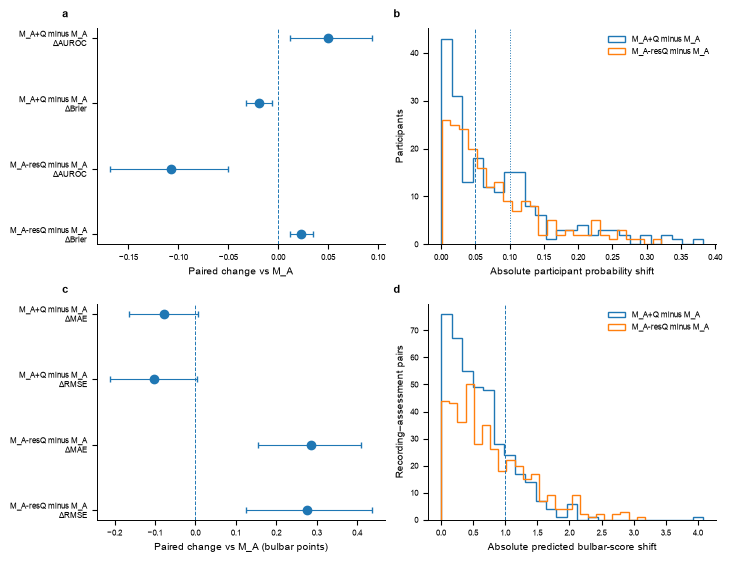

FIGURE 3: PASS


In [19]:
MM_TO_IN = 1 / 25.4
DOUBLE_COLUMN = 183 * MM_TO_IN

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

def clean_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")

def panel_label(ax, label):
    ax.text(
        -0.12,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="bottom",
    )

def save_figure(
    fig,
    stem,
    source_tables,
):
    fig.savefig(
        FIGURES / f"{stem}.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURES / f"{stem}.svg",
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURES / f"{stem}.png",
        dpi=600,
        bbox_inches="tight",
    )

    atomic_write_json(
        {
            "created_utc": datetime.now(
                timezone.utc
            ).isoformat(),
            "source_tables": source_tables,
            "run_mode": RUN_MODE,
        },
        FIGURES / f"{stem}.provenance.json",
    )

    plt.show()
    plt.close(fig)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(
        DOUBLE_COLUMN,
        140 * MM_TO_IN,
    ),
    constrained_layout=True,
)

# A: diagnosis paired changes.
ax = axes[0, 0]
diag = paired_bootstrap.loc[
    paired_bootstrap["task"].eq("diagnosis")
].copy()

labels = []
ypos = []
values = []
lower = []
upper = []

row_index = 0

for contrast in [
    "M_A+Q minus M_A",
    "M_A-resQ minus M_A",
]:
    for metric in [
        "AUROC",
        "Brier",
    ]:
        row = diag.loc[
            diag["contrast"].eq(contrast)
            & diag["metric"].eq(metric)
        ].iloc[0]

        labels.append(
            f"{contrast}\nΔ{metric}"
        )
        ypos.append(row_index)
        values.append(row["estimate"])
        lower.append(
            max(
                0.0,
                row["estimate"]
                - row["ci_low"],
            )
        )
        upper.append(
            max(
                0.0,
                row["ci_high"]
                - row["estimate"],
            )
        )
        row_index += 1

ax.errorbar(
    values,
    ypos,
    xerr=np.vstack([lower, upper]),
    fmt="o",
    capsize=2,
    linewidth=0.8,
)
ax.axvline(
    0,
    linestyle="--",
    linewidth=0.7,
)
ax.set_yticks(ypos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel(
    "Paired change vs M_A"
)
clean_axis(ax)
panel_label(ax, "a")

# B: diagnosis individual shifts.
ax = axes[0, 1]

for comparison in [
    "M_A+Q minus M_A",
    "M_A-resQ minus M_A",
]:
    values_plot = prediction_shifts.loc[
        prediction_shifts[
            "task"
        ].eq("diagnosis")
        & prediction_shifts[
            "comparison"
        ].eq(comparison),
        "absolute_shift",
    ]

    ax.hist(
        values_plot,
        bins=25,
        histtype="step",
        linewidth=1.0,
        label=comparison,
    )

ax.axvline(
    0.05,
    linestyle="--",
    linewidth=0.7,
)
ax.axvline(
    0.10,
    linestyle=":",
    linewidth=0.7,
)
ax.set_xlabel(
    "Absolute participant probability shift"
)
ax.set_ylabel(
    "Participants"
)
ax.legend(frameon=False)
clean_axis(ax)
panel_label(ax, "b")

# C: severity paired changes.
ax = axes[1, 0]
severity_boot = paired_bootstrap.loc[
    paired_bootstrap["task"].eq("severity")
].copy()

labels = []
ypos = []
values = []
lower = []
upper = []
row_index = 0

for contrast in [
    "M_A+Q minus M_A",
    "M_A-resQ minus M_A",
]:
    for metric in [
        "MAE",
        "RMSE",
    ]:
        row = severity_boot.loc[
            severity_boot[
                "contrast"
            ].eq(contrast)
            & severity_boot[
                "metric"
            ].eq(metric)
        ].iloc[0]

        labels.append(
            f"{contrast}\nΔ{metric}"
        )
        ypos.append(row_index)
        values.append(row["estimate"])
        lower.append(
            max(
                0.0,
                row["estimate"]
                - row["ci_low"],
            )
        )
        upper.append(
            max(
                0.0,
                row["ci_high"]
                - row["estimate"],
            )
        )
        row_index += 1

ax.errorbar(
    values,
    ypos,
    xerr=np.vstack([lower, upper]),
    fmt="o",
    capsize=2,
    linewidth=0.8,
)
ax.axvline(
    0,
    linestyle="--",
    linewidth=0.7,
)
ax.set_yticks(ypos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel(
    "Paired change vs M_A (bulbar points)"
)
clean_axis(ax)
panel_label(ax, "c")

# D: severity individual shifts.
ax = axes[1, 1]

for comparison in [
    "M_A+Q minus M_A",
    "M_A-resQ minus M_A",
]:
    values_plot = prediction_shifts.loc[
        prediction_shifts[
            "task"
        ].eq("severity")
        & prediction_shifts[
            "comparison"
        ].eq(comparison),
        "absolute_shift",
    ]

    ax.hist(
        values_plot,
        bins=25,
        histtype="step",
        linewidth=1.0,
        label=comparison,
    )

ax.axvline(
    1.0,
    linestyle="--",
    linewidth=0.7,
)
ax.set_xlabel(
    "Absolute predicted bulbar-score shift"
)
ax.set_ylabel(
    "Recording–assessment pairs"
)
ax.legend(frameon=False)
clean_axis(ax)
panel_label(ax, "d")

save_figure(
    fig,
    f"Figure3_Goal2_inference_change_{RUN_TAG}",
    [
        "goal2_metrics.csv",
        "goal2_prediction_shifts.csv",
    ],
)

print("FIGURE 3: PASS")


## 18. Publication Figure 4 — Is acoustic-model error quality-dependent?

The main figure uses the primary independence-working-correlation GEE and plots effects per 1 natural IQR of Q.

- A: between-participant Q effects on loss across the three models.
- B: within-participant Q effects.
- C: Q dependence of \(L_{A+Q}-L_A\).
- D: Q dependence of \(L_{A-resQ}-L_A\).


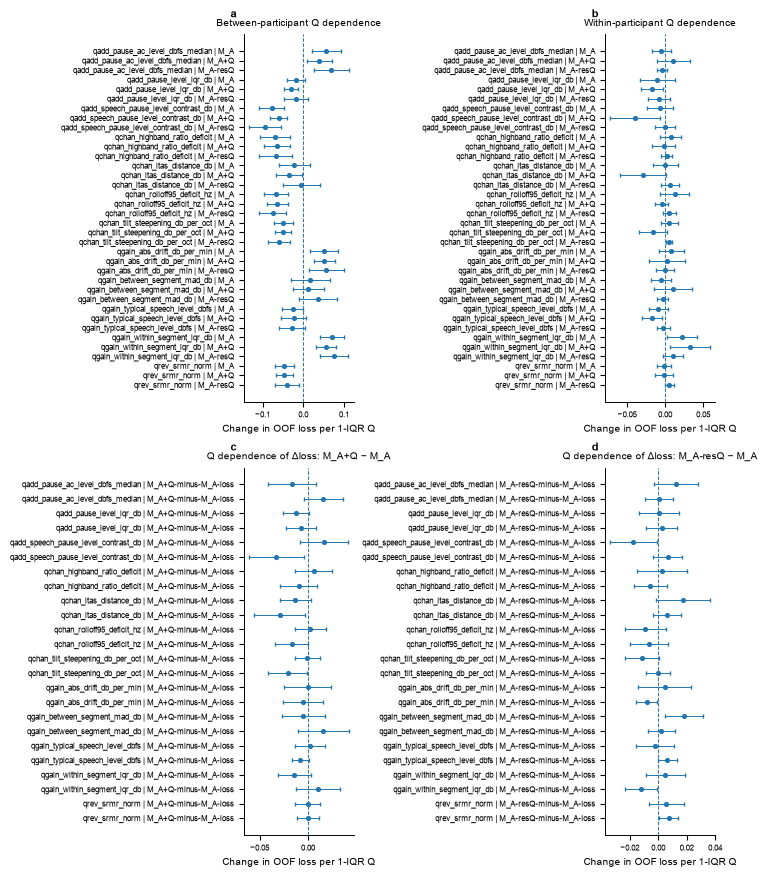

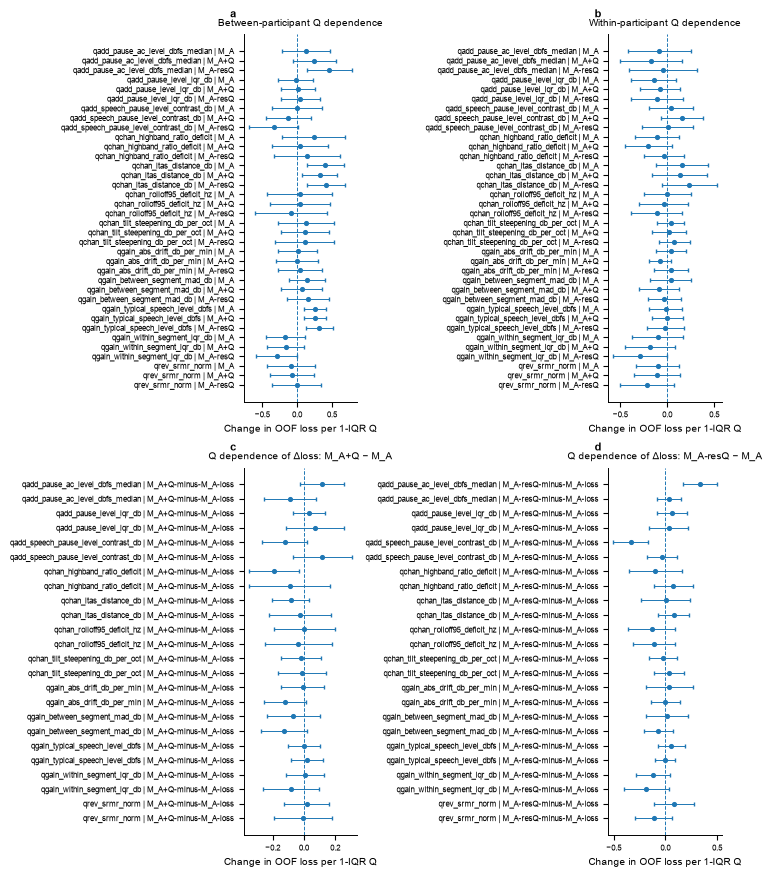

FIGURE 4: PASS


In [20]:
plot_assoc = q_error_associations.loc[
    q_error_associations[
        "cov_structure"
    ].eq("independence")
    & q_error_associations[
        "status"
    ].eq("ok")
].copy()

def forest_panel(
    ax,
    table,
    title,
):
    table = table.copy()

    if len(table) == 0:
        ax.text(
            .5,
            .5,
            "No estimable effects",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        clean_axis(ax)
        return

    table = table.sort_values(
        [
            "q_family",
            "q_feature",
            "model",
        ]
    ).reset_index(drop=True)

    y = np.arange(
        len(table)
    )

    estimate = table[
        "effect_per_1IQR_Q"
    ].to_numpy(float)

    error = np.vstack([
        estimate
        - table["ci_low"].to_numpy(float),
        table["ci_high"].to_numpy(float)
        - estimate,
    ])

    ax.errorbar(
        estimate,
        y,
        xerr=error,
        fmt="o",
        markersize=2.7,
        linewidth=0.7,
        capsize=1.5,
    )

    labels = [
        f"{q} | {model}"
        for q, model in zip(
            table["q_feature"],
            table["model"],
        )
    ]

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.axvline(
        0,
        linestyle="--",
        linewidth=0.7,
    )
    ax.set_xlabel(
        "Change in OOF loss per 1-IQR Q"
    )
    ax.set_title(title)
    clean_axis(ax)

# Use diagnosis in left half and severity in right half would make
# a very tall figure. Instead Figure 4 is generated once per task.
for task in [
    "diagnosis",
    "severity",
]:
    task_table = plot_assoc.loc[
        plot_assoc["task"].eq(task)
    ]

    main_models = task_table.loc[
        task_table["model"].isin(MODELS)
    ]

    delta_add = task_table.loc[
        task_table[
            "model"
        ].eq("M_A+Q-minus-M_A-loss")
    ]

    delta_res = task_table.loc[
        task_table[
            "model"
        ].eq("M_A-resQ-minus-M_A-loss")
    ]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(
            DOUBLE_COLUMN,
            220 * MM_TO_IN,
        ),
        constrained_layout=True,
    )

    forest_panel(
        axes[0, 0],
        main_models.loc[
            main_models[
                "component"
            ].eq("between")
        ],
        "Between-participant Q dependence",
    )
    panel_label(
        axes[0, 0],
        "a",
    )

    forest_panel(
        axes[0, 1],
        main_models.loc[
            main_models[
                "component"
            ].eq("within")
        ],
        "Within-participant Q dependence",
    )
    panel_label(
        axes[0, 1],
        "b",
    )

    forest_panel(
        axes[1, 0],
        delta_add,
        "Q dependence of Δloss: M_A+Q − M_A",
    )
    panel_label(
        axes[1, 0],
        "c",
    )

    forest_panel(
        axes[1, 1],
        delta_res,
        "Q dependence of Δloss: M_A-resQ − M_A",
    )
    panel_label(
        axes[1, 1],
        "d",
    )

    save_figure(
        fig,
        (
            f"Figure4_Goal2_Q_dependent_error_"
            f"{task}_{RUN_TAG}"
        ),
        [
            "goal2_q_error_associations.csv",
        ],
    )

print("FIGURE 4: PASS")


## 19. Save model config, run manifest, and success seal

Development results are implementation checks only.

The notebook does not claim that a Goal 2 effect is technical, spurious, or causal.


In [21]:
model_config = {
    "engine_version": ENGINE_VERSION,
    "run_mode": RUN_MODE,
    "run_signature": RUN_SIGNATURE,
    "base_seed": BASE_SEED,
    "outer_folds": OUTER_FOLDS,
    "outer_repeats": OUTER_REPEATS,
    "inner_folds": INNER_FOLDS,
    "bootstrap_replicates": N_BOOTSTRAPS,
    "run_signature": RUN_SIGNATURE,
    "diagnosis_estimator": "L2 logistic regression",
    "diagnosis_C_grid": C_GRID.tolist(),
    "severity_estimator": "L2 ridge regression",
    "severity_alpha_grid": ALPHA_GRID.tolist(),
    "residualizer": "linear multi-output Ridge Q->A",
    "residualizer_alpha": RESIDUALIZER_ALPHA,
    "residualizer_interpretation": (
        "removes linear Q-predictable component only"
    ),
    "participant_weighting": (
        "each participant total fitting weight = 1"
    ),
    "diagnosis_population": (
        "all age-complete retained diagnosis recordings"
    ),
    "severity_population": (
        "all <=60-day recording-assessment pairs"
    ),
    "primary_A": PRIMARY_A,
    "core_Q": CORE_Q,
    "QADD_support": Q_SUPPORT,
    "native_calibration_primary": True,
    "q_loss_GEE": (
        "identity-link Gaussian working family; "
        "participant cluster robust covariance"
    ),
    "q_loss_primary_cov_structure": "independence",
    "q_loss_sensitivity_cov_structure": "exchangeable",
}

atomic_write_json(
    model_config,
    OUT / "model_config.json",
)

input_hashes = {
    name: sha256_file(path)
    for name, path in PATHS.items()
    if Path(path).is_file()
}

run_manifest = {
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "engine_version": ENGINE_VERSION,
    "run_mode": RUN_MODE,
    "paper1_commit": observed_paper1_commit,
    "a_freeze_version": a_manifest[
        "a_freeze_version"
    ],
    "a_registry_sha256": sha256_file(
        PATHS["a_registry"]
    ),
    "a_values_sha256": sha256_file(
        PATHS["a_values"]
    ),
    "input_hashes": input_hashes,
    "primary_A": PRIMARY_A,
    "extended_A_n": len(EXTENDED_A),
    "core_Q": CORE_Q,
    "diagnosis_rows": len(dx),
    "diagnosis_participants": dx[
        "participant_id"
    ].nunique(),
    "severity_pairs": len(sev),
    "severity_participants": sev[
        "participant_id"
    ].nunique(),
    "package_versions": {
        p: package_version(p)
        for p in [
            "numpy",
            "pandas",
            "scipy",
            "scikit-learn",
            "statsmodels",
            "matplotlib",
        ]
    },
    "interpretation_boundary": (
        "Natural Goal 2 analyses quantify dependence/sensitivity "
        "within the observed cohort; they do not identify a "
        "physical acquisition cause."
    ),
}

atomic_write_json(
    run_manifest,
    OUT / "run_manifest.json",
)

required_outputs = [
    OOF_DIR / "goal2_diagnosis_oof.csv",
    OOF_DIR / "goal2_severity_oof.csv",
    TABLES / "goal2_dx_participant_oof.csv",
    TABLES / "goal2_fold_model_manifest.csv",
    TABLES / "goal2_metrics.csv",
    TABLES / "goal2_prediction_shifts.csv",
    TABLES / "goal2_q_error_associations.csv",
    FIGURES / (
        f"Figure3_Goal2_inference_change_"
        f"{RUN_TAG}.pdf"
    ),
    FIGURES / (
        f"Figure4_Goal2_Q_dependent_error_"
        f"diagnosis_{RUN_TAG}.pdf"
    ),
    FIGURES / (
        f"Figure4_Goal2_Q_dependent_error_"
        f"severity_{RUN_TAG}.pdf"
    ),
]

bad_outputs = [
    str(path)
    for path in required_outputs
    if (
        not path.exists()
        or path.stat().st_size == 0
    )
]

if bad_outputs:
    raise RuntimeError(
        "Goal 2 cannot be sealed; missing/empty outputs:\n"
        + "\n".join(bad_outputs)
    )

success = {
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "status": "PASS",
    "run_mode": RUN_MODE,
    "engine_version": ENGINE_VERSION,
    "a_freeze_version": a_manifest[
        "a_freeze_version"
    ],
    "primary_A_n": len(PRIMARY_A),
    "diagnosis_participants": int(
        dx["participant_id"].nunique()
    ),
    "severity_participants": int(
        sev["participant_id"].nunique()
    ),
    "severity_pairs": int(len(sev)),
    "bootstrap_replicates": N_BOOTSTRAPS,
}

atomic_write_json(
    success,
    OUT / "SUCCESS.json",
)

print(
    f"\nGOAL 2 {RUN_MODE} PRIMARY PIPELINE: PASS"
)
print("Output directory:", OUT)
print(
    "\nInterpretation reminder: "
    "do not call A+Q improvement technical correction, "
    "and do not call residualization loss proof of spuriousness."
)



GOAL 2 FINAL PRIMARY PIPELINE: PASS
Output directory: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_primary_v1_1\final

Interpretation reminder: do not call A+Q improvement technical correction, and do not call residualization loss proof of spuriousness.


In [22]:
# ============================================================
# PUBLICATION FIGURES — GOAL 2
# Sophisticated, outcome-transparent panels generated ONLY
# from saved machine-readable Goal 2 result tables.
# ============================================================

from pathlib import Path
from matplotlib.lines import Line2D
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PUB_DIR = FIGURES / "publication_ready"
PUB_DIR.mkdir(parents=True, exist_ok=True)

metrics_pub = pd.read_csv(TABLES / "goal2_metrics.csv")
shifts_pub = pd.read_csv(TABLES / "goal2_prediction_shifts.csv")
qassoc_pub = pd.read_csv(TABLES / "goal2_q_error_associations.csv")
dx_repeat_pub = pd.read_csv(TABLES / "goal2_dx_metrics_by_repeat.csv")
sev_repeat_pub = pd.read_csv(TABLES / "goal2_severity_metrics_by_repeat.csv")
cal_pub = pd.read_csv(TABLES / "goal2_diagnosis_calibration.csv")
cal_repeat_pub = pd.read_csv(
    TABLES / "goal2_diagnosis_calibration_by_repeat.csv"
)
cal_curve_pub = pd.read_csv(
    TABLES / "goal2_diagnosis_calibration_curve.csv"
)

MM_TO_IN = 1 / 25.4
DOUBLE_COLUMN = 183 * MM_TO_IN

# Deliberately restrained, colorblind-friendly scientific palette.
MODEL_COLORS = {
    "M_A": "#334155",       # slate
    "M_A+Q": "#0F766E",     # deep teal
    "M_A-resQ": "#C2415D",  # muted rose
}

MODEL_LABELS = {
    "M_A": "Age + A",
    "M_A+Q": "Age + A + Q",
    "M_A-resQ": "Age + A-resQ",
}

COMPARISON_COLORS = {
    "M_A+Q minus M_A": MODEL_COLORS["M_A+Q"],
    "M_A-resQ minus M_A": MODEL_COLORS["M_A-resQ"],
}

COMPARISON_LABELS = {
    "M_A+Q minus M_A": "A + Q vs A",
    "M_A-resQ minus M_A": "A-resQ vs A",
}

Q_FAMILY_COLORS = {
    "QADD": "#3568A8",
    "QGAIN": "#D17A22",
    "QREV": "#2D8A67",
    "QCHAN": "#7651A8",
}

Q_SHORT = {
    "qadd_pause_ac_level_dbfs_median": "Pause-region level",
    "qadd_pause_level_iqr_db": "Pause-level variability",
    "qadd_speech_pause_level_contrast_db": "Speech–pause contrast",
    "qgain_typical_speech_level_dbfs": "Typical speech level",
    "qgain_within_segment_iqr_db": "Within-segment variability",
    "qgain_between_segment_mad_db": "Between-segment variability",
    "qgain_abs_drift_db_per_min": "Absolute level drift",
    "qrev_srmr_norm": "Normalized SRMR",
    "qchan_ltas_distance_db": "LTAS distance",
    "qchan_rolloff95_deficit_hz": "Rolloff-95 deficit",
    "qchan_highband_ratio_deficit": "High-band deficit",
    "qchan_tilt_steepening_db_per_oct": "Spectral-tilt steepening",
}

Q_ORDER = [
    "qadd_pause_ac_level_dbfs_median",
    "qadd_pause_level_iqr_db",
    "qadd_speech_pause_level_contrast_db",
    "qgain_typical_speech_level_dbfs",
    "qgain_within_segment_iqr_db",
    "qgain_between_segment_mad_db",
    "qgain_abs_drift_db_per_min",
    "qrev_srmr_norm",
    "qchan_ltas_distance_db",
    "qchan_rolloff95_deficit_hz",
    "qchan_highband_ratio_deficit",
    "qchan_tilt_steepening_db_per_oct",
]

mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7.5,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

def clean_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3)

def panel_label(ax, label):
    ax.text(
        -0.12, 1.05, label,
        transform=ax.transAxes,
        fontsize=8.5,
        fontweight="bold",
        va="bottom",
        ha="left",
    )

def save_pub(fig, stem):
    fig.savefig(
        PUB_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        PUB_DIR / f"{stem}.svg",
        bbox_inches="tight",
    )
    fig.savefig(
        PUB_DIR / f"{stem}.png",
        dpi=600,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

def exceedance_curve(values):
    x = np.sort(
        np.asarray(values, dtype=float)
    )
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.array([]), np.array([])

    # Fraction of observations with value >= x.
    y = (
        len(x) - np.arange(len(x))
    ) / len(x)

    return x, y

print("Publication figure tables loaded.")
print("Output:", PUB_DIR)

Publication figure tables loaded.
Output: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_primary_v1_1\final\figures\publication_ready


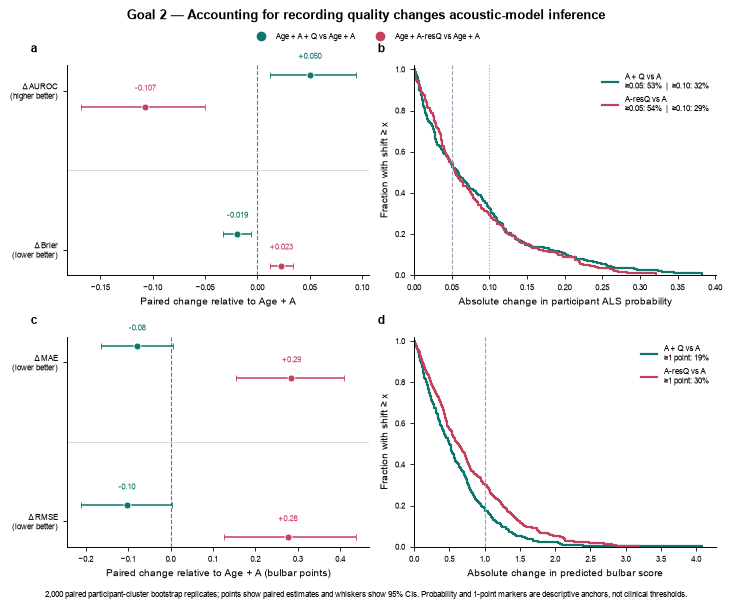

In [23]:
# ============================================================
# FIGURE 3
# DOES ACCOUNTING FOR Q CHANGE CLINICAL INFERENCE?
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(DOUBLE_COLUMN, 138 * MM_TO_IN),
    constrained_layout=True,
)

# ------------------------------------------------------------
# A. Diagnosis paired performance changes
# ------------------------------------------------------------

ax = axes[0, 0]

diag_metrics = metrics_pub.loc[
    metrics_pub["task"].eq("diagnosis")
    & metrics_pub["metric"].isin(["AUROC", "Brier"])
].copy()

y_positions = {
    ("AUROC", "M_A+Q minus M_A"): 3.15,
    ("AUROC", "M_A-resQ minus M_A"): 2.75,
    ("Brier", "M_A+Q minus M_A"): 1.15,
    ("Brier", "M_A-resQ minus M_A"): 0.75,
}

for row in diag_metrics.itertuples(index=False):
    key = (row.metric, row.contrast)

    if key not in y_positions:
        continue

    y = y_positions[key]
    color = COMPARISON_COLORS[row.contrast]

    lo = max(0, row.estimate - row.ci_low)
    hi = max(0, row.ci_high - row.estimate)

    ax.errorbar(
        row.estimate,
        y,
        xerr=np.array([[lo], [hi]]),
        fmt="o",
        markersize=5,
        linewidth=1.1,
        capsize=2.5,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.6,
        zorder=3,
    )

    ax.text(
        row.estimate,
        y + 0.18,
        f"{row.estimate:+.3f}",
        color=color,
        ha="center",
        va="bottom",
        fontsize=5.8,
    )

ax.axvline(
    0,
    color="#64748B",
    linestyle="--",
    linewidth=0.8,
)

ax.axhline(
    1.95,
    color="#CBD5E1",
    linewidth=0.6,
)

ax.set_yticks([2.95, 0.95])
ax.set_yticklabels([
    "Δ AUROC\n(higher better)",
    "Δ Brier\n(lower better)",
])

ax.set_xlabel(
    "Paired change relative to Age + A"
)

clean_axis(ax)
panel_label(ax, "a")

# ------------------------------------------------------------
# B. Diagnosis participant-level prediction movement
# ------------------------------------------------------------

ax = axes[0, 1]

diagnosis_shift = shifts_pub.loc[
    shifts_pub["task"].eq("diagnosis")
].copy()

for comparison in [
    "M_A+Q minus M_A",
    "M_A-resQ minus M_A",
]:
    values = diagnosis_shift.loc[
        diagnosis_shift["comparison"].eq(comparison),
        "absolute_shift",
    ]

    x, y = exceedance_curve(values)

    pct05 = 100 * np.mean(values >= 0.05)
    pct10 = 100 * np.mean(values >= 0.10)

    ax.step(
        x,
        y,
        where="post",
        linewidth=1.6,
        color=COMPARISON_COLORS[comparison],
        label=(
            f"{COMPARISON_LABELS[comparison]}\n"
            f"≥0.05: {pct05:.0f}%  |  ≥0.10: {pct10:.0f}%"
        ),
    )

ax.axvline(
    0.05,
    color="#94A3B8",
    linestyle="--",
    linewidth=0.8,
)

ax.axvline(
    0.10,
    color="#94A3B8",
    linestyle=":",
    linewidth=0.8,
)

ax.set_xlim(left=0)
ax.set_ylim(0, 1.02)

ax.set_xlabel(
    "Absolute change in participant ALS probability"
)
ax.set_ylabel(
    "Fraction with shift ≥ x"
)

ax.legend(
    frameon=False,
    loc="upper right",
)

clean_axis(ax)
panel_label(ax, "b")

# ------------------------------------------------------------
# C. Severity paired performance changes
# ------------------------------------------------------------

ax = axes[1, 0]

sev_metrics = metrics_pub.loc[
    metrics_pub["task"].eq("severity")
    & metrics_pub["metric"].isin(["MAE", "RMSE"])
].copy()

y_positions = {
    ("MAE", "M_A+Q minus M_A"): 3.15,
    ("MAE", "M_A-resQ minus M_A"): 2.75,
    ("RMSE", "M_A+Q minus M_A"): 1.15,
    ("RMSE", "M_A-resQ minus M_A"): 0.75,
}

for row in sev_metrics.itertuples(index=False):
    key = (row.metric, row.contrast)

    if key not in y_positions:
        continue

    y = y_positions[key]
    color = COMPARISON_COLORS[row.contrast]

    lo = max(0, row.estimate - row.ci_low)
    hi = max(0, row.ci_high - row.estimate)

    ax.errorbar(
        row.estimate,
        y,
        xerr=np.array([[lo], [hi]]),
        fmt="o",
        markersize=5,
        linewidth=1.1,
        capsize=2.5,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.6,
        zorder=3,
    )

    ax.text(
        row.estimate,
        y + 0.18,
        f"{row.estimate:+.2f}",
        color=color,
        ha="center",
        va="bottom",
        fontsize=5.8,
    )

ax.axvline(
    0,
    color="#64748B",
    linestyle="--",
    linewidth=0.8,
)

ax.axhline(
    1.95,
    color="#CBD5E1",
    linewidth=0.6,
)

ax.set_yticks([2.95, 0.95])
ax.set_yticklabels([
    "Δ MAE\n(lower better)",
    "Δ RMSE\n(lower better)",
])

ax.set_xlabel(
    "Paired change relative to Age + A (bulbar points)"
)

clean_axis(ax)
panel_label(ax, "c")

# ------------------------------------------------------------
# D. Severity individual prediction movement
# ------------------------------------------------------------

ax = axes[1, 1]

severity_shift = shifts_pub.loc[
    shifts_pub["task"].eq("severity")
].copy()

for comparison in [
    "M_A+Q minus M_A",
    "M_A-resQ minus M_A",
]:
    values = severity_shift.loc[
        severity_shift["comparison"].eq(comparison),
        "absolute_shift",
    ]

    x, y = exceedance_curve(values)

    pct1 = 100 * np.mean(values >= 1.0)

    ax.step(
        x,
        y,
        where="post",
        linewidth=1.6,
        color=COMPARISON_COLORS[comparison],
        label=(
            f"{COMPARISON_LABELS[comparison]}\n"
            f"≥1 point: {pct1:.0f}%"
        ),
    )

ax.axvline(
    1.0,
    color="#94A3B8",
    linestyle="--",
    linewidth=0.8,
)

ax.set_xlim(left=0)
ax.set_ylim(0, 1.02)

ax.set_xlabel(
    "Absolute change in predicted bulbar score"
)
ax.set_ylabel(
    "Fraction with shift ≥ x"
)

ax.legend(
    frameon=False,
    loc="upper right",
)

clean_axis(ax)
panel_label(ax, "d")

# ------------------------------------------------------------
# Shared legend / title
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color=MODEL_COLORS["M_A+Q"],
        markerfacecolor=MODEL_COLORS["M_A+Q"],
        linewidth=0,
        label="Age + A + Q vs Age + A",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color=MODEL_COLORS["M_A-resQ"],
        markerfacecolor=MODEL_COLORS["M_A-resQ"],
        linewidth=0,
        label="Age + A-resQ vs Age + A",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.025),
    ncol=2,
    frameon=False,
)

fig.suptitle(
    "Goal 2 — Accounting for recording quality changes acoustic-model inference",
    fontsize=9,
    fontweight="bold",
    y=1.055,
)

fig.text(
    0.5,
    -0.015,
    (
        f"{N_BOOTSTRAPS:,} paired participant-cluster bootstrap replicates; "
        "points show paired estimates and whiskers show 95% CIs. "
        "Probability and 1-point markers are descriptive anchors, not clinical thresholds."
    ),
    ha="center",
    va="top",
    fontsize=5.8,
)

save_pub(
    fig,
    f"Figure3_Goal2_publication_{RUN_MODE.lower()}",
)

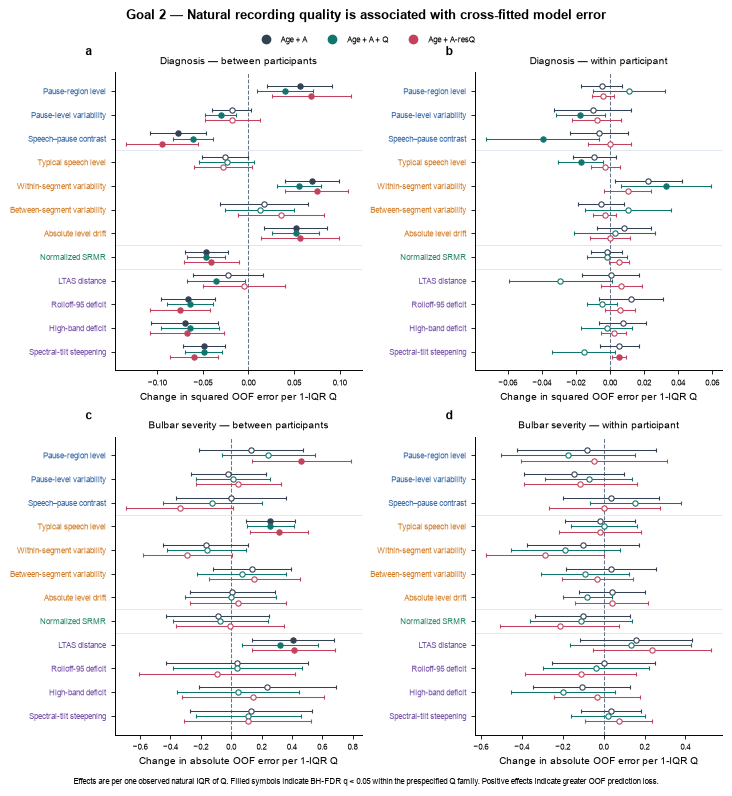

In [24]:
# ============================================================
# FIGURE 4
# IS ACOUSTIC-MODEL ERROR QUALITY-DEPENDENT?
#
# Filled markers = BH-FDR q < 0.05
# Open markers   = q >= 0.05
# ============================================================

continuous = qassoc_pub.loc[
    qassoc_pub["cov_structure"].eq("independence")
    & qassoc_pub["status"].eq("ok")
    & qassoc_pub["q_feature"].isin(Q_ORDER)
    & qassoc_pub["model"].isin(
        ["M_A", "M_A+Q", "M_A-resQ"]
    )
    & qassoc_pub["component"].isin(
        ["between", "within"]
    )
].copy()

def forest_quality_panel(
    ax,
    table,
    task,
    component,
    title,
):
    table = table.loc[
        table["task"].eq(task)
        & table["component"].eq(component)
    ].copy()

    offsets = {
        "M_A": -0.22,
        "M_A+Q": 0.00,
        "M_A-resQ": 0.22,
    }

    y_base = np.arange(len(Q_ORDER))

    for model in [
        "M_A",
        "M_A+Q",
        "M_A-resQ",
    ]:
        g = (
            table.loc[
                table["model"].eq(model)
            ]
            .set_index("q_feature")
            .reindex(Q_ORDER)
        )

        for i, feature in enumerate(Q_ORDER):
            if feature not in g.index:
                continue

            row = g.loc[feature]

            estimate = row[
                "effect_per_1IQR_Q"
            ]

            if not np.isfinite(estimate):
                continue

            lo = max(
                0,
                estimate - row["ci_low"],
            )
            hi = max(
                0,
                row["ci_high"] - estimate,
            )

            significant = (
                np.isfinite(row.get("q_value", np.nan))
                and row["q_value"] < 0.05
            )

            color = MODEL_COLORS[model]

            ax.errorbar(
                estimate,
                i + offsets[model],
                xerr=np.array([[lo], [hi]]),
                fmt="o",
                markersize=3.8,
                linewidth=0.75,
                capsize=1.5,
                color=color,
                markerfacecolor=(
                    color if significant else "white"
                ),
                markeredgecolor=color,
                markeredgewidth=0.8,
                zorder=3,
            )

    ax.axvline(
        0,
        color="#64748B",
        linestyle="--",
        linewidth=0.75,
    )

    ax.set_yticks(y_base)
    ax.set_yticklabels(
        [Q_SHORT[q] for q in Q_ORDER]
    )

    # Family coloring in the feature labels.
    family_map = {
        **{q: "QADD" for q in Q_ORDER[:3]},
        **{q: "QGAIN" for q in Q_ORDER[3:7]},
        Q_ORDER[7]: "QREV",
        **{q: "QCHAN" for q in Q_ORDER[8:]},
    }

    for tick, feature in zip(
        ax.get_yticklabels(),
        Q_ORDER,
    ):
        tick.set_color(
            Q_FAMILY_COLORS[
                family_map[feature]
            ]
        )

    # Family separators.
    for boundary in [2.5, 6.5, 7.5]:
        ax.axhline(
            boundary,
            color="#E2E8F0",
            linewidth=0.7,
            zorder=0,
        )

    ax.invert_yaxis()

    if task == "diagnosis":
        ax.set_xlabel(
            "Change in squared OOF error per 1-IQR Q"
        )
    else:
        ax.set_xlabel(
            "Change in absolute OOF error per 1-IQR Q"
        )

    ax.set_title(title)
    clean_axis(ax)

fig, axes = plt.subplots(
    2, 2,
    figsize=(DOUBLE_COLUMN, 185 * MM_TO_IN),
    constrained_layout=True,
)

forest_quality_panel(
    axes[0, 0],
    continuous,
    "diagnosis",
    "between",
    "Diagnosis — between participants",
)
panel_label(axes[0, 0], "a")

forest_quality_panel(
    axes[0, 1],
    continuous,
    "diagnosis",
    "within",
    "Diagnosis — within participant",
)
panel_label(axes[0, 1], "b")

forest_quality_panel(
    axes[1, 0],
    continuous,
    "severity",
    "between",
    "Bulbar severity — between participants",
)
panel_label(axes[1, 0], "c")

forest_quality_panel(
    axes[1, 1],
    continuous,
    "severity",
    "within",
    "Bulbar severity — within participant",
)
panel_label(axes[1, 1], "d")

model_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linewidth=0,
        color=MODEL_COLORS[model],
        markerfacecolor=MODEL_COLORS[model],
        label=MODEL_LABELS[model],
    )
    for model in [
        "M_A",
        "M_A+Q",
        "M_A-resQ",
    ]
]

fig.legend(
    handles=model_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.018),
    ncol=3,
    frameon=False,
)

fig.suptitle(
    "Goal 2 — Natural recording quality is associated with cross-fitted model error",
    fontsize=9,
    fontweight="bold",
    y=1.045,
)

fig.text(
    0.5,
    -0.01,
    (
        "Effects are per one observed natural IQR of Q. "
        "Filled symbols indicate BH-FDR q < 0.05 within the prespecified Q family. "
        "Positive effects indicate greater OOF prediction loss."
    ),
    ha="center",
    va="top",
    fontsize=5.8,
)

save_pub(
    fig,
    f"Figure4_Goal2_quality_dependence_{RUN_MODE.lower()}",
)

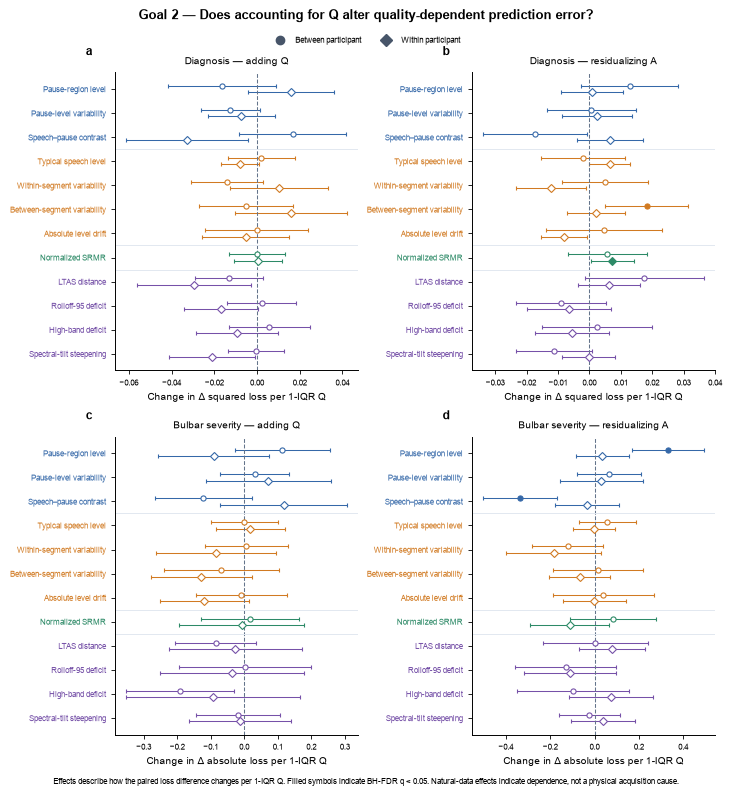

In [25]:
# ============================================================
# FIGURE 4B / COMPANION
# DOES QUALITY TREATMENT ATTENUATE OR AMPLIFY Q-DEPENDENT LOSS?
#
# Effect < 0:
#   the alternative model becomes relatively better as Q increases.
#
# Effect > 0:
#   the alternative model becomes relatively worse as Q increases.
# ============================================================

delta_assoc = qassoc_pub.loc[
    qassoc_pub["cov_structure"].eq("independence")
    & qassoc_pub["status"].eq("ok")
    & qassoc_pub["q_feature"].isin(Q_ORDER)
    & qassoc_pub["model"].isin([
        "M_A+Q-minus-M_A-loss",
        "M_A-resQ-minus-M_A-loss",
    ])
    & qassoc_pub["component"].isin([
        "between",
        "within",
    ])
].copy()

DELTA_LABELS = {
    "M_A+Q-minus-M_A-loss": "Δ loss: A + Q − A",
    "M_A-resQ-minus-M_A-loss": "Δ loss: A-resQ − A",
}

def delta_quality_panel(
    ax,
    task,
    comparison_model,
    title,
):
    g = delta_assoc.loc[
        delta_assoc["task"].eq(task)
        & delta_assoc["model"].eq(
            comparison_model
        )
    ].copy()

    y_base = np.arange(len(Q_ORDER))

    component_offset = {
        "between": -0.13,
        "within": +0.13,
    }

    component_marker = {
        "between": "o",
        "within": "D",
    }

    family_map = {
        **{q: "QADD" for q in Q_ORDER[:3]},
        **{q: "QGAIN" for q in Q_ORDER[3:7]},
        Q_ORDER[7]: "QREV",
        **{q: "QCHAN" for q in Q_ORDER[8:]},
    }

    for component in [
        "between",
        "within",
    ]:
        c = (
            g.loc[
                g["component"].eq(component)
            ]
            .set_index("q_feature")
            .reindex(Q_ORDER)
        )

        for i, feature in enumerate(Q_ORDER):
            if feature not in c.index:
                continue

            row = c.loc[feature]

            estimate = row[
                "effect_per_1IQR_Q"
            ]

            if not np.isfinite(estimate):
                continue

            lo = max(
                0,
                estimate - row["ci_low"],
            )
            hi = max(
                0,
                row["ci_high"] - estimate,
            )

            family = family_map[feature]
            color = Q_FAMILY_COLORS[family]

            significant = (
                np.isfinite(row.get("q_value", np.nan))
                and row["q_value"] < 0.05
            )

            ax.errorbar(
                estimate,
                i + component_offset[component],
                xerr=np.array([[lo], [hi]]),
                fmt=component_marker[component],
                markersize=3.7,
                linewidth=0.75,
                capsize=1.4,
                color=color,
                markerfacecolor=(
                    color if significant else "white"
                ),
                markeredgecolor=color,
                markeredgewidth=0.8,
            )

    ax.axvline(
        0,
        color="#64748B",
        linestyle="--",
        linewidth=0.75,
    )

    ax.set_yticks(y_base)
    ax.set_yticklabels(
        [Q_SHORT[q] for q in Q_ORDER]
    )

    for tick, feature in zip(
        ax.get_yticklabels(),
        Q_ORDER,
    ):
        tick.set_color(
            Q_FAMILY_COLORS[
                family_map[feature]
            ]
        )

    for boundary in [2.5, 6.5, 7.5]:
        ax.axhline(
            boundary,
            color="#E2E8F0",
            linewidth=0.7,
        )

    ax.invert_yaxis()

    ax.set_title(title)

    if task == "diagnosis":
        ax.set_xlabel(
            "Change in Δ squared loss per 1-IQR Q"
        )
    else:
        ax.set_xlabel(
            "Change in Δ absolute loss per 1-IQR Q"
        )

    clean_axis(ax)

fig, axes = plt.subplots(
    2, 2,
    figsize=(DOUBLE_COLUMN, 185 * MM_TO_IN),
    constrained_layout=True,
)

delta_quality_panel(
    axes[0, 0],
    "diagnosis",
    "M_A+Q-minus-M_A-loss",
    "Diagnosis — adding Q",
)
panel_label(axes[0, 0], "a")

delta_quality_panel(
    axes[0, 1],
    "diagnosis",
    "M_A-resQ-minus-M_A-loss",
    "Diagnosis — residualizing A",
)
panel_label(axes[0, 1], "b")

delta_quality_panel(
    axes[1, 0],
    "severity",
    "M_A+Q-minus-M_A-loss",
    "Bulbar severity — adding Q",
)
panel_label(axes[1, 0], "c")

delta_quality_panel(
    axes[1, 1],
    "severity",
    "M_A-resQ-minus-M_A-loss",
    "Bulbar severity — residualizing A",
)
panel_label(axes[1, 1], "d")

component_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linewidth=0,
        color="#475569",
        label="Between participant",
    ),
    Line2D(
        [0], [0],
        marker="D",
        linewidth=0,
        color="#475569",
        label="Within participant",
    ),
]

fig.legend(
    handles=component_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.018),
    ncol=2,
    frameon=False,
)

fig.suptitle(
    "Goal 2 — Does accounting for Q alter quality-dependent prediction error?",
    fontsize=9,
    fontweight="bold",
    y=1.045,
)

fig.text(
    0.5,
    -0.01,
    (
        "Effects describe how the paired loss difference changes per 1-IQR Q. "
        "Filled symbols indicate BH-FDR q < 0.05. "
        "Natural-data effects indicate dependence, not a physical acquisition cause."
    ),
    ha="center",
    va="top",
    fontsize=5.8,
)

save_pub(
    fig,
    f"Figure4b_Goal2_loss_change_dependence_{RUN_MODE.lower()}",
)

In [27]:
# ============================================================
# GOAL 2 — PUBLICATION FIGURE SYSTEM
# FINAL RESULTS ONLY
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import json

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Authoritative FINAL tables
# ------------------------------------------------------------

def g2_load(filename):
    path = Path(TABLES) / filename

    if not path.exists():
        raise FileNotFoundError(
            f"Missing Goal 2 source table: {path}"
        )

    if path.stat().st_size == 0:
        raise RuntimeError(
            f"Goal 2 source table is empty: {path}"
        )

    frame = pd.read_csv(
        path,
        low_memory=False,
    )

    if len(frame) == 0:
        raise RuntimeError(
            f"Goal 2 source table has no rows: {path}"
        )

    return frame


g2_metrics = g2_load(
    "goal2_metrics.csv"
)

g2_dx_repeat = g2_load(
    "goal2_dx_metrics_by_repeat.csv"
)

g2_sev_repeat = g2_load(
    "goal2_severity_metrics_by_repeat.csv"
)

g2_shifts = g2_load(
    "goal2_prediction_shifts.csv"
)

g2_qassoc = g2_load(
    "goal2_q_error_associations.csv"
)

g2_calibration = g2_load(
    "goal2_diagnosis_calibration.csv"
)

g2_calibration_curve = g2_load(
    "goal2_diagnosis_calibration_curve.csv"
)

g2_population = g2_load(
    "goal2_population_summary.csv"
)


# ------------------------------------------------------------
# FINAL gate
# ------------------------------------------------------------

if str(RUN_MODE).upper() != "FINAL":
    raise RuntimeError(
        "Publication Goal 2 figures must be generated "
        "from RUN_MODE='FINAL'."
    )


if (
    "bootstrap_replicates"
    not in g2_metrics.columns
):
    raise RuntimeError(
        "goal2_metrics.csv lacks bootstrap_replicates."
    )


bootstrap_counts = (
    g2_metrics[
        "bootstrap_replicates"
    ]
    .dropna()
    .astype(int)
    .unique()
)


if (
    len(bootstrap_counts) != 1
    or bootstrap_counts[0] != 2000
):
    raise RuntimeError(
        "Stale/non-final goal2_metrics.csv detected. "
        f"Found bootstrap counts: {bootstrap_counts}. "
        "Expected exactly 2000."
    )


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

PUB_DIR = (
    Path(FIGURES)
    / "publication_ready_final"
)

PUB_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Goal-1-matched scientific palette
# ------------------------------------------------------------

PAL = {
    "ink": "#243342",
    "ink_soft": "#5C6B78",
    "reference": "#8A98A6",
    "light": "#DCE3E8",
    "very_light": "#F2F5F7",

    # Primary models
    "M_A": "#203D5B",          # deep navy
    "M_A+Q": "#167C80",        # deep teal
    "M_A-resQ": "#A65345",     # muted terracotta

    # Q families
    "QADD": "#3D78A8",         # steel blue
    "QGAIN": "#C67645",        # burnt orange
    "QREV": "#52866B",         # sage
    "QCHAN": "#846A98",        # muted plum
}


MODEL_ORDER = [
    "M_A",
    "M_A+Q",
    "M_A-resQ",
]


MODEL_LABELS = {
    "M_A": "Age + A",
    "M_A+Q": "Age + A + Q",
    "M_A-resQ": "Age + A-resQ",
}


MODEL_COLORS = {
    model: PAL[model]
    for model in MODEL_ORDER
}


COMPARISONS = [
    "M_A+Q minus M_A",
    "M_A-resQ minus M_A",
]


COMPARISON_LABELS = {
    "M_A+Q minus M_A":
        "Add Q",

    "M_A-resQ minus M_A":
        "Residualize A",
}


COMPARISON_COLORS = {
    "M_A+Q minus M_A":
        PAL["M_A+Q"],

    "M_A-resQ minus M_A":
        PAL["M_A-resQ"],
}


# ------------------------------------------------------------
# Q display labels
# ------------------------------------------------------------

Q_ORDER = [
    "qadd_pause_ac_level_dbfs_median",
    "qadd_pause_level_iqr_db",
    "qadd_speech_pause_level_contrast_db",

    "qgain_typical_speech_level_dbfs",
    "qgain_within_segment_iqr_db",
    "qgain_between_segment_mad_db",
    "qgain_abs_drift_db_per_min",

    "qrev_srmr_norm",

    "qchan_ltas_distance_db",
    "qchan_rolloff95_deficit_hz",
    "qchan_highband_ratio_deficit",
    "qchan_tilt_steepening_db_per_oct",
]


Q_LABELS = {
    "qadd_pause_ac_level_dbfs_median":
        "Pause level",

    "qadd_pause_level_iqr_db":
        "Pause-level IQR",

    "qadd_speech_pause_level_contrast_db":
        "Speech–pause contrast",

    "qgain_typical_speech_level_dbfs":
        "Speech level",

    "qgain_within_segment_iqr_db":
        "Within-segment IQR",

    "qgain_between_segment_mad_db":
        "Between-segment MAD",

    "qgain_abs_drift_db_per_min":
        "Level drift",

    "qrev_srmr_norm":
        "Normalized SRMR",

    "qchan_ltas_distance_db":
        "LTAS distance",

    "qchan_rolloff95_deficit_hz":
        "Rolloff95 deficit",

    "qchan_highband_ratio_deficit":
        "High-band deficit",

    "qchan_tilt_steepening_db_per_oct":
        "Tilt steepening",
}


Q_FAMILY = {
    **{
        feature: "QADD"
        for feature in Q_ORDER[:3]
    },

    **{
        feature: "QGAIN"
        for feature in Q_ORDER[3:7]
    },

    Q_ORDER[7]: "QREV",

    **{
        feature: "QCHAN"
        for feature in Q_ORDER[8:]
    },
}


# ------------------------------------------------------------
# Diverging effect palette
# ------------------------------------------------------------

DIV_CMAP = (
    LinearSegmentedColormap
    .from_list(
        "goal2_effects",
        [
            "#315F78",
            "#82A8B7",
            "#F7F4EF",
            "#D79A77",
            "#9E503F",
        ],
        N=256,
    )
)


# ------------------------------------------------------------
# Typography
# ------------------------------------------------------------

MM = 1 / 25.4
DOUBLE = 183 * MM


mpl.rcParams.update({
    "font.family": [
        "Arial",
        "DejaVu Sans",
    ],

    "font.size": 6.7,
    "axes.labelsize": 6.7,
    "axes.titlesize": 7.6,

    "xtick.labelsize": 5.8,
    "ytick.labelsize": 5.8,

    "legend.fontsize": 5.8,

    "axes.linewidth": 0.65,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",

    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def clean_axis(ax):
    ax.grid(False)

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)

    ax.tick_params(
        direction="out"
    )


def panel_letter(
    ax,
    letter,
):
    ax.text(
        -0.15,
        1.04,
        letter,
        transform=ax.transAxes,
        fontsize=8.8,
        fontweight="bold",
        color=PAL["ink"],
        ha="left",
        va="bottom",
        clip_on=False,
    )


def exceedance_curve(values):

    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    values = np.sort(
        values
    )

    if len(values) == 0:
        return (
            np.array([]),
            np.array([]),
        )

    fraction = (
        len(values)
        - np.arange(
            len(values)
        )
    ) / len(values)

    return (
        values,
        fraction,
    )


def draw_contrast_forest(
    ax,
    task,
    metric,
):

    data = (
        g2_metrics.loc[
            g2_metrics[
                "task"
            ].eq(task)
            & g2_metrics[
                "metric"
            ].eq(metric)
            & g2_metrics[
                "contrast"
            ].isin(
                COMPARISONS
            )
        ]
        .set_index(
            "contrast"
        )
        .reindex(
            COMPARISONS
        )
        .reset_index()
    )

    if len(data) != 2:
        raise RuntimeError(
            f"Missing Goal 2 contrast rows for "
            f"{task}/{metric}."
        )

    for y, row in data.iterrows():

        contrast = row[
            "contrast"
        ]

        estimate = float(
            row[
                "estimate"
            ]
        )

        low = float(
            row[
                "ci_low"
            ]
        )

        high = float(
            row[
                "ci_high"
            ]
        )

        ax.errorbar(
            estimate,
            y,
            xerr=np.array([
                [
                    estimate
                    - low
                ],
                [
                    high
                    - estimate
                ],
            ]),
            fmt="o",
            markersize=5.3,
            linewidth=1.0,
            capsize=2,
            color=(
                COMPARISON_COLORS[
                    contrast
                ]
            ),
            markerfacecolor=(
                COMPARISON_COLORS[
                    contrast
                ]
            ),
            markeredgecolor="white",
            markeredgewidth=0.5,
            zorder=4,
        )

    ax.axvline(
        0,
        color=PAL[
            "reference"
        ],
        linestyle=(
            0,
            (
                3,
                2,
            ),
        ),
        linewidth=0.75,
    )

    ax.set_yticks(
        [0, 1]
    )

    ax.set_yticklabels([
        "Add Q",
        "Residualize A",
    ])

    ax.invert_yaxis()

    clean_axis(
        ax
    )


def save_goal2_figure(
    fig,
    stem,
    source_tables,
):

    for extension, kwargs in [
        (
            "pdf",
            {},
        ),
        (
            "svg",
            {},
        ),
        (
            "png",
            {
                "dpi": 600,
            },
        ),
    ]:

        fig.savefig(
            PUB_DIR
            / f"{stem}.{extension}",
            bbox_inches="tight",
            **kwargs,
        )

    provenance = {
        "created_utc":
            datetime.now(
                timezone.utc
            ).isoformat(),

        "run_mode":
            "FINAL",

        "bootstrap_replicates":
            2000,

        "source_tables":
            source_tables,
    }

    (
        PUB_DIR
        / f"{stem}.provenance.json"
    ).write_text(
        json.dumps(
            provenance,
            indent=2,
        ),
        encoding="utf-8",
    )

    plt.show()

    plt.close(
        fig
    )


print(
    "GOAL 2 FINAL PUBLICATION FIGURE GATE: PASS"
)

print(
    "Bootstrap replicates: 2000"
)

display(
    g2_population
)

GOAL 2 FINAL PUBLICATION FIGURE GATE: PASS
Bootstrap replicates: 2000


,branch,rows,participants,ALS_participants,control_participants
0,diagnosis,483,199,158,41
1,severity_60d,398,145,145,0


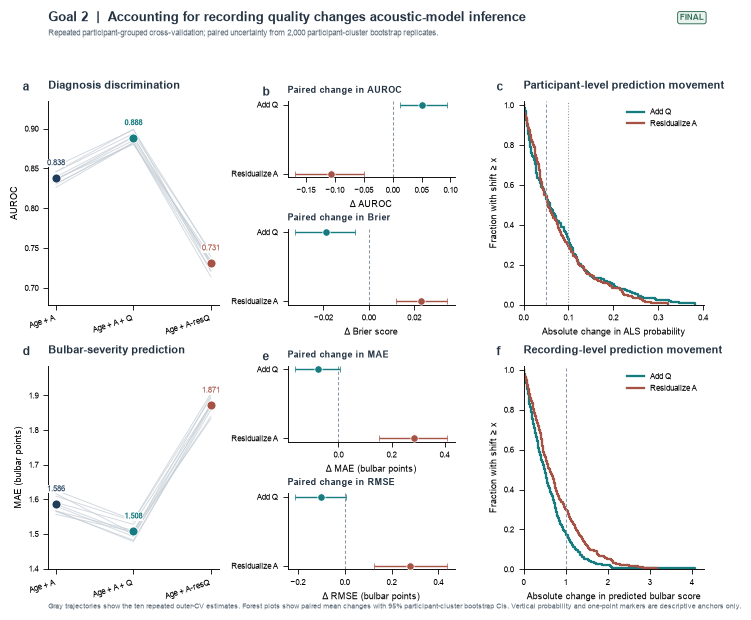

In [28]:
# ============================================================
# FIGURE 3 — GOAL 2
# DOES ACCOUNTING FOR Q CHANGE CLINICAL INFERENCE?
# ============================================================

fig = plt.figure(
    figsize=(
        DOUBLE,
        158 * MM,
    ),
    facecolor="white",
)


gs = fig.add_gridspec(
    nrows=3,
    ncols=3,

    height_ratios=[
        0.15,
        1.0,
        1.0,
    ],

    width_ratios=[
        1.02,
        1.00,
        1.08,
    ],

    left=0.075,
    right=0.985,
    bottom=0.085,
    top=0.985,

    wspace=0.40,
    hspace=0.42,
)


# ------------------------------------------------------------
# Header
# ------------------------------------------------------------

header = fig.add_subplot(
    gs[
        0,
        :,
    ]
)

header.axis(
    "off"
)


header.text(
    0.00,
    0.73,
    (
        "Goal 2  |  Accounting for recording quality "
        "changes acoustic-model inference"
    ),
    ha="left",
    va="center",
    fontsize=9.2,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
)


header.text(
    0.00,
    0.22,
    (
        "Repeated participant-grouped cross-validation; "
        "paired uncertainty from 2,000 participant-cluster bootstrap replicates."
    ),
    ha="left",
    va="center",
    fontsize=5.7,
    color=PAL[
        "ink_soft"
    ],
)


header.text(
    1.00,
    0.73,
    "FINAL",
    ha="right",
    va="center",
    fontsize=5.8,
    fontweight="bold",
    color="#36705B",
    bbox=dict(
        boxstyle=(
            "round,pad=0.28"
        ),
        facecolor="#EAF2EE",
        edgecolor="#36705B",
        linewidth=0.7,
    ),
)


# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax_a = fig.add_subplot(
    gs[
        1,
        0,
    ]
)


b_grid = (
    gs[
        1,
        1,
    ]
    .subgridspec(
        2,
        1,
        hspace=0.68,
    )
)

ax_b1 = fig.add_subplot(
    b_grid[
        0,
        0,
    ]
)

ax_b2 = fig.add_subplot(
    b_grid[
        1,
        0,
    ]
)


ax_c = fig.add_subplot(
    gs[
        1,
        2,
    ]
)


ax_d = fig.add_subplot(
    gs[
        2,
        0,
    ]
)


e_grid = (
    gs[
        2,
        1,
    ]
    .subgridspec(
        2,
        1,
        hspace=0.68,
    )
)

ax_e1 = fig.add_subplot(
    e_grid[
        0,
        0,
    ]
)

ax_e2 = fig.add_subplot(
    e_grid[
        1,
        0,
    ]
)


ax_f = fig.add_subplot(
    gs[
        2,
        2,
    ]
)


# ============================================================
# a. DIAGNOSIS AUROC ACROSS THE TEN REPEATS
# ============================================================

dx_auc = (
    g2_dx_repeat
    .pivot(
        index="repeat",
        columns="model",
        values="AUROC",
    )
    .reindex(
        columns=MODEL_ORDER
    )
)


for _, row in (
    dx_auc.iterrows()
):

    ax_a.plot(
        np.arange(3),
        row.to_numpy(
            dtype=float
        ),
        color="#C5CED5",
        linewidth=0.7,
        alpha=0.75,
        zorder=1,
    )


dx_means = (
    dx_auc.mean()
)


for x, model in enumerate(
    MODEL_ORDER
):

    ax_a.scatter(
        x,
        dx_means[
            model
        ],
        s=42,
        color=(
            MODEL_COLORS[
                model
            ]
        ),
        edgecolor="white",
        linewidth=0.6,
        zorder=4,
    )

    ax_a.annotate(
        f"{dx_means[model]:.3f}",
        xy=(
            x,
            dx_means[
                model
            ],
        ),
        xytext=(
            0,
            8,
        ),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=5.5,
        fontweight=(
            "bold"
            if model
            == "M_A+Q"
            else "normal"
        ),
        color=(
            MODEL_COLORS[
                model
            ]
        ),
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.93,
            pad=0.4,
        ),
    )


ax_a.set_xticks(
    np.arange(3)
)

ax_a.set_xticklabels(
    [
        MODEL_LABELS[
            model
        ]
        for model
        in MODEL_ORDER
    ],
    rotation=18,
    ha="right",
)


ymin = float(
    dx_auc.min().min()
) - 0.035

ymax = float(
    dx_auc.max().max()
) + 0.035


ax_a.set_ylim(
    ymin,
    ymax,
)

ax_a.set_ylabel(
    "AUROC"
)

ax_a.set_title(
    "Diagnosis discrimination",
    loc="left",
    pad=9,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
)

clean_axis(
    ax_a
)

panel_letter(
    ax_a,
    "a",
)


# ============================================================
# b. PAIRED DIAGNOSIS CHANGES
# ============================================================

draw_contrast_forest(
    ax_b1,
    task="diagnosis",
    metric="AUROC",
)

ax_b1.set_xlabel(
    "Δ AUROC"
)

ax_b1.set_title(
    "Paired change in AUROC",
    loc="left",
    pad=6,
    fontsize=6.4,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
)


draw_contrast_forest(
    ax_b2,
    task="diagnosis",
    metric="Brier",
)

ax_b2.set_xlabel(
    "Δ Brier score"
)

ax_b2.set_title(
    "Paired change in Brier",
    loc="left",
    pad=6,
    fontsize=6.4,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
)


panel_letter(
    ax_b1,
    "b",
)


# ============================================================
# c. INDIVIDUAL DIAGNOSIS PROBABILITY SHIFTS
# ============================================================

for comparison in (
    COMPARISONS
):

    values = (
        g2_shifts.loc[
            g2_shifts[
                "task"
            ].eq(
                "diagnosis"
            )
            & g2_shifts[
                "comparison"
            ].eq(
                comparison
            ),
            "absolute_shift",
        ]
    )

    x, y = (
        exceedance_curve(
            values
        )
    )

    ax_c.step(
        x,
        y,
        where="post",
        linewidth=1.65,
        color=(
            COMPARISON_COLORS[
                comparison
            ]
        ),
        label=(
            COMPARISON_LABELS[
                comparison
            ]
        ),
    )


ax_c.axvline(
    0.05,
    color=PAL[
        "reference"
    ],
    linestyle=(
        0,
        (
            3,
            2,
        ),
    ),
    linewidth=0.75,
)


ax_c.axvline(
    0.10,
    color=PAL[
        "reference"
    ],
    linestyle=":",
    linewidth=0.75,
)


ax_c.set_ylim(
    0,
    1.02,
)

ax_c.set_xlim(
    left=0,
)

ax_c.set_xlabel(
    "Absolute change in ALS probability"
)

ax_c.set_ylabel(
    "Fraction with shift ≥ x"
)

ax_c.set_title(
    "Participant-level prediction movement",
    loc="left",
    pad=9,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
)

ax_c.legend(
    frameon=False,
    loc="upper right",
)

clean_axis(
    ax_c
)

panel_letter(
    ax_c,
    "c",
)


# ============================================================
# d. SEVERITY MAE ACROSS TEN REPEATS
# ============================================================

sev_mae = (
    g2_sev_repeat
    .pivot(
        index="repeat",
        columns="model",
        values="MAE",
    )
    .reindex(
        columns=MODEL_ORDER
    )
)


for _, row in (
    sev_mae.iterrows()
):

    ax_d.plot(
        np.arange(3),
        row.to_numpy(
            dtype=float
        ),
        color="#C5CED5",
        linewidth=0.7,
        alpha=0.75,
        zorder=1,
    )


sev_means = (
    sev_mae.mean()
)


for x, model in enumerate(
    MODEL_ORDER
):

    ax_d.scatter(
        x,
        sev_means[
            model
        ],
        s=42,
        color=(
            MODEL_COLORS[
                model
            ]
        ),
        edgecolor="white",
        linewidth=0.6,
        zorder=4,
    )

    ax_d.annotate(
        f"{sev_means[model]:.3f}",
        xy=(
            x,
            sev_means[
                model
            ],
        ),
        xytext=(
            0,
            8,
        ),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=5.5,
        fontweight=(
            "bold"
            if model
            == "M_A+Q"
            else "normal"
        ),
        color=(
            MODEL_COLORS[
                model
            ]
        ),
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.93,
            pad=0.4,
        ),
    )


ax_d.set_xticks(
    np.arange(3)
)

ax_d.set_xticklabels(
    [
        MODEL_LABELS[
            model
        ]
        for model
        in MODEL_ORDER
    ],
    rotation=18,
    ha="right",
)


ymin = float(
    sev_mae.min().min()
) - 0.08

ymax = float(
    sev_mae.max().max()
) + 0.08


ax_d.set_ylim(
    ymin,
    ymax,
)

ax_d.set_ylabel(
    "MAE (bulbar points)"
)

ax_d.set_title(
    "Bulbar-severity prediction",
    loc="left",
    pad=9,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
)

clean_axis(
    ax_d
)

panel_letter(
    ax_d,
    "d",
)


# ============================================================
# e. PAIRED SEVERITY CHANGES
# ============================================================

draw_contrast_forest(
    ax_e1,
    task="severity",
    metric="MAE",
)

ax_e1.set_xlabel(
    "Δ MAE (bulbar points)"
)

ax_e1.set_title(
    "Paired change in MAE",
    loc="left",
    pad=6,
    fontsize=6.4,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
)


draw_contrast_forest(
    ax_e2,
    task="severity",
    metric="RMSE",
)

ax_e2.set_xlabel(
    "Δ RMSE (bulbar points)"
)

ax_e2.set_title(
    "Paired change in RMSE",
    loc="left",
    pad=6,
    fontsize=6.4,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
)


panel_letter(
    ax_e1,
    "e",
)


# ============================================================
# f. INDIVIDUAL SEVERITY PREDICTION SHIFTS
# ============================================================

for comparison in (
    COMPARISONS
):

    values = (
        g2_shifts.loc[
            g2_shifts[
                "task"
            ].eq(
                "severity"
            )
            & g2_shifts[
                "comparison"
            ].eq(
                comparison
            ),
            "absolute_shift",
        ]
    )

    x, y = (
        exceedance_curve(
            values
        )
    )

    ax_f.step(
        x,
        y,
        where="post",
        linewidth=1.65,
        color=(
            COMPARISON_COLORS[
                comparison
            ]
        ),
        label=(
            COMPARISON_LABELS[
                comparison
            ]
        ),
    )


ax_f.axvline(
    1.0,
    color=PAL[
        "reference"
    ],
    linestyle=(
        0,
        (
            3,
            2,
        ),
    ),
    linewidth=0.75,
)


ax_f.set_ylim(
    0,
    1.02,
)

ax_f.set_xlim(
    left=0,
)

ax_f.set_xlabel(
    "Absolute change in predicted bulbar score"
)

ax_f.set_ylabel(
    "Fraction with shift ≥ x"
)

ax_f.set_title(
    "Recording-level prediction movement",
    loc="left",
    pad=9,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
)

ax_f.legend(
    frameon=False,
    loc="upper right",
)

clean_axis(
    ax_f
)

panel_letter(
    ax_f,
    "f",
)


# ------------------------------------------------------------
# Footer
# ------------------------------------------------------------

fig.text(
    0.075,
    0.025,
    (
        "Gray trajectories show the ten repeated outer-CV estimates. "
        "Forest plots show paired mean changes with 95% participant-cluster bootstrap CIs. "
        "Vertical probability and one-point markers are descriptive anchors only."
    ),
    ha="left",
    va="center",
    fontsize=5.2,
    color=PAL[
        "ink_soft"
    ],
)


save_goal2_figure(
    fig,
    "Figure3_Goal2_primary_inference_FINAL",
    [
        "goal2_metrics.csv",
        "goal2_dx_metrics_by_repeat.csv",
        "goal2_severity_metrics_by_repeat.csv",
        "goal2_prediction_shifts.csv",
    ],
)

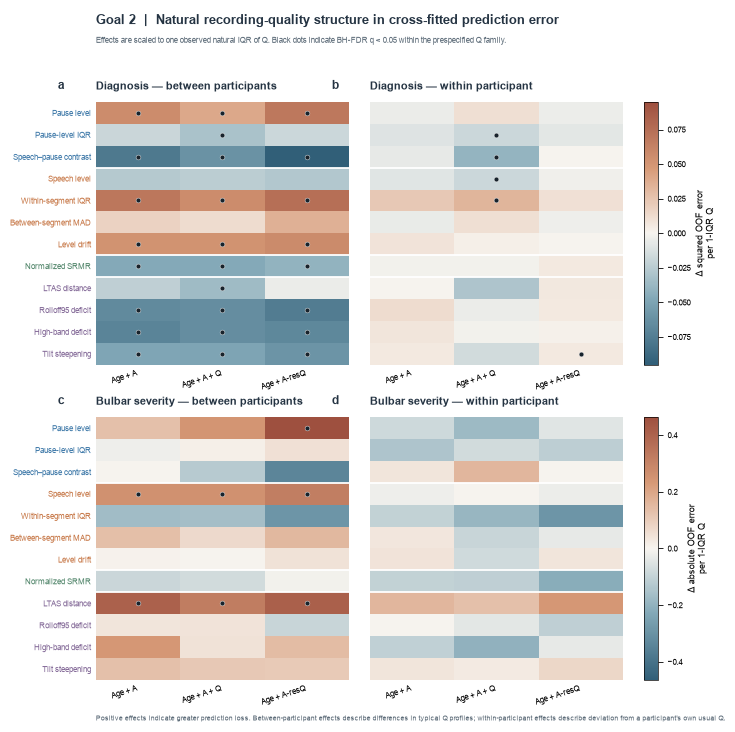

In [30]:
# ============================================================
# FIGURE 4 — GOAL 2
# NATURAL Q-DEPENDENCE OF CROSS-FITTED MODEL ERROR
# ============================================================

primary_assoc = (
    g2_qassoc.loc[
        g2_qassoc[
            "cov_structure"
        ].eq(
            "independence"
        )
        & g2_qassoc[
            "status"
        ].eq(
            "ok"
        )
        & g2_qassoc[
            "model"
        ].isin(
            MODEL_ORDER
        )
        & g2_qassoc[
            "component"
        ].isin([
            "between",
            "within",
        ])
        & g2_qassoc[
            "q_feature"
        ].isin(
            Q_ORDER
        )
    ]
    .copy()
)


def qa_error_matrix(
    task,
    component,
):

    data = (
        primary_assoc.loc[
            primary_assoc[
                "task"
            ].eq(task)
            & primary_assoc[
                "component"
            ].eq(component)
        ]
    )

    effect = (
        data
        .pivot(
            index="q_feature",
            columns="model",
            values=(
                "effect_per_1IQR_Q"
            ),
        )
        .reindex(
            index=Q_ORDER,
            columns=MODEL_ORDER,
        )
    )

    qval = (
        data
        .pivot(
            index="q_feature",
            columns="model",
            values="q_value",
        )
        .reindex(
            index=Q_ORDER,
            columns=MODEL_ORDER,
        )
    )

    return (
        effect,
        qval,
    )


dx_between, dx_between_q = (
    qa_error_matrix(
        "diagnosis",
        "between",
    )
)

dx_within, dx_within_q = (
    qa_error_matrix(
        "diagnosis",
        "within",
    )
)

sev_between, sev_between_q = (
    qa_error_matrix(
        "severity",
        "between",
    )
)

sev_within, sev_within_q = (
    qa_error_matrix(
        "severity",
        "within",
    )
)


dx_vmax = float(
    np.nanmax(
        np.abs(
            np.r_[
                dx_between.to_numpy().ravel(),
                dx_within.to_numpy().ravel(),
            ]
        )
    )
)


sev_vmax = float(
    np.nanmax(
        np.abs(
            np.r_[
                sev_between.to_numpy().ravel(),
                sev_within.to_numpy().ravel(),
            ]
        )
    )
)


fig = plt.figure(
    figsize=(
        DOUBLE,
        188 * MM,
    ),
    facecolor="white",
)


gs = fig.add_gridspec(
    nrows=3,
    ncols=3,

    height_ratios=[
        0.15,
        1.0,
        1.0,
    ],

    width_ratios=[
        1.0,
        1.0,
        0.055,
    ],

    left=0.17,
    right=0.95,
    bottom=0.08,
    top=0.985,

    wspace=0.12,
    hspace=0.28,
)


header = fig.add_subplot(
    gs[
        0,
        :,
    ]
)

header.axis(
    "off"
)


header.text(
    0.00,
    0.73,
    (
        "Goal 2  |  Natural recording-quality structure "
        "in cross-fitted prediction error"
    ),
    fontsize=9.2,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
    ha="left",
    va="center",
)


header.text(
    0.00,
    0.22,
    (
        "Effects are scaled to one observed natural IQR of Q. "
        "Black dots indicate BH-FDR q < 0.05 within the prespecified Q family."
    ),
    fontsize=5.7,
    color=PAL[
        "ink_soft"
    ],
    ha="left",
    va="center",
)


ax_a = fig.add_subplot(
    gs[
        1,
        0,
    ]
)

ax_b = fig.add_subplot(
    gs[
        1,
        1,
    ]
)

cbar_dx = fig.add_subplot(
    gs[
        1,
        2,
    ]
)


ax_c = fig.add_subplot(
    gs[
        2,
        0,
    ]
)

ax_d = fig.add_subplot(
    gs[
        2,
        1,
    ]
)

cbar_sev = fig.add_subplot(
    gs[
        2,
        2,
    ]
)


def draw_error_heatmap(
    ax,
    effect,
    qvalue,
    vmax,
    title,
    letter,
    show_y,
):

    matrix = (
        effect
        .to_numpy(
            dtype=float
        )
    )

    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap=DIV_CMAP,
        vmin=-vmax,
        vmax=vmax,
    )


    sig = (
        qvalue
        .to_numpy(
            dtype=float
        )
        < 0.05
    )

    yy, xx = np.where(
        sig
    )

    ax.scatter(
        xx,
        yy,
        s=12,
        facecolor="#18232C",
        edgecolor="white",
        linewidth=0.3,
        zorder=4,
    )


    ax.set_xticks(
        np.arange(
            len(
                MODEL_ORDER
            )
        )
    )

    ax.set_xticklabels(
        [
            MODEL_LABELS[
                model
            ]
            for model
            in MODEL_ORDER
        ],
        rotation=18,
        ha="right",
    )


    ax.set_yticks(
        np.arange(
            len(
                Q_ORDER
            )
        )
    )


    if show_y:

        ax.set_yticklabels(
            [
                Q_LABELS[
                    feature
                ]
                for feature
                in Q_ORDER
            ]
        )

        for tick, feature in zip(
            ax.get_yticklabels(),
            Q_ORDER,
        ):

            tick.set_color(
                PAL[
                    Q_FAMILY[
                        feature
                    ]
                ]
            )

    else:

        ax.set_yticklabels(
            []
        )


    for boundary in [
        2.5,
        6.5,
        7.5,
    ]:

        ax.axhline(
            boundary,
            color="white",
            linewidth=1.3,
        )


    ax.set_title(
        title,
        loc="left",
        pad=9,
        fontweight="bold",
        color=PAL[
            "ink"
        ],
    )


    for spine in (
        ax.spines.values()
    ):

        spine.set_visible(
            False
        )


    ax.tick_params(
        length=0
    )


    panel_letter(
        ax,
        letter,
    )


    return im


im_dx = draw_error_heatmap(
    ax_a,
    dx_between,
    dx_between_q,
    dx_vmax,
    "Diagnosis — between participants",
    "a",
    True,
)


draw_error_heatmap(
    ax_b,
    dx_within,
    dx_within_q,
    dx_vmax,
    "Diagnosis — within participant",
    "b",
    False,
)


cb = fig.colorbar(
    im_dx,
    cax=cbar_dx,
    orientation="vertical",
)

cb.set_label(
    (
        "Δ squared OOF error\n"
        "per 1-IQR Q"
    ),
    labelpad=3,
)

cb.outline.set_linewidth(
    0.5
)


im_sev = draw_error_heatmap(
    ax_c,
    sev_between,
    sev_between_q,
    sev_vmax,
    "Bulbar severity — between participants",
    "c",
    True,
)


draw_error_heatmap(
    ax_d,
    sev_within,
    sev_within_q,
    sev_vmax,
    "Bulbar severity — within participant",
    "d",
    False,
)


cb = fig.colorbar(
    im_sev,
    cax=cbar_sev,
    orientation="vertical",
)

cb.set_label(
    (
        "Δ absolute OOF error\n"
        "per 1-IQR Q"
    ),
    labelpad=3,
)

cb.outline.set_linewidth(
    0.5
)


fig.text(
    0.17,
    0.025,
    (
        "Positive effects indicate greater prediction loss. "
        "Between-participant effects describe differences in typical Q profiles; "
        "within-participant effects describe deviation from a participant's own usual Q."
    ),
    fontsize=5.2,
    color=PAL[
        "ink_soft"
    ],
    ha="left",
)


save_goal2_figure(
    fig,
    "Figure4_Goal2_Q_dependent_error_FINAL",
    [
        "goal2_q_error_associations.csv",
    ],
)

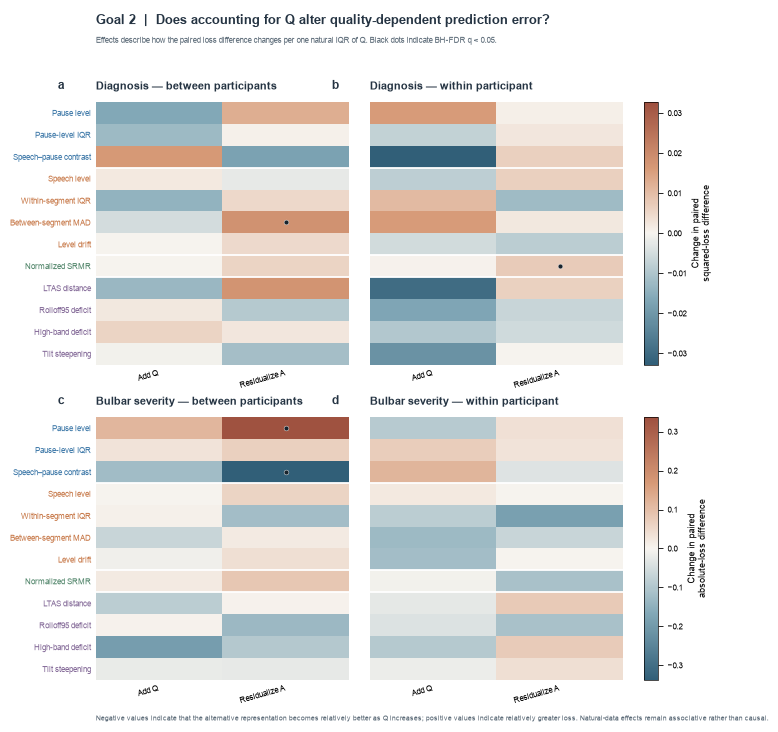

In [31]:
# ============================================================
# FIGURE 4b — GOAL 2
# DOES HANDLING Q CHANGE Q-DEPENDENT MODEL LOSS?
# ============================================================

LOSS_MODELS = [
    "M_A+Q-minus-M_A-loss",
    "M_A-resQ-minus-M_A-loss",
]


LOSS_LABELS = {
    "M_A+Q-minus-M_A-loss":
        "Add Q",

    "M_A-resQ-minus-M_A-loss":
        "Residualize A",
}


loss_assoc = (
    g2_qassoc.loc[
        g2_qassoc[
            "cov_structure"
        ].eq(
            "independence"
        )
        & g2_qassoc[
            "status"
        ].eq(
            "ok"
        )
        & g2_qassoc[
            "model"
        ].isin(
            LOSS_MODELS
        )
        & g2_qassoc[
            "component"
        ].isin([
            "between",
            "within",
        ])
        & g2_qassoc[
            "q_feature"
        ].isin(
            Q_ORDER
        )
    ]
    .copy()
)


def delta_loss_matrix(
    task,
    component,
):

    data = (
        loss_assoc.loc[
            loss_assoc[
                "task"
            ].eq(task)
            & loss_assoc[
                "component"
            ].eq(component)
        ]
    )

    effect = (
        data
        .pivot(
            index="q_feature",
            columns="model",
            values=(
                "effect_per_1IQR_Q"
            ),
        )
        .reindex(
            index=Q_ORDER,
            columns=LOSS_MODELS,
        )
    )

    qval = (
        data
        .pivot(
            index="q_feature",
            columns="model",
            values="q_value",
        )
        .reindex(
            index=Q_ORDER,
            columns=LOSS_MODELS,
        )
    )

    return (
        effect,
        qval,
    )


dx_b, dx_b_q = (
    delta_loss_matrix(
        "diagnosis",
        "between",
    )
)

dx_w, dx_w_q = (
    delta_loss_matrix(
        "diagnosis",
        "within",
    )
)

sev_b, sev_b_q = (
    delta_loss_matrix(
        "severity",
        "between",
    )
)

sev_w, sev_w_q = (
    delta_loss_matrix(
        "severity",
        "within",
    )
)


dx_vmax = float(
    np.nanmax(
        np.abs(
            np.r_[
                dx_b.to_numpy().ravel(),
                dx_w.to_numpy().ravel(),
            ]
        )
    )
)


sev_vmax = float(
    np.nanmax(
        np.abs(
            np.r_[
                sev_b.to_numpy().ravel(),
                sev_w.to_numpy().ravel(),
            ]
        )
    )
)


fig = plt.figure(
    figsize=(
        DOUBLE,
        188 * MM,
    ),
    facecolor="white",
)


gs = fig.add_gridspec(
    3,
    3,

    height_ratios=[
        0.15,
        1,
        1,
    ],

    width_ratios=[
        1,
        1,
        0.055,
    ],

    left=0.17,
    right=0.95,
    bottom=0.08,
    top=0.985,

    wspace=0.12,
    hspace=0.28,
)


header = fig.add_subplot(
    gs[
        0,
        :,
    ]
)

header.axis(
    "off"
)


header.text(
    0,
    0.73,
    (
        "Goal 2  |  Does accounting for Q alter "
        "quality-dependent prediction error?"
    ),
    fontsize=9.2,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
    ha="left",
    va="center",
)


header.text(
    0,
    0.22,
    (
        "Effects describe how the paired loss difference changes per one natural IQR of Q. "
        "Black dots indicate BH-FDR q < 0.05."
    ),
    fontsize=5.7,
    color=PAL[
        "ink_soft"
    ],
    ha="left",
    va="center",
)


axes = [
    fig.add_subplot(
        gs[
            1,
            0,
        ]
    ),

    fig.add_subplot(
        gs[
            1,
            1,
        ]
    ),

    fig.add_subplot(
        gs[
            2,
            0,
        ]
    ),

    fig.add_subplot(
        gs[
            2,
            1,
        ]
    ),
]


cbar_dx = fig.add_subplot(
    gs[
        1,
        2,
    ]
)

cbar_sev = fig.add_subplot(
    gs[
        2,
        2,
    ]
)


def draw_delta_loss_heatmap(
    ax,
    effect,
    qvalue,
    vmax,
    title,
    letter,
    show_y,
):

    matrix = (
        effect.to_numpy(
            dtype=float
        )
    )


    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="none",
        cmap=DIV_CMAP,
        vmin=-vmax,
        vmax=vmax,
    )


    sig = (
        qvalue.to_numpy(
            dtype=float
        )
        < 0.05
    )


    yy, xx = np.where(
        sig
    )


    ax.scatter(
        xx,
        yy,
        s=12,
        facecolor="#18232C",
        edgecolor="white",
        linewidth=0.3,
        zorder=4,
    )


    ax.set_xticks(
        [0, 1]
    )

    ax.set_xticklabels(
        [
            LOSS_LABELS[
                model
            ]
            for model
            in LOSS_MODELS
        ],
        rotation=16,
        ha="right",
    )


    ax.set_yticks(
        np.arange(
            len(
                Q_ORDER
            )
        )
    )


    if show_y:

        ax.set_yticklabels(
            [
                Q_LABELS[
                    feature
                ]
                for feature
                in Q_ORDER
            ]
        )

        for tick, feature in zip(
            ax.get_yticklabels(),
            Q_ORDER,
        ):

            tick.set_color(
                PAL[
                    Q_FAMILY[
                        feature
                    ]
                ]
            )

    else:

        ax.set_yticklabels(
            []
        )


    for boundary in [
        2.5,
        6.5,
        7.5,
    ]:

        ax.axhline(
            boundary,
            color="white",
            linewidth=1.3,
        )


    ax.set_title(
        title,
        loc="left",
        pad=9,
        fontweight="bold",
        color=PAL[
            "ink"
        ],
    )


    for spine in (
        ax.spines.values()
    ):

        spine.set_visible(
            False
        )


    ax.tick_params(
        length=0
    )


    panel_letter(
        ax,
        letter,
    )


    return im


im_dx = draw_delta_loss_heatmap(
    axes[0],
    dx_b,
    dx_b_q,
    dx_vmax,
    "Diagnosis — between participants",
    "a",
    True,
)


draw_delta_loss_heatmap(
    axes[1],
    dx_w,
    dx_w_q,
    dx_vmax,
    "Diagnosis — within participant",
    "b",
    False,
)


im_sev = draw_delta_loss_heatmap(
    axes[2],
    sev_b,
    sev_b_q,
    sev_vmax,
    "Bulbar severity — between participants",
    "c",
    True,
)


draw_delta_loss_heatmap(
    axes[3],
    sev_w,
    sev_w_q,
    sev_vmax,
    "Bulbar severity — within participant",
    "d",
    False,
)


cb = fig.colorbar(
    im_dx,
    cax=cbar_dx,
    orientation="vertical",
)

cb.set_label(
    (
        "Change in paired\n"
        "squared-loss difference"
    ),
    labelpad=3,
)

cb.outline.set_linewidth(
    0.5
)


cb = fig.colorbar(
    im_sev,
    cax=cbar_sev,
    orientation="vertical",
)

cb.set_label(
    (
        "Change in paired\n"
        "absolute-loss difference"
    ),
    labelpad=3,
)

cb.outline.set_linewidth(
    0.5
)


fig.text(
    0.17,
    0.025,
    (
        "Negative values indicate that the alternative representation becomes relatively "
        "better as Q increases; positive values indicate relatively greater loss. "
        "Natural-data effects remain associative rather than causal."
    ),
    fontsize=5.2,
    color=PAL[
        "ink_soft"
    ],
    ha="left",
)


save_goal2_figure(
    fig,
    "Figure4b_Goal2_change_in_Q_dependent_loss_FINAL",
    [
        "goal2_q_error_associations.csv",
    ],
)